# Longitudinal JSD + Permutation Entropy — Drivers A–F across Stints 1–5 (v6)

This notebook updates **`entropy_JSD_PE_Pipeline_v5 (GPT draft)`** for Sections
**6.2–6.4** of the manuscript. The data-reading pipeline is preserved:

`resolve_stint_files → load_stint → basic_clean_and_units → build_lap_validity_table → assign_sectors`

### Study design (v6)

| Role | Driver | Alias | Group |
|---|---|---|---|
| Expert reference | Rodrigo | Driver A | Reference (single stint) |
| Intermediate | Tomaz | Driver B | Longitudinal, Stints 1–5 |
| Coached beginners | Morsinaldo, Thallys, Hilton | Drivers C, D, F | **Coached** (LLM feedback) |
| Control beginner | Igor | Driver E | **Control** (no LLM feedback) |

### Primary comparisons

1. **Driver B vs Driver A** on both tracks. Driver A recorded a **single expert
   session (Stint 1 = `stint_ref`)**, so every Stint 1–5 of Driver B is compared
   against that **fixed reference stint**. This replaces the previous
   matched-by-stint merge, which silently produced empty cells for Stints 2–5.
2. **Coached beginners (C, D, F) vs Driver B**, matched by track and stint.
3. **Driver E (control) vs Driver B**, matched by track and stint, reported
   **separately** from the coached-group median — never pooled into it.

### Information-theoretic core

- **Jensen–Shannon divergence (JSD)** between the reference and test
  distributions of each control channel, per sector × stint, with a **fixed
  global binning of $n = 20$ bins** ($H_{max} = \log_2 20 \approx 4.32$ bits) so
  values are directly comparable across drivers, sectors, and tracks.
  Freedman–Diaconis is used only as a *post-hoc* sensitivity check, never as a
  substitute for the fixed binning. JSD is symmetric and bounded (Lin, 1991);
  $\sqrt{JSD}$ is a true metric satisfying the triangle inequality
  (Endres & Schindelin, 2003).
- **Permutation Entropy** (Bandt & Pompe, 2002) with $m = 3$, $\tau = 1$,
  normalized, per lap × sector.

### Sign convention

$$\Delta PE = PE_{\mathrm{test}} - PE_{\mathrm{reference}}$$

Positive values indicate greater **ordinal complexity** in the test driver. They
must not be interpreted automatically as worse driving; their meaning depends on
channel, sector, and their association with time loss.


## What v6 adds on top of the v5 draft

- **JSD layer restored** (it was missing from the v5 draft): fixed-bin
  ($n = 20$) sector-level JSD between every test driver and its
  proficiency-matched reference, across Stints 1–5 and both tracks, with
  sector × stint JSD maps and longitudinal JSD trajectories.
- **Fixed expert reference:** Driver B's five stints are all compared with
  Driver A's single reference stint (Stint 1), on both tracks. The v5 draft
  matched by stint number and therefore only populated Stint 1.
- **Control group:** Driver E is treated as the control beginner. The
  beginner-group median and IQR are computed from the **coached** drivers
  C, D, F only; Driver E appears as a separate, visually distinct control
  trajectory in every figure and table.
- **Statistical validation:** Wilcoxon signed-rank tests (paired by sector,
  $H_0$: median $= 0$) for $\Delta PE$ at each stint, plus paired
  first-vs-last-stint Wilcoxon tests for $|\Delta PE|$ and JSD (convergence),
  with matched-pairs rank-biserial effect sizes and Benjamini–Hochberg FDR
  correction.

The figures keep the Gestalt principles of the v5 draft: consistent encoding by
proficiency group (**similarity**), aligned small multiples (**proximity**),
connected stint trajectories (**continuity/common fate**), shared scales
(**good comparison**), and restrained color so the reference contrast remains
the visual foreground (**figure–ground**). The control driver uses a dashed
line and a reserved hue so treatment and control are separable at a glance.


In [43]:

# 0. Imports and project configuration
import os
import re
import sys
import math
import warnings
from pathlib import Path
from typing import Dict, Iterable, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import jensenshannon
from scipy.stats import pearsonr, spearmanr, wilcoxon, rankdata
from statsmodels.stats.multitest import multipletests

try:
    import antropy as ant
except ImportError as exc:
    raise ImportError(
        "This notebook requires antropy. Install it with: pip install antropy"
    ) from exc


def find_project_root(start: Optional[Path] = None) -> Path:
    """Locate the closest folder containing config.py."""
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "config.py").exists():
            return candidate
        if (candidate / "Iracing" / "config.py").exists():
            return candidate / "Iracing"
    # Preserve the original notebook convention as the final fallback.
    return Path("..").resolve()


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
except Exception:
    pass

from config import (
    TRACK_CONFIGS,
    DATASETS,
    DRIVER_ALIAS,
    resolve_stint_files,
    load_stint,
    basic_clean_and_units,
    build_lap_validity_table,
    assign_sectors,
)

load_from_ibt = load_stint

print(f"Project root : {PROJECT_ROOT}")
print(f"Tracks       : {list(TRACK_CONFIGS.keys())}")
print(f"Aliases      : {DRIVER_ALIAS}")
print(f"antropy      : {getattr(ant, '__version__', 'available')}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root : C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing
Tracks       : ['charlotte_roval_2025', 'summit_point']
Aliases      : {'Rodrigo': 'Driver A', 'Tomaz': 'Driver B', 'Morsinaldo': 'Driver C', 'Thallys': 'Driver D', 'Igor': 'Driver E', 'Hilton': 'Driver F'}
antropy      : 0.2.2


In [44]:

# 1. Study design and reproducible analysis parameters

DRIVER_TIER = {
    "Rodrigo":    {"alias": DRIVER_ALIAS.get("Rodrigo", "Driver A"), "tier": "Expert",
                   "group": "Expert"},
    "Tomaz":      {"alias": DRIVER_ALIAS.get("Tomaz", "Driver B"), "tier": "Intermediate",
                   "group": "Intermediate"},
    "Morsinaldo": {"alias": DRIVER_ALIAS.get("Morsinaldo", "Driver C"), "tier": "Beginner",
                   "group": "Coached"},
    "Thallys":    {"alias": DRIVER_ALIAS.get("Thallys", "Driver D"), "tier": "Beginner",
                   "group": "Coached"},
    "Igor":       {"alias": DRIVER_ALIAS.get("Igor", "Driver E"), "tier": "Beginner",
                   "group": "Control"},
    "Hilton":     {"alias": DRIVER_ALIAS.get("Hilton", "Driver F"), "tier": "Beginner",
                   "group": "Coached"},
}

DRIVER_ORDER = ["Rodrigo", "Tomaz", "Morsinaldo", "Thallys", "Igor", "Hilton"]
BEGINNER_DRIVERS = ["Morsinaldo", "Thallys", "Igor", "Hilton"]

# Experimental design: C, D, F received LLM coaching feedback; E is the
# no-feedback control. Group medians/IQRs are computed from COACHED drivers
# only, and Driver E is always reported as a separate control trajectory.
COACHED_BEGINNERS = ["Morsinaldo", "Thallys", "Hilton"]
CONTROL_DRIVERS = ["Igor"]
COACHED_ALIASES = [DRIVER_TIER[d]["alias"] for d in COACHED_BEGINNERS]
CONTROL_ALIAS = DRIVER_TIER["Igor"]["alias"]

STINT_NUMBERS = [1, 2, 3, 4, 5]

# ref_stint: None  -> reference matched by stint number (beginners vs B)
# ref_stint: int   -> FIXED reference stint (Driver A recorded one expert
#                     session only, so all of Driver B's stints are compared
#                     against Driver A's Stint 1 on both tracks).
COMPARISONS = [
    {"id": "B_vs_A", "ref": "Rodrigo", "test": "Tomaz",
     "group": "Intermediate vs Expert", "ref_stint": 1},
    {"id": "C_vs_B", "ref": "Tomaz", "test": "Morsinaldo",
     "group": "Coached beginner vs Intermediate", "ref_stint": None},
    {"id": "D_vs_B", "ref": "Tomaz", "test": "Thallys",
     "group": "Coached beginner vs Intermediate", "ref_stint": None},
    {"id": "E_vs_B", "ref": "Tomaz", "test": "Igor",
     "group": "Control beginner vs Intermediate", "ref_stint": None},
    {"id": "F_vs_B", "ref": "Tomaz", "test": "Hilton",
     "group": "Coached beginner vs Intermediate", "ref_stint": None},
]

COACHED_COMPARISONS = ["C_vs_B", "D_vs_B", "F_vs_B"]
CONTROL_COMPARISONS = ["E_vs_B"]

REQUESTED_TRACKS = ["charlotte_roval_2025", "summit_point"]
BATCH_TRACKS = [
    track_id for track_id in REQUESTED_TRACKS
    if track_id in TRACK_CONFIGS and track_id in DATASETS
]

VARIABLES_PE = [
    ("Brake_Pct", "Brake (%)"),
    ("TotalAccel_G", "Combined G-Force"),
    ("SteeringWheelAngle", "Steering Angle (deg)"),
    ("Throttle_Pct", "Throttle (%)"),
]
VAR_LABELS = [label for _, label in VARIABLES_PE]

PE_ORDER = 3
PE_DELAY = 1
PE_MIN_PATTERNS = 30

# JSD: fixed global binning (Reviewer 1, point 3). H_max = log2(20) = 4.32 bits.
# Freedman-Diaconis is available only as a post-hoc sensitivity check.
N_BINS_FIXED = 20
MIN_JSD_SAMPLES = 100
MIN_VALID_LAPS_STINT = 2
TIME_PROFILE_MODE = "best"  # "best" preserves the manuscript's performance-gap protocol.
FDR_ALPHA = 0.05
RANDOM_SEED = 2026

# Use this only when the keys in DATASETS cannot be parsed automatically.
# Example: {("charlotte_roval_2025", "Rodrigo", 1): "session_alpha"}
STINT_NAME_OVERRIDES = {}

if PROJECT_ROOT.name.lower() == "iracing":
    default_img_root = PROJECT_ROOT / "img"
else:
    default_img_root = PROJECT_ROOT / "Iracing" / "img"

OUTPUT_ROOT = Path(
    os.environ.get(
        "IRACING_PE_OUTPUT_DIR",
        str(default_img_root / "jsd_pe_stints_1_5_v6"),
    )
)
FIG_DIR = OUTPUT_ROOT / "figures"
TABLE_DIR = OUTPUT_ROOT / "tables"
for folder in (FIG_DIR, TABLE_DIR):
    folder.mkdir(parents=True, exist_ok=True)

print(f"Tracks used  : {BATCH_TRACKS}")
print(f"Stints       : {STINT_NUMBERS}")
print(f"PE           : m={PE_ORDER}, tau={PE_DELAY}, normalized=True")
print(f"JSD          : fixed n_bins={N_BINS_FIXED} "
      f"(H_max = {math.log2(N_BINS_FIXED):.3f} bits)")
print(f"Coached      : {COACHED_ALIASES}  |  Control: {CONTROL_ALIAS}")
print(f"Output root  : {OUTPUT_ROOT}")


Tracks used  : ['charlotte_roval_2025', 'summit_point']
Stints       : [1, 2, 3, 4, 5]
PE           : m=3, tau=1, normalized=True
JSD          : fixed n_bins=20 (H_max = 4.322 bits)
Coached      : ['Driver C', 'Driver D', 'Driver F']  |  Control: Driver E
Output root  : C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6



## 2. Discover and load Stints 1–5

The original notebook selected the non-warm-up stint with the largest number of valid laps.
The functions below instead resolve a deterministic mapping from the session keys in
`DATASETS` to Stints 1–5. A manual override dictionary remains available only for unusual
session names.

The audit table is part of the analysis: missing stints, fewer than two valid laps, or failed
loads remain visible instead of being silently dropped.


In [45]:

# 2.1 Stint discovery

import unicodedata


def _normalize_text(value: str) -> str:
    value = unicodedata.normalize("NFKD", str(value))
    value = "".join(ch for ch in value if not unicodedata.combining(ch))
    return value.lower().strip()


def _is_warmup(stint_name: str) -> bool:
    text = _normalize_text(stint_name)
    return (
        text.startswith("warmup")
        or "warm up" in text
        or "aquec" in text
        or "practice" in text
        or "treino livre" in text
    )


def _is_reference_key(stint_name: str) -> bool:
    """Reference sessions (e.g. 'stint_ref') are duplicates of, or precede,
    the longitudinal protocol. They are excluded so the ordered fallback
    cannot promote them to a numbered stint."""
    return "ref" in _normalize_text(stint_name)


def _natural_key(value: str):
    return [
        int(token) if token.isdigit() else token
        for token in re.split(r"(\d+)", _normalize_text(value))
    ]


def parse_stint_number(stint_name: str) -> Optional[int]:
    """Parse Stint 1..5 from common session-key conventions."""
    text = _normalize_text(stint_name)

    patterns = [
        r"(?:stint|session|sessao|run|bateria|heat)[\s_\-]*0?([1-5])(?:\D|$)",
        r"^0?([1-5])(?:\D|$)",
        r"(?:^|\D)s[\s_\-]*0?([1-5])(?:\D|$)",
    ]
    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return int(match.group(1))
    return None


def discover_driver_stints(track_id: str, driver: str) -> Tuple[Dict[int, str], Dict[int, str]]:
    """
    Return {stint_number: DATASETS session key} and the discovery method for each stint.
    Explicit overrides take priority. Unmatched non-warm-up keys are assigned only to
    remaining stint numbers and are reported as an ordered fallback.
    """
    sessions = DATASETS[track_id]["sessions"].get(driver, {})
    available_keys = [
        key for key in sessions
        if not _is_warmup(key) and not _is_reference_key(key)
    ]

    mapping: Dict[int, str] = {}
    method: Dict[int, str] = {}

    for stint_no in STINT_NUMBERS:
        override = STINT_NAME_OVERRIDES.get((track_id, driver, stint_no))
        if override is not None:
            if override not in sessions:
                raise KeyError(
                    f"Override {override!r} was not found for {track_id}/{driver}."
                )
            mapping[stint_no] = override
            method[stint_no] = "manual override"

    for key in sorted(available_keys, key=_natural_key):
        parsed = parse_stint_number(key)
        if parsed in STINT_NUMBERS and parsed not in mapping:
            mapping[parsed] = key
            method[parsed] = "parsed from session key"

    unmatched = [
        key for key in sorted(available_keys, key=_natural_key)
        if key not in mapping.values()
    ]
    missing_numbers = [number for number in STINT_NUMBERS if number not in mapping]

    for stint_no, key in zip(missing_numbers, unmatched):
        mapping[stint_no] = key
        method[stint_no] = "ordered fallback"

    return mapping, method


discovery_rows = []
for track_id in BATCH_TRACKS:
    for driver in DRIVER_ORDER:
        if driver not in DATASETS[track_id]["sessions"]:
            continue
        mapping, method = discover_driver_stints(track_id, driver)
        for stint_no in STINT_NUMBERS:
            discovery_rows.append(
                {
                    "Track": track_id,
                    "Driver": driver,
                    "Alias": DRIVER_TIER[driver]["alias"],
                    "Stint": stint_no,
                    "SessionKey": mapping.get(stint_no),
                    "DiscoveryMethod": method.get(stint_no, "missing"),
                }
            )

STINT_DISCOVERY = pd.DataFrame(discovery_rows)
display(STINT_DISCOVERY)


,Track,Driver,Alias,Stint,SessionKey,DiscoveryMethod
0,charlotte_roval_2025,Rodrigo,Driver A,1,stint_1,parsed from session key
1,charlotte_roval_2025,Rodrigo,Driver A,2,None,missing
2,charlotte_roval_2025,Rodrigo,Driver A,3,None,missing
3,charlotte_roval_2025,Rodrigo,Driver A,4,None,missing
4,charlotte_roval_2025,Rodrigo,Driver A,5,None,missing
5,charlotte_roval_2025,Tomaz,Driver B,1,stint_1,parsed from session key
6,charlotte_roval_2025,Tomaz,Driver B,2,stint_2,parsed from session key
7,charlotte_roval_2025,Tomaz,Driver B,3,stint_3,parsed from session key
8,charlotte_roval_2025,Tomaz,Driver B,4,stint_4,parsed from session key
9,charlotte_roval_2025,Tomaz,Driver B,5,stint_5,parsed from session key


In [46]:

# 2.2 Shared preprocessing and longitudinal loading

def preprocess_ibt_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Add local lap time and total acceleration magnitude."""
    df = df.copy()
    df.sort_values(["Lap", "SessionTime"], inplace=True)
    df["LocalLapTime"] = df.groupby("Lap")["SessionTime"].transform(
        lambda values: values - values.min()
    )

    if "TotalAccel_G" not in df.columns:
        lat_g = df.get("LatAccel", pd.Series(0.0, index=df.index)) / 9.81
        lon_g = df.get("LongAccel", pd.Series(0.0, index=df.index)) / 9.81
        df["TotalAccel_G"] = np.sqrt(lat_g ** 2 + lon_g ** 2)

    return df


def load_one_stint(
    track_id: str,
    driver: str,
    stint_no: int,
    session_key: Optional[str],
) -> Tuple[Optional[dict], dict]:
    """Load and validate one driver/track/stint record."""
    audit = {
        "Track": track_id,
        "TrackName": TRACK_CONFIGS[track_id]["track_name"],
        "Driver": driver,
        "Alias": DRIVER_TIER[driver]["alias"],
        "Tier": DRIVER_TIER[driver]["tier"],
        "Stint": stint_no,
        "SessionKey": session_key,
        "NValidLaps": 0,
        "NSamples": 0,
        "BestLap_s": np.nan,
        "Status": "missing session key",
        "Message": "",
    }

    if not session_key:
        return None, audit

    try:
        file_paths = [
            str(path)
            for path in resolve_stint_files(track_id, driver, session_key)
        ]
        df_raw = load_from_ibt(file_paths)

        if df_raw is None or df_raw.empty:
            audit["Status"] = "empty"
            return None, audit

        df_clean = basic_clean_and_units(df_raw)
        validity = build_lap_validity_table(
            df_clean,
            manual_invalid=set(),
            verbose=False,
        )

        valid_laps = validity.loc[validity["Valid"], "Lap"].tolist()
        n_valid = len(valid_laps)
        audit["NValidLaps"] = n_valid

        if "LapTime_s" in validity.columns and n_valid:
            audit["BestLap_s"] = float(
                validity.loc[validity["Valid"], "LapTime_s"].min()
            )

        if n_valid < MIN_VALID_LAPS_STINT:
            audit["Status"] = "insufficient valid laps"
            audit["Message"] = (
                f"Requires >= {MIN_VALID_LAPS_STINT}; found {n_valid}."
            )
            return None, audit

        df_valid = df_clean[df_clean["Lap"].isin(valid_laps)].copy()
        df_valid = preprocess_ibt_dataframe(df_valid)

        audit["NSamples"] = int(len(df_valid))
        audit["Status"] = "ok"

        record = {
            "track_id": track_id,
            "driver": driver,
            "stint": stint_no,
            "session_key": session_key,
            "df": df_valid,
            "validity": validity,
            "valid_laps": valid_laps,
            "n_valid": n_valid,
            "best_lap_s": audit["BestLap_s"],
        }
        return record, audit

    except Exception as exc:
        audit["Status"] = "error"
        audit["Message"] = f"{type(exc).__name__}: {exc}"
        return None, audit


LONG_DATA: Dict[str, Dict[str, Dict[int, dict]]] = {
    track_id: {} for track_id in BATCH_TRACKS
}
audit_rows = []

for track_id in BATCH_TRACKS:
    print(f"\n=== Loading {TRACK_CONFIGS[track_id]['track_name']} ===")
    for driver in DRIVER_ORDER:
        if driver not in DATASETS[track_id]["sessions"]:
            continue

        stint_map, _ = discover_driver_stints(track_id, driver)
        LONG_DATA[track_id][driver] = {}

        for stint_no in STINT_NUMBERS:
            record, audit = load_one_stint(
                track_id=track_id,
                driver=driver,
                stint_no=stint_no,
                session_key=stint_map.get(stint_no),
            )
            audit_rows.append(audit)

            if record is not None:
                LONG_DATA[track_id][driver][stint_no] = record
                print(
                    f"{DRIVER_TIER[driver]['alias']:<9} "
                    f"Stint {stint_no}: {record['n_valid']} valid laps"
                )
            else:
                print(
                    f"{DRIVER_TIER[driver]['alias']:<9} "
                    f"Stint {stint_no}: {audit['Status']}"
                )

DATA_AUDIT = pd.DataFrame(audit_rows).sort_values(
    ["Track", "Alias", "Stint"]
).reset_index(drop=True)

DATA_AUDIT.to_csv(TABLE_DIR / "data_audit_stints_1_5.csv", index=False)
display(DATA_AUDIT)



=== Loading Charlotte Roval 2025 ===
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-02-08 15-06-22(Rodrigo).ibt … OK (274,948 samples, laps 0–49)
Driver A  Stint 1: 36 valid laps
Driver A  Stint 2: missing session key
Driver A  Stint 3: missing session key
Driver A  Stint 4: missing session key
Driver A  Stint 5: missing session key
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-20 18-30-08(Tomaz-stint1).ibt … OK (20,065 samples, laps 0–3)
Driver B  Stint 1: 2 valid laps
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-20 18-47-14(Tomaz-stint2).ibt … OK (19,078 samples, laps 0–3)
Driver B  Stint 2: 2 valid laps
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-20 19-01-52(Tomaz-stint3).ibt … OK (18,636 samples, laps 0–3)
Driver B  Stint 3: 2 valid laps
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-20 19-14-44(Tomaz-stint4).ibt … OK (25,801 samples, laps 0–4)
Driver B  Stint 4: 3 valid laps
    [1/1] Loading mx5 m

,Track,TrackName,Driver,Alias,Tier,Stint,SessionKey,NValidLaps,NSamples,BestLap_s,Status,Message
0,charlotte_roval_2025,Charlotte Roval 2025,Rodrigo,Driver A,Expert,1,stint_1,36,210779,95.483333,ok,
1,charlotte_roval_2025,Charlotte Roval 2025,Rodrigo,Driver A,Expert,2,None,0,0,NaN,missing session key,
2,charlotte_roval_2025,Charlotte Roval 2025,Rodrigo,Driver A,Expert,3,None,0,0,NaN,missing session key,
3,charlotte_roval_2025,Charlotte Roval 2025,Rodrigo,Driver A,Expert,4,None,0,0,NaN,missing session key,
4,charlotte_roval_2025,Charlotte Roval 2025,Rodrigo,Driver A,Expert,5,None,0,0,NaN,missing session key,
5,charlotte_roval_2025,Charlotte Roval 2025,Tomaz,Driver B,Intermediate,1,stint_1,2,12148,96.466667,ok,
6,charlotte_roval_2025,Charlotte Roval 2025,Tomaz,Driver B,Intermediate,2,stint_2,2,12211,97.933333,ok,
7,charlotte_roval_2025,Charlotte Roval 2025,Tomaz,Driver B,Intermediate,3,stint_3,2,11695,96.066667,ok,
8,charlotte_roval_2025,Charlotte Roval 2025,Tomaz,Driver B,Intermediate,4,stint_4,3,18329,97.333333,ok,
9,charlotte_roval_2025,Charlotte Roval 2025,Tomaz,Driver B,Intermediate,5,stint_5,2,11631,96.766667,ok,


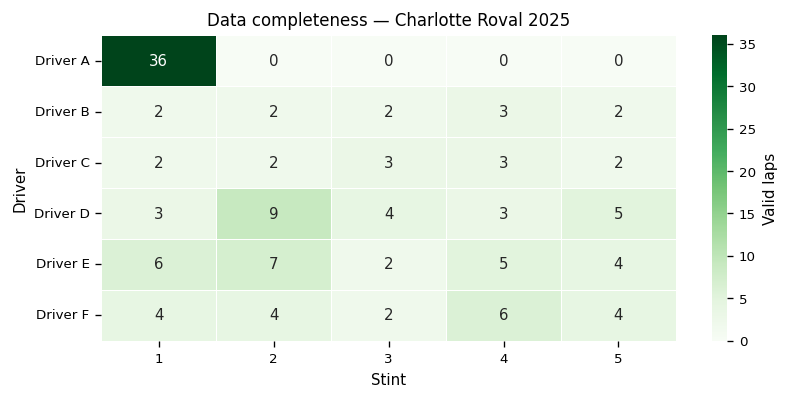

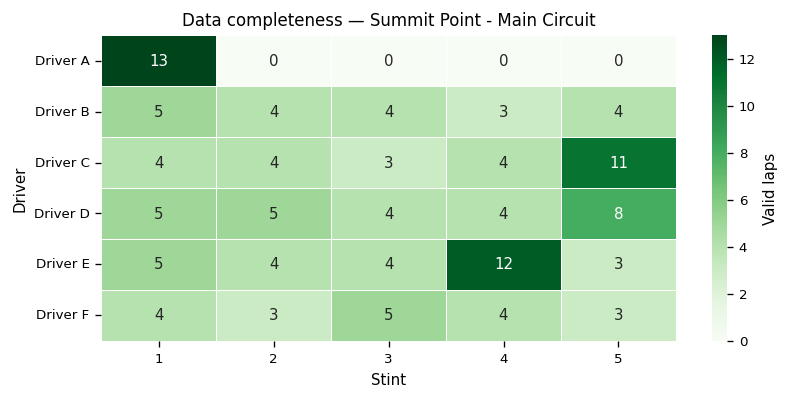

In [47]:

# 2.3 Data-completeness audit figure

def plot_data_completeness(audit_df: pd.DataFrame):
    for track_id in BATCH_TRACKS:
        track_df = audit_df[audit_df["Track"] == track_id].copy()
        if track_df.empty:
            continue

        aliases = [
            DRIVER_TIER[driver]["alias"]
            for driver in DRIVER_ORDER
            if driver in track_df["Driver"].unique()
        ]
        pivot = (
            track_df.pivot(index="Alias", columns="Stint", values="NValidLaps")
            .reindex(index=aliases, columns=STINT_NUMBERS)
        )

        fig, ax = plt.subplots(figsize=(7.0, 3.4))
        sns.heatmap(
            pivot,
            annot=True,
            fmt=".0f",
            cmap="Greens",
            vmin=0,
            cbar_kws={"label": "Valid laps"},
            linewidths=0.6,
            linecolor="white",
            ax=ax,
        )
        ax.set_title(
            f"Data completeness — {TRACK_CONFIGS[track_id]['track_name']}"
        )
        ax.set_xlabel("Stint")
        ax.set_ylabel("Driver")
        fig.tight_layout()
        fig.savefig(
            FIG_DIR / f"QA_data_completeness_{track_id}.pdf",
            bbox_inches="tight",
        )
        fig.savefig(
            FIG_DIR / f"QA_data_completeness_{track_id}.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()


plot_data_completeness(DATA_AUDIT)



## 3. Sector assignment and per-lap Permutation Entropy

PE is computed separately for each valid lap and analytical sector. The stint-level value is
therefore not calculated from one concatenated signal, which would introduce artificial
ordinal patterns at lap boundaries.

For a series of length \(N\), order \(m=3\), and delay \(\tau=1\), the number of available
ordinal patterns is \(N-(m-1)\tau\). Windows with fewer than `PE_MIN_PATTERNS` patterns are
reported as invalid. The notebook also records the adjacent-sample plateau fraction because
brake and throttle signals can contain many repeated values.


In [48]:

# 3.1 Assign analytical sectors to every loaded stint

TRACK_META = {}

for track_id in BATCH_TRACKS:
    cfg = TRACK_CONFIGS[track_id]
    edges = list(cfg["custom_edges"])
    configured_order = list(cfg.get("sector_names", range(1, len(edges))))

    observed_values = []

    for driver, stint_records in LONG_DATA[track_id].items():
        for stint_no, record in stint_records.items():
            df_s = assign_sectors(record["df"].copy(), edges)
            sector_col = "Sector" if "Sector" in df_s.columns else "sector"
            if sector_col not in df_s.columns:
                raise KeyError(
                    f"assign_sectors did not create a Sector/sector column for {track_id}."
                )

            record["df_s"] = df_s
            record["sector_col"] = sector_col
            observed_values.extend(df_s[sector_col].dropna().unique().tolist())

    observed_unique = list(pd.unique(pd.Series(observed_values).dropna()))

    if configured_order and set(configured_order).intersection(observed_unique):
        sector_order = [
            sector for sector in configured_order if sector in observed_unique
        ]
    else:
        try:
            sector_order = sorted(observed_unique)
        except TypeError:
            sector_order = sorted(observed_unique, key=lambda value: str(value))

    if not sector_order:
        sector_order = list(range(1, len(edges)))

    sector_to_index = {
        sector: index + 1 for index, sector in enumerate(sector_order)
    }

    for driver, stint_records in LONG_DATA[track_id].items():
        for stint_no, record in stint_records.items():
            df_s = record["df_s"].copy()
            sector_col = record["sector_col"]
            df_s["SectorRaw"] = df_s[sector_col]
            df_s["SectorIndex"] = df_s["SectorRaw"].map(sector_to_index)
            record["df_s"] = df_s

    TRACK_META[track_id] = {
        "track_name": cfg["track_name"],
        "edges": edges,
        "sector_order": sector_order,
        "sector_to_index": sector_to_index,
        "n_sectors": len(sector_order),
    }

    print(
        f"{cfg['track_name']}: {len(sector_order)} sectors "
        f"({sector_order[:3]} ... {sector_order[-3:]})"
    )


Charlotte Roval 2025: 18 sectors ([1, 2, 3] ... [16, 17, 18])
Summit Point - Main Circuit: 10 sectors ([1, 2, 3] ... [8, 9, 10])


In [49]:

# 3.2 PE estimator and long-format table

def permutation_entropy_record(
    series: Iterable[float],
    order: int = PE_ORDER,
    delay: int = PE_DELAY,
    min_patterns: int = PE_MIN_PATTERNS,
) -> dict:
    values = np.asarray(pd.Series(series).dropna(), dtype=float)
    n_samples = int(values.size)
    n_patterns = n_samples - (order - 1) * delay

    if n_samples > 1:
        scale = max(float(np.nanstd(values)), 1.0)
        plateau_fraction = float(
            np.mean(np.isclose(np.diff(values), 0.0, atol=1e-10 * scale))
        )
    else:
        plateau_fraction = np.nan

    result = {
        "PE_norm": np.nan,
        "NSamples": n_samples,
        "NPatterns": max(n_patterns, 0),
        "PlateauFraction": plateau_fraction,
        "PEValid": False,
    }

    if n_patterns < min_patterns:
        return result

    pe_value = ant.perm_entropy(
        values,
        order=order,
        delay=delay,
        normalize=True,
    )

    result["PE_norm"] = float(pe_value)
    result["PEValid"] = bool(np.isfinite(pe_value))
    return result


def build_pe_long_table() -> pd.DataFrame:
    rows = []

    for track_id in BATCH_TRACKS:
        meta = TRACK_META[track_id]

        for driver in DRIVER_ORDER:
            for stint_no, record in LONG_DATA[track_id].get(driver, {}).items():
                df_s = record["df_s"]

                for lap in sorted(df_s["Lap"].dropna().unique()):
                    lap_df = df_s[df_s["Lap"] == lap]

                    for sector_raw in meta["sector_order"]:
                        sector_df = (
                            lap_df[lap_df["SectorRaw"] == sector_raw]
                            .sort_values("SessionTime")
                        )
                        if sector_df.empty:
                            continue

                        sector_index = meta["sector_to_index"][sector_raw]

                        for variable_col, variable_label in VARIABLES_PE:
                            if variable_col not in sector_df.columns:
                                continue

                            pe_rec = permutation_entropy_record(
                                sector_df[variable_col].values
                            )

                            rows.append(
                                {
                                    "Track": track_id,
                                    "TrackName": meta["track_name"],
                                    "Driver": driver,
                                    "Alias": DRIVER_TIER[driver]["alias"],
                                    "Tier": DRIVER_TIER[driver]["tier"],
                                    "Stint": stint_no,
                                    "Lap": int(lap),
                                    "Sector": sector_raw,
                                    "SectorIndex": sector_index,
                                    "VariableCol": variable_col,
                                    "Variable": variable_label,
                                    **pe_rec,
                                }
                            )

    return pd.DataFrame(rows)


PE_LONG = build_pe_long_table()

if PE_LONG.empty:
    raise RuntimeError(
        "No PE observations were produced. Check the audit table and telemetry columns."
    )

#PE_LONG.to_csv(TABLE_DIR / "pe_per_lap_sector_long.csv", index=False)

print(f"PE rows        : {len(PE_LONG):,}")
print(f"Valid PE rows  : {PE_LONG['PEValid'].sum():,}")
print(f"Invalid rows   : {(~PE_LONG['PEValid']).sum():,}")
display(PE_LONG.head())


PE rows        : 14,424
Valid PE rows  : 14,424
Invalid rows   : 0


,Track,TrackName,Driver,Alias,Tier,Stint,Lap,Sector,SectorIndex,VariableCol,Variable,PE_norm,NSamples,NPatterns,PlateauFraction,PEValid
0,charlotte_roval_2025,Charlotte Roval 2025,Rodrigo,Driver A,Expert,1,8,1,1,Brake_Pct,Brake (%),0.000000,261,259,1.000000,True
1,charlotte_roval_2025,Charlotte Roval 2025,Rodrigo,Driver A,Expert,1,8,1,1,TotalAccel_G,Combined G-Force,0.989184,261,259,0.000000,True
2,charlotte_roval_2025,Charlotte Roval 2025,Rodrigo,Driver A,Expert,1,8,1,1,SteeringWheelAngle,Steering Angle (deg),0.609666,261,259,0.042308,True
3,charlotte_roval_2025,Charlotte Roval 2025,Rodrigo,Driver A,Expert,1,8,1,1,Throttle_Pct,Throttle (%),0.245123,261,259,0.873077,True
4,charlotte_roval_2025,Charlotte Roval 2025,Rodrigo,Driver A,Expert,1,8,2,2,Brake_Pct,Brake (%),0.274819,390,388,0.773779,True


In [50]:

# 3.3 Sector-, stint-, and group-level summaries

valid_pe = PE_LONG[PE_LONG["PEValid"]].copy()

PE_SECTOR = (
    valid_pe.groupby(
        [
            "Track",
            "TrackName",
            "Driver",
            "Alias",
            "Tier",
            "Stint",
            "Sector",
            "SectorIndex",
            "VariableCol",
            "Variable",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        PE_mean=("PE_norm", "mean"),
        PE_median=("PE_norm", "median"),
        PE_sd=("PE_norm", "std"),
        N_laps=("Lap", "nunique"),
        N_patterns_median=("NPatterns", "median"),
        PlateauFraction_mean=("PlateauFraction", "mean"),
    )
)

PE_STINT = (
    PE_SECTOR.groupby(
        [
            "Track",
            "TrackName",
            "Driver",
            "Alias",
            "Tier",
            "Stint",
            "VariableCol",
            "Variable",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        PE_mean=("PE_mean", "mean"),
        PE_median=("PE_mean", "median"),
        PE_q25=("PE_mean", lambda values: values.quantile(0.25)),
        PE_q75=("PE_mean", lambda values: values.quantile(0.75)),
        PE_sd_sector=("PE_mean", "std"),
        N_sectors=("SectorIndex", "nunique"),
        N_laps_min=("N_laps", "min"),
    )
)

# Coached beginners only (C, D, F). Driver E (control) is summarized as an
# individual trajectory and never pooled into the group median.
AMATEUR_STINT = (
    PE_STINT[PE_STINT["Alias"].isin(COACHED_ALIASES)]
    .groupby(
        ["Track", "TrackName", "Stint", "VariableCol", "Variable"],
        observed=True,
        as_index=False,
    )
    .agg(
        PE_group_median=("PE_mean", "median"),
        PE_group_q25=("PE_mean", lambda values: values.quantile(0.25)),
        PE_group_q75=("PE_mean", lambda values: values.quantile(0.75)),
        N_drivers=("Driver", "nunique"),
    )
)

PE_QUALITY = (
    PE_LONG.groupby(
        ["Track", "TrackName", "VariableCol", "Variable"],
        observed=True,
        as_index=False,
    )
    .agg(
        ValidFraction=("PEValid", "mean"),
        PlateauFractionMedian=("PlateauFraction", "median"),
        MedianPatterns=("NPatterns", "median"),
        N_windows=("PEValid", "size"),
    )
)

for table, filename in [
    (PE_SECTOR, "pe_by_sector_stint.csv"),
    (PE_STINT, "pe_by_driver_stint.csv"),
    (AMATEUR_STINT, "pe_coached_group_by_stint.csv"),
    (PE_QUALITY, "pe_quality_summary.csv"),
]:
    table.to_csv(TABLE_DIR / filename, index=False)

display(PE_QUALITY)


,Track,TrackName,VariableCol,Variable,ValidFraction,PlateauFractionMedian,MedianPatterns,N_windows
0,charlotte_roval_2025,Charlotte Roval 2025,Brake_Pct,Brake (%),1.0,0.989608,323.0,2286
1,charlotte_roval_2025,Charlotte Roval 2025,SteeringWheelAngle,Steering Angle (deg),1.0,0.008772,323.0,2286
2,charlotte_roval_2025,Charlotte Roval 2025,Throttle_Pct,Throttle (%),1.0,0.905325,323.0,2286
3,charlotte_roval_2025,Charlotte Roval 2025,TotalAccel_G,Combined G-Force,1.0,0.000000,323.0,2286
4,summit_point,Summit Point - Main Circuit,Brake_Pct,Brake (%),1.0,0.991489,493.5,1320
5,summit_point,Summit Point - Main Circuit,SteeringWheelAngle,Steering Angle (deg),1.0,0.014894,493.5,1320
6,summit_point,Summit Point - Main Circuit,Throttle_Pct,Throttle (%),1.0,0.862383,493.5,1320
7,summit_point,Summit Point - Main Circuit,TotalAccel_G,Combined G-Force,1.0,0.000000,493.5,1320



### Interpretation rule used throughout the notebook

- `PE_mean` describes the **level** of ordinal complexity within a driver/stint/channel.
- `DeltaPE` describes the **direction of departure** from the proficiency-matched reference.
- `MeanAbsDeltaPE` describes **reference distance**, independent of sign.
- A reduction in `MeanAbsDeltaPE` is labeled *behavioral convergence*, not automatically
  *skill improvement*.
- `JSD` describes the **distributional distance** between reference and test
  control-input distributions (fixed $n = 20$ bins); it is symmetric (Lin, 1991)
  and $\sqrt{JSD}$ is a metric (Endres & Schindelin, 2003).
- Performance relevance is evaluated separately with lap-time and sector-time deltas.
- Wilcoxon signed-rank tests (paired by sector, FDR-corrected) separate
  directional evidence from descriptive noise.

This separation avoids treating high or low PE as a direct proxy for proficiency.


## 4. Matched reference comparisons

Every comparison is matched by **track, sector, and telemetry channel**. Stint
matching depends on the design role of the reference driver:

- **B vs A** — Driver A recorded a single expert session per track
  (Stint 1 = `stint_ref`), so each of Driver B's Stints 1–5 is compared with
  that **fixed reference stint**. The `Stint` column therefore always indexes
  the **test** driver; `ReferenceStint` records the stint actually used as
  reference.
- **Beginners vs B** — matched by stint number (Stint $k$ vs Stint $k$).

The coached-group result is calculated from the individual $\Delta PE$ values of
Drivers C, D, F. This two-stage aggregation preserves the driver as the unit of
analysis. Driver E (control) is carried through the identical computation but
reported separately.


In [51]:

# 4.1 Pairwise DeltaPE tables

def build_delta_pe_table(pe_sector: pd.DataFrame) -> pd.DataFrame:
    rows = []
    key_cols = [
        "Track",
        "TrackName",
        "Stint",
        "Sector",
        "SectorIndex",
        "VariableCol",
        "Variable",
    ]

    for comparison in COMPARISONS:
        ref_stint_fixed = comparison.get("ref_stint")

        ref_pool = pe_sector[pe_sector["Driver"] == comparison["ref"]]
        if ref_stint_fixed is not None:
            # Fixed expert reference: Driver A's single stint is compared
            # with every test stint, so "Stint" is dropped from the merge
            # keys and retained from the test side only.
            ref_pool = ref_pool[ref_pool["Stint"] == ref_stint_fixed]
            merge_keys = [column for column in key_cols if column != "Stint"]
        else:
            merge_keys = key_cols

        ref_df = ref_pool[merge_keys + ["PE_mean", "N_laps"]].rename(
            columns={"PE_mean": "PE_ref", "N_laps": "N_laps_ref"}
        )

        test_df = pe_sector[
            pe_sector["Driver"] == comparison["test"]
        ][key_cols + ["PE_mean", "N_laps"]].rename(
            columns={"PE_mean": "PE_test", "N_laps": "N_laps_test"}
        )

        merged = test_df.merge(ref_df, on=merge_keys, how="inner")
        if merged.empty:
            continue

        merged["Comparison"] = comparison["id"]
        merged["ReferenceStint"] = (
            ref_stint_fixed if ref_stint_fixed is not None else merged["Stint"]
        )
        merged["ComparisonGroup"] = comparison["group"]
        merged["ReferenceDriver"] = comparison["ref"]
        merged["TestDriver"] = comparison["test"]
        merged["ReferenceAlias"] = DRIVER_TIER[comparison["ref"]]["alias"]
        merged["TestAlias"] = DRIVER_TIER[comparison["test"]]["alias"]
        merged["DeltaPE"] = merged["PE_test"] - merged["PE_ref"]
        merged["AbsDeltaPE"] = merged["DeltaPE"].abs()

        rows.append(merged)

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


DELTA_PE = build_delta_pe_table(PE_SECTOR)

if DELTA_PE.empty:
    raise RuntimeError(
        "No matched PE comparisons were produced. Verify that reference and test "
        "drivers share track/stint/sector observations."
    )

PAIR_SUMMARY = (
    DELTA_PE.groupby(
        [
            "Track",
            "TrackName",
            "Comparison",
            "ComparisonGroup",
            "ReferenceAlias",
            "TestAlias",
            "Stint",
            "VariableCol",
            "Variable",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        MeanDeltaPE=("DeltaPE", "mean"),
        MedianDeltaPE=("DeltaPE", "median"),
        DeltaPE_q25=("DeltaPE", lambda values: values.quantile(0.25)),
        DeltaPE_q75=("DeltaPE", lambda values: values.quantile(0.75)),
        MeanAbsDeltaPE=("AbsDeltaPE", "mean"),
        RMSE_DeltaPE=("DeltaPE", lambda values: float(np.sqrt(np.mean(values ** 2)))),
        N_sectors=("SectorIndex", "nunique"),
    )
)

PAIR_OVERALL = (
    DELTA_PE.groupby(
        [
            "Track",
            "TrackName",
            "Comparison",
            "ComparisonGroup",
            "ReferenceAlias",
            "TestAlias",
            "Stint",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        MeanDeltaPE=("DeltaPE", "mean"),
        MeanAbsDeltaPE=("AbsDeltaPE", "mean"),
        RMSE_DeltaPE=("DeltaPE", lambda values: float(np.sqrt(np.mean(values ** 2)))),
        N_sector_channel_cells=("DeltaPE", "size"),
    )
)

AMATEUR_DELTA_SECTOR = (
    DELTA_PE[DELTA_PE["Comparison"].isin(COACHED_COMPARISONS)]
    .groupby(
        [
            "Track",
            "TrackName",
            "Stint",
            "Sector",
            "SectorIndex",
            "VariableCol",
            "Variable",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        DeltaPE_group_median=("DeltaPE", "median"),
        DeltaPE_group_q25=("DeltaPE", lambda values: values.quantile(0.25)),
        DeltaPE_group_q75=("DeltaPE", lambda values: values.quantile(0.75)),
        ProportionPositive=("DeltaPE", lambda values: float(np.mean(values > 0))),
        N_drivers=("TestDriver", "nunique"),
    )
)

AMATEUR_DELTA_SECTOR["SignAgreement"] = np.maximum(
    AMATEUR_DELTA_SECTOR["ProportionPositive"],
    1.0 - AMATEUR_DELTA_SECTOR["ProportionPositive"],
)

AMATEUR_DISTANCE = (
    PAIR_SUMMARY[
        PAIR_SUMMARY["Comparison"].isin(COACHED_COMPARISONS)
    ]
    .groupby(
        ["Track", "TrackName", "Stint", "VariableCol", "Variable"],
        observed=True,
        as_index=False,
    )
    .agg(
        MeanAbsDeltaPE_group_median=("MeanAbsDeltaPE", "median"),
        MeanAbsDeltaPE_group_q25=("MeanAbsDeltaPE", lambda values: values.quantile(0.25)),
        MeanAbsDeltaPE_group_q75=("MeanAbsDeltaPE", lambda values: values.quantile(0.75)),
        N_drivers=("Comparison", "nunique"),
    )
)

for table, filename in [
    (DELTA_PE, "delta_pe_by_sector_stint.csv"),
    (PAIR_SUMMARY, "delta_pe_pair_summary.csv"),
    (PAIR_OVERALL, "delta_pe_pair_overall.csv"),
    (AMATEUR_DELTA_SECTOR, "delta_pe_coached_group_sector.csv"),
    (AMATEUR_DISTANCE, "delta_pe_coached_group_distance.csv"),
]:
    table.to_csv(TABLE_DIR / filename, index=False)

display(PAIR_SUMMARY.head())


,Track,TrackName,Comparison,ComparisonGroup,ReferenceAlias,TestAlias,Stint,VariableCol,Variable,MeanDeltaPE,MedianDeltaPE,DeltaPE_q25,DeltaPE_q75,MeanAbsDeltaPE,RMSE_DeltaPE,N_sectors
0,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Intermediate vs Expert,Driver A,Driver B,1,Brake_Pct,Brake (%),-0.013416,0.000000,-0.052613,0.059100,0.079906,0.133645,18
1,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Intermediate vs Expert,Driver A,Driver B,1,SteeringWheelAngle,Steering Angle (deg),-0.017587,-0.020937,-0.047929,-0.005707,0.034203,0.040383,18
2,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Intermediate vs Expert,Driver A,Driver B,1,Throttle_Pct,Throttle (%),0.009713,0.000000,-0.008637,0.030594,0.041828,0.068816,18
3,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Intermediate vs Expert,Driver A,Driver B,1,TotalAccel_G,Combined G-Force,-0.004057,-0.002871,-0.006823,0.000556,0.007379,0.011043,18
4,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Intermediate vs Expert,Driver A,Driver B,2,Brake_Pct,Brake (%),-0.030365,-0.004382,-0.081215,0.000000,0.066985,0.106859,18


In [52]:

# 4.2 Lap-time and sector-time gaps for the same track/stint comparisons

def align_lap_by_distance(
    lap_df: pd.DataFrame,
    grid: np.ndarray,
) -> Dict[str, np.ndarray]:
    lap_df = (
        lap_df.sort_values("LapDistPct")
        .drop_duplicates(subset=["LapDistPct"], keep="first")
    )
    if lap_df.empty:
        return {}

    x = lap_df["LapDistPct"].to_numpy(dtype=float)
    if len(x) < 2 or np.isclose(x.max() - x.min(), 0.0):
        return {}

    t_rel = (
        lap_df["SessionTime"] - lap_df["SessionTime"].iloc[0]
    ).to_numpy(dtype=float)

    return {
        "LapDistPct": grid,
        "t_rel": np.interp(grid, x, t_rel),
    }


def choose_representative_lap(record: dict, mode: str = TIME_PROFILE_MODE) -> int:
    validity = record["validity"]
    valid = validity[validity["Valid"]].copy()

    if valid.empty:
        raise ValueError("No valid lap is available.")

    if mode == "best":
        row = valid.sort_values("LapTime_s").iloc[0]
    elif mode == "median":
        median_time = valid["LapTime_s"].median()
        row = valid.iloc[(valid["LapTime_s"] - median_time).abs().argsort().iloc[0]]
    else:
        raise ValueError("TIME_PROFILE_MODE must be 'best' or 'median'.")

    return int(row["Lap"])


def lap_time_for_lap(record: dict, lap_id: int) -> float:
    validity = record["validity"]
    row = validity[validity["Lap"] == lap_id]
    if row.empty:
        return np.nan
    return float(row.iloc[0]["LapTime_s"])


def sector_time_delta_for_records(
    track_id: str,
    ref_record: dict,
    test_record: dict,
) -> pd.DataFrame:
    meta = TRACK_META[track_id]
    edges = np.asarray(meta["edges"], dtype=float)
    grid = np.linspace(float(edges[0]), float(edges[-1]), 2500)

    ref_lap = choose_representative_lap(ref_record)
    test_lap = choose_representative_lap(test_record)

    ref_interp = align_lap_by_distance(
        ref_record["df"][ref_record["df"]["Lap"] == ref_lap],
        grid,
    )
    test_interp = align_lap_by_distance(
        test_record["df"][test_record["df"]["Lap"] == test_lap],
        grid,
    )

    if not ref_interp or not test_interp:
        return pd.DataFrame()

    cumulative_gap = test_interp["t_rel"] - ref_interp["t_rel"]
    rows = []

    n_intervals = min(len(edges) - 1, meta["n_sectors"])
    for sector_index in range(1, n_intervals + 1):
        start = edges[sector_index - 1]
        end = edges[sector_index]
        mask = (grid >= start) & (grid <= end)
        points = np.flatnonzero(mask)

        if len(points) < 2:
            continue

        rows.append(
            {
                "SectorIndex": sector_index,
                "Sector": meta["sector_order"][sector_index - 1],
                "DeltaTime_s": float(
                    cumulative_gap[points[-1]] - cumulative_gap[points[0]]
                ),
            }
        )

    return pd.DataFrame(rows)


performance_rows = []
sector_time_rows = []

for comparison in COMPARISONS:
    ref_driver = comparison["ref"]
    test_driver = comparison["test"]
    ref_stint_fixed = comparison.get("ref_stint")

    for track_id in BATCH_TRACKS:
        test_stints = sorted(LONG_DATA[track_id].get(test_driver, {}))

        for stint_no in test_stints:
            ref_stint_no = (
                ref_stint_fixed if ref_stint_fixed is not None else stint_no
            )
            if ref_stint_no not in LONG_DATA[track_id].get(ref_driver, {}):
                continue

            ref_record = LONG_DATA[track_id][ref_driver][ref_stint_no]
            test_record = LONG_DATA[track_id][test_driver][stint_no]

            ref_lap = choose_representative_lap(ref_record)
            test_lap = choose_representative_lap(test_record)
            ref_time = lap_time_for_lap(ref_record, ref_lap)
            test_time = lap_time_for_lap(test_record, test_lap)

            performance_rows.append(
                {
                    "Track": track_id,
                    "TrackName": TRACK_META[track_id]["track_name"],
                    "Comparison": comparison["id"],
                    "ReferenceAlias": DRIVER_TIER[ref_driver]["alias"],
                    "TestAlias": DRIVER_TIER[test_driver]["alias"],
                    "Stint": stint_no,
                    "ReferenceStint": ref_stint_no,
                    "ReferenceLap": ref_lap,
                    "TestLap": test_lap,
                    "ReferenceLapTime_s": ref_time,
                    "TestLapTime_s": test_time,
                    "LapGap_s": test_time - ref_time,
                    "TimeProfileMode": TIME_PROFILE_MODE,
                }
            )

            sector_df = sector_time_delta_for_records(
                track_id,
                ref_record,
                test_record,
            )
            if not sector_df.empty:
                sector_df["Track"] = track_id
                sector_df["TrackName"] = TRACK_META[track_id]["track_name"]
                sector_df["Comparison"] = comparison["id"]
                sector_df["Stint"] = stint_no
                sector_time_rows.append(sector_df)

PERFORMANCE = pd.DataFrame(performance_rows)
SECTOR_TIME = (
    pd.concat(sector_time_rows, ignore_index=True)
    if sector_time_rows
    else pd.DataFrame()
)

PERFORMANCE.to_csv(TABLE_DIR / "performance_by_stint.csv", index=False)
SECTOR_TIME.to_csv(TABLE_DIR / "sector_time_delta_by_stint.csv", index=False)

display(PERFORMANCE.head())


,Track,TrackName,Comparison,ReferenceAlias,TestAlias,Stint,ReferenceStint,ReferenceLap,TestLap,ReferenceLapTime_s,TestLapTime_s,LapGap_s,TimeProfileMode
0,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Driver A,Driver B,1,1,12,1,95.483333,96.466667,0.983333,best
1,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Driver A,Driver B,2,1,12,1,95.483333,97.933333,2.450000,best
2,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Driver A,Driver B,3,1,12,2,95.483333,96.066667,0.583333,best
3,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Driver A,Driver B,4,1,12,3,95.483333,97.333333,1.850000,best
4,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Driver A,Driver B,5,1,12,2,95.483333,96.766667,1.283333,best


In [53]:

# 4.3 Sector-level association between DeltaPE and time loss

def safe_correlations(x: np.ndarray, y: np.ndarray) -> dict:
    mask = np.isfinite(x) & np.isfinite(y)
    x = np.asarray(x, dtype=float)[mask]
    y = np.asarray(y, dtype=float)[mask]

    result = {
        "N_sectors": len(x),
        "Pearson_r": np.nan,
        "Pearson_p": np.nan,
        "Spearman_rho": np.nan,
        "Spearman_p": np.nan,
    }

    if len(x) < 4 or np.isclose(np.nanstd(x), 0.0) or np.isclose(np.nanstd(y), 0.0):
        return result

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)
    result.update(
        {
            "Pearson_r": float(pearson_r),
            "Pearson_p": float(pearson_p),
            "Spearman_rho": float(spearman_rho),
            "Spearman_p": float(spearman_p),
        }
    )
    return result


if not SECTOR_TIME.empty:
    pe_time = DELTA_PE.merge(
        SECTOR_TIME[
            [
                "Track",
                "Comparison",
                "Stint",
                "SectorIndex",
                "DeltaTime_s",
            ]
        ],
        on=["Track", "Comparison", "Stint", "SectorIndex"],
        how="inner",
    )

    correlation_rows = []
    group_cols = [
        "Track",
        "TrackName",
        "Comparison",
        "ReferenceAlias",
        "TestAlias",
        "Stint",
        "VariableCol",
        "Variable",
    ]

    for group_key, group_df in pe_time.groupby(group_cols, observed=True):
        stats = safe_correlations(
            group_df["DeltaPE"].to_numpy(),
            group_df["DeltaTime_s"].to_numpy(),
        )
        correlation_rows.append(
            dict(zip(group_cols, group_key)) | stats
        )

    CORR_SUMMARY = pd.DataFrame(correlation_rows)

    CORR_SUMMARY["Pearson_q_FDR"] = np.nan
    CORR_SUMMARY["Pearson_sig_FDR"] = False

    for (track_id, comparison_id), index in CORR_SUMMARY.groupby(
        ["Track", "Comparison"]
    ).groups.items():
        index = list(index)
        mask = CORR_SUMMARY.loc[index, "Pearson_p"].notna()
        selected_index = CORR_SUMMARY.loc[index].index[mask]

        if len(selected_index):
            reject, q_values, _, _ = multipletests(
                CORR_SUMMARY.loc[selected_index, "Pearson_p"],
                alpha=FDR_ALPHA,
                method="fdr_bh",
            )
            CORR_SUMMARY.loc[selected_index, "Pearson_q_FDR"] = q_values
            CORR_SUMMARY.loc[selected_index, "Pearson_sig_FDR"] = reject
else:
    pe_time = pd.DataFrame()
    CORR_SUMMARY = pd.DataFrame()

CORR_SUMMARY.to_csv(
    TABLE_DIR / "delta_pe_sector_time_correlations.csv",
    index=False,
)

display(CORR_SUMMARY.head())


,Track,TrackName,Comparison,ReferenceAlias,TestAlias,Stint,VariableCol,Variable,N_sectors,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,Pearson_q_FDR,Pearson_sig_FDR
0,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Driver A,Driver B,1,Brake_Pct,Brake (%),18,0.007091,0.977721,-0.140854,0.577197,0.998790,False
1,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Driver A,Driver B,1,SteeringWheelAngle,Steering Angle (deg),18,0.244799,0.327561,0.013416,0.957864,0.998790,False
2,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Driver A,Driver B,1,Throttle_Pct,Throttle (%),18,-0.413725,0.087872,-0.563286,0.014925,0.878725,False
3,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Driver A,Driver B,1,TotalAccel_G,Combined G-Force,18,-0.205994,0.412177,-0.172343,0.494076,0.998790,False
4,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Driver A,Driver B,2,Brake_Pct,Brake (%),18,-0.080184,0.751791,-0.175542,0.485969,0.998790,False


## 5. Jensen–Shannon divergence between matched control-input distributions

For each comparison, track, test stint, sector, and channel, the JSD is
computed between the reference and test **sample distributions** (all valid
laps pooled within the sector), using a **fixed global binning of
$n = 20$ bins** per channel and track ($H_{max} = \log_2 20 \approx 4.32$
bits). Fixed binning keeps JSD values directly comparable across drivers,
sectors, stints, and tracks; the Freedman–Diaconis rule remains available only
as a *post-hoc* sensitivity check.

JSD is symmetric and bounded in $[0, 1]$ for log base 2 (Lin, 1991), and
$\sqrt{JSD}$ satisfies the triangle inequality and is therefore a true metric
(Endres & Schindelin, 2003); both are exported. The **B vs A** comparison uses
Driver A's fixed reference stint, so the JSD trajectory of Driver B across
Stints 1–5 measures distributional convergence toward the expert on both
tracks.


In [54]:
# 5.1 Global per-track channel ranges and fixed-bin JSD utilities

GLOBAL_RANGES: Dict[str, Dict[str, Tuple[float, float]]] = {}

for track_id in BATCH_TRACKS:
    channel_values = {column: [] for column, _ in VARIABLES_PE}

    for driver, stint_records in LONG_DATA[track_id].items():
        for record in stint_records.values():
            df_stint = record["df"]
            for column, _ in VARIABLES_PE:
                if column in df_stint.columns:
                    channel_values[column].append(
                        df_stint[column].dropna().to_numpy(dtype=float)
                    )

    track_ranges = {}
    for column, _ in VARIABLES_PE:
        if channel_values[column]:
            values = np.concatenate(channel_values[column])
            low, high = np.percentile(values, [1, 99])
            if np.isfinite(low) and np.isfinite(high) and high > low:
                track_ranges[column] = (float(low), float(high))
    GLOBAL_RANGES[track_id] = track_ranges

    print(f"{TRACK_META[track_id]['track_name']} global ranges (1st-99th pct):")
    for column, (low, high) in track_ranges.items():
        print(f"  {column:<20} [{low:9.3f}, {high:9.3f}]")


def pmf(data: np.ndarray, n_bins: int, v_range: Tuple[float, float]) -> Optional[np.ndarray]:
    """Empirical probability mass function on a fixed grid."""
    values = np.asarray(data, dtype=float)
    values = values[np.isfinite(values)]
    counts, _ = np.histogram(values, bins=n_bins, range=v_range)
    total = counts.sum()
    if total == 0:
        return None
    return counts.astype(float) / total


def compute_jsd(
    data_a: np.ndarray,
    data_b: np.ndarray,
    v_range: Tuple[float, float],
    n_bins: int = N_BINS_FIXED,
) -> Tuple[float, float]:
    """Jensen-Shannon divergence in [0, 1] (log base 2).

    scipy's jensenshannon returns the *distance* sqrt(JSD); squaring recovers
    the divergence (Lin, 1991). sqrt(JSD) is itself a metric satisfying the
    triangle inequality (Endres & Schindelin, 2003) and is returned alongside.
    n_bins is fixed at 20 by default; pass a different value only for
    sensitivity checks.
    """
    p = pmf(data_a, n_bins, v_range)
    q = pmf(data_b, n_bins, v_range)
    if p is None or q is None:
        return np.nan, np.nan
    jsd_sqrt = float(jensenshannon(p, q, base=2))
    return jsd_sqrt ** 2, jsd_sqrt


print(f"\nJSD utilities loaded. Fixed binning: n_bins = {N_BINS_FIXED} "
      f"(H_max = {math.log2(N_BINS_FIXED):.3f} bits)")

Charlotte Roval 2025 global ranges (1st-99th pct):
  Brake_Pct            [    0.000,    74.218]
  TotalAccel_G         [    0.073,     1.800]
  SteeringWheelAngle   [   -2.092,     2.362]
  Throttle_Pct         [    0.000,   100.000]
Summit Point - Main Circuit global ranges (1st-99th pct):
  Brake_Pct            [    0.000,    88.642]
  TotalAccel_G         [    0.062,     1.818]
  SteeringWheelAngle   [   -1.994,     1.905]
  Throttle_Pct         [    0.000,   100.000]

JSD utilities loaded. Fixed binning: n_bins = 20 (H_max = 4.322 bits)


In [55]:
# 5.2 Sector x stint JSD for every matched comparison

def build_jsd_table() -> pd.DataFrame:
    rows = []

    for comparison in COMPARISONS:
        ref_driver = comparison["ref"]
        test_driver = comparison["test"]
        ref_stint_fixed = comparison.get("ref_stint")

        for track_id in BATCH_TRACKS:
            meta = TRACK_META[track_id]
            ranges = GLOBAL_RANGES[track_id]
            test_stints = sorted(LONG_DATA[track_id].get(test_driver, {}))

            for stint_no in test_stints:
                ref_stint_no = (
                    ref_stint_fixed if ref_stint_fixed is not None else stint_no
                )
                ref_record = LONG_DATA[track_id].get(ref_driver, {}).get(ref_stint_no)
                test_record = LONG_DATA[track_id][test_driver][stint_no]
                if ref_record is None:
                    continue

                ref_df = ref_record["df_s"]
                test_df = test_record["df_s"]

                for sector_raw in meta["sector_order"]:
                    sector_index = meta["sector_to_index"][sector_raw]
                    ref_sector = ref_df[ref_df["SectorRaw"] == sector_raw]
                    test_sector = test_df[test_df["SectorRaw"] == sector_raw]

                    for column, label in VARIABLES_PE:
                        if (
                            column not in ranges
                            or column not in ref_sector.columns
                            or column not in test_sector.columns
                        ):
                            continue

                        ref_values = ref_sector[column].dropna().to_numpy(dtype=float)
                        test_values = test_sector[column].dropna().to_numpy(dtype=float)

                        enough = (
                            ref_values.size >= MIN_JSD_SAMPLES
                            and test_values.size >= MIN_JSD_SAMPLES
                        )
                        jsd_value = jsd_sqrt = np.nan
                        if enough:
                            jsd_value, jsd_sqrt = compute_jsd(
                                ref_values, test_values, ranges[column]
                            )

                        rows.append(
                            {
                                "Track": track_id,
                                "TrackName": meta["track_name"],
                                "Comparison": comparison["id"],
                                "ComparisonGroup": comparison["group"],
                                "ReferenceAlias": DRIVER_TIER[ref_driver]["alias"],
                                "TestAlias": DRIVER_TIER[test_driver]["alias"],
                                "Stint": stint_no,
                                "ReferenceStint": ref_stint_no,
                                "Sector": sector_raw,
                                "SectorIndex": sector_index,
                                "VariableCol": column,
                                "Variable": label,
                                "JSD": jsd_value,
                                "JSD_sqrt": jsd_sqrt,
                                "N_ref_samples": int(ref_values.size),
                                "N_test_samples": int(test_values.size),
                                "N_bins": N_BINS_FIXED,
                                "JSDValid": bool(enough and np.isfinite(jsd_value)),
                            }
                        )

    return pd.DataFrame(rows)


JSD_SECTOR = build_jsd_table()

if JSD_SECTOR.empty:
    raise RuntimeError(
        "No JSD observations were produced. Check GLOBAL_RANGES and the audit table."
    )

VALID_JSD = JSD_SECTOR[JSD_SECTOR["JSDValid"]].copy()

# Stint-level summary: mean/median JSD across sectors, per channel.
JSD_PAIR = (
    VALID_JSD.groupby(
        [
            "Track",
            "TrackName",
            "Comparison",
            "ComparisonGroup",
            "ReferenceAlias",
            "TestAlias",
            "Stint",
            "VariableCol",
            "Variable",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        JSD_mean=("JSD", "mean"),
        JSD_median=("JSD", "median"),
        JSD_q25=("JSD", lambda values: values.quantile(0.25)),
        JSD_q75=("JSD", lambda values: values.quantile(0.75)),
        JSDsqrt_mean=("JSD_sqrt", "mean"),
        N_sectors=("SectorIndex", "nunique"),
    )
)

# Coached-group (C, D, F) driver-level median per stint. Driver E excluded.
JSD_COACHED = (
    JSD_PAIR[JSD_PAIR["Comparison"].isin(COACHED_COMPARISONS)]
    .groupby(
        ["Track", "TrackName", "Stint", "VariableCol", "Variable"],
        observed=True,
        as_index=False,
    )
    .agg(
        JSD_group_median=("JSD_mean", "median"),
        JSD_group_q25=("JSD_mean", lambda values: values.quantile(0.25)),
        JSD_group_q75=("JSD_mean", lambda values: values.quantile(0.75)),
        N_drivers=("Comparison", "nunique"),
    )
)

# Coached-group sector-level median (for the sector x stint JSD map).
JSD_COACHED_SECTOR = (
    VALID_JSD[VALID_JSD["Comparison"].isin(COACHED_COMPARISONS)]
    .groupby(
        ["Track", "TrackName", "Stint", "Sector", "SectorIndex",
         "VariableCol", "Variable"],
        observed=True,
        as_index=False,
    )
    .agg(
        JSD_group_median=("JSD", "median"),
        N_drivers=("TestAlias", "nunique"),
    )
)

for table, filename in [
    (JSD_SECTOR, "jsd_by_sector_stint.csv"),
    (JSD_PAIR, "jsd_pair_summary.csv"),
    (JSD_COACHED, "jsd_coached_group_by_stint.csv"),
    (JSD_COACHED_SECTOR, "jsd_coached_group_sector.csv"),
]:
    table.to_csv(TABLE_DIR / filename, index=False)

print(f"JSD rows       : {len(JSD_SECTOR):,}")
print(f"Valid JSD rows : {len(VALID_JSD):,}")
display(JSD_PAIR.head())

JSD rows       : 2,800
Valid JSD rows : 2,800


,Track,TrackName,Comparison,ComparisonGroup,ReferenceAlias,TestAlias,Stint,VariableCol,Variable,JSD_mean,JSD_median,JSD_q25,JSD_q75,JSDsqrt_mean,N_sectors
0,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Intermediate vs Expert,Driver A,Driver B,1,Brake_Pct,Brake (%),0.032108,0.023158,0.000543,0.045186,0.134998,18
1,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Intermediate vs Expert,Driver A,Driver B,1,SteeringWheelAngle,Steering Angle (deg),0.069123,0.074696,0.019845,0.085750,0.231994,18
2,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Intermediate vs Expert,Driver A,Driver B,1,Throttle_Pct,Throttle (%),0.038891,0.013140,0.003364,0.028687,0.139949,18
3,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Intermediate vs Expert,Driver A,Driver B,1,TotalAccel_G,Combined G-Force,0.062821,0.031167,0.021045,0.050791,0.215703,18
4,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Intermediate vs Expert,Driver A,Driver B,2,Brake_Pct,Brake (%),0.033109,0.023143,0.000543,0.051634,0.139361,18


## 6. Wilcoxon signed-rank significance tests

Two families of paired tests validate the descriptive patterns, with sectors as
the matched unit:

1. **Shift test** — for each track × comparison × stint × channel, a Wilcoxon
   signed-rank test on the sector-wise $\Delta PE$ values
   ($H_0$: median $\Delta PE = 0$). The matched-pairs rank-biserial correlation
   $r$ is reported as effect size.
2. **Convergence test** — for each track × comparison × channel, a paired
   Wilcoxon test between the **first** and **last** available stint, by sector,
   applied to $|\Delta PE|$ and to JSD. A negative median change
   (last $-$ first) indicates convergence toward the proficiency-matched
   reference.

$p$-values are adjusted with Benjamini–Hochberg FDR within each
track × comparison family ($\alpha = 0.05$). Because sectors are repeated
observations from the same drivers, significant results are interpreted as
**within-driver directional evidence**, not population-level effects.


In [56]:
# 6.1 Shift test: sector-wise DeltaPE against zero, per stint and channel

def wilcoxon_matched_by_sector(delta_values: np.ndarray):
    """Paired Wilcoxon signed-rank across sectors. H0: median(delta) = 0.
    Returns (statistic, p, matched-pairs rank-biserial r, n)."""
    deltas = np.asarray(delta_values, dtype=float)
    deltas = deltas[np.isfinite(deltas)]
    deltas = deltas[deltas != 0]
    n = len(deltas)
    if n < 4:
        return np.nan, np.nan, np.nan, n
    statistic, p_value = wilcoxon(
        deltas, alternative="two-sided", zero_method="wilcox"
    )
    ranks = rankdata(np.abs(deltas))
    w_pos = ranks[deltas > 0].sum()
    w_neg = ranks[deltas < 0].sum()
    r_rb = (w_pos - w_neg) / (w_pos + w_neg)
    return float(statistic), float(p_value), float(r_rb), n


def apply_fdr(
    df: pd.DataFrame,
    pcol: str = "p_value",
    alpha: float = FDR_ALPHA,
    group_cols=None,
) -> pd.DataFrame:
    """Benjamini-Hochberg FDR, optionally within groups (test families)."""
    df = df.copy()
    df["p_adj_FDR"] = np.nan
    df["sig_FDR"] = False

    if group_cols:
        group_indices = df.groupby(group_cols, observed=True).groups.values()
    else:
        group_indices = [df.index]

    for indices in group_indices:
        indices = list(indices)
        mask = df.loc[indices, pcol].notna()
        selected = df.loc[indices].index[mask]
        if len(selected):
            reject, p_adjusted, _, _ = multipletests(
                df.loc[selected, pcol], alpha=alpha, method="fdr_bh"
            )
            df.loc[selected, "p_adj_FDR"] = p_adjusted
            df.loc[selected, "sig_FDR"] = reject
    return df


shift_rows = []
shift_group_cols = [
    "Track",
    "TrackName",
    "Comparison",
    "ReferenceAlias",
    "TestAlias",
    "Stint",
    "VariableCol",
    "Variable",
]

for group_key, group_df in DELTA_PE.groupby(shift_group_cols, observed=True):
    statistic, p_value, r_rb, n = wilcoxon_matched_by_sector(
        group_df["DeltaPE"].to_numpy()
    )
    shift_rows.append(
        dict(zip(shift_group_cols, group_key))
        | {
            "MedianDeltaPE": float(group_df["DeltaPE"].median()),
            "W": statistic,
            "p_value": p_value,
            "r_rank_biserial": r_rb,
            "N_sectors": n,
        }
    )

WILCOXON_DPE = apply_fdr(
    pd.DataFrame(shift_rows),
    group_cols=["Track", "Comparison"],
)

WILCOXON_DPE.to_csv(TABLE_DIR / "wilcoxon_delta_pe_by_stint.csv", index=False)

n_sig = int(WILCOXON_DPE["sig_FDR"].sum())
print(f"Shift tests    : {len(WILCOXON_DPE)}  |  significant (FDR): {n_sig}")
display(
    WILCOXON_DPE[WILCOXON_DPE["sig_FDR"]]
    .sort_values(["Track", "Comparison", "Stint"])
    .head(12)
)

Shift tests    : 200  |  significant (FDR): 40


,Track,TrackName,Comparison,ReferenceAlias,TestAlias,Stint,VariableCol,Variable,MedianDeltaPE,W,p_value,r_rank_biserial,N_sectors,p_adj_FDR,sig_FDR
13,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Driver A,Driver B,4,SteeringWheelAngle,Steering Angle (deg),-0.028377,19.0,0.002335,-0.777778,18,0.046692,True
21,charlotte_roval_2025,Charlotte Roval 2025,C_vs_B,Driver B,Driver C,1,SteeringWheelAngle,Steering Angle (deg),-0.060201,21.0,0.003365,-0.754386,18,0.033646,True
29,charlotte_roval_2025,Charlotte Roval 2025,C_vs_B,Driver B,Driver C,3,SteeringWheelAngle,Steering Angle (deg),-0.044422,3.0,0.000038,-0.964912,18,0.000763,True
41,charlotte_roval_2025,Charlotte Roval 2025,D_vs_B,Driver B,Driver D,1,SteeringWheelAngle,Steering Angle (deg),0.064320,20.0,0.002808,0.766082,18,0.014038,True
45,charlotte_roval_2025,Charlotte Roval 2025,D_vs_B,Driver B,Driver D,2,SteeringWheelAngle,Steering Angle (deg),0.073022,4.0,0.000053,0.953216,18,0.000534,True
49,charlotte_roval_2025,Charlotte Roval 2025,D_vs_B,Driver B,Driver D,3,SteeringWheelAngle,Steering Angle (deg),0.044298,18.0,0.001930,0.789474,18,0.012868,True
53,charlotte_roval_2025,Charlotte Roval 2025,D_vs_B,Driver B,Driver D,4,SteeringWheelAngle,Steering Angle (deg),0.074454,0.0,0.000008,1.000000,18,0.000153,True
65,charlotte_roval_2025,Charlotte Roval 2025,E_vs_B,Driver B,Driver E,2,SteeringWheelAngle,Steering Angle (deg),-0.036367,15.0,0.001045,-0.824561,18,0.010452,True
66,charlotte_roval_2025,Charlotte Roval 2025,E_vs_B,Driver B,Driver E,2,Throttle_Pct,Throttle (%),0.073946,13.0,0.002686,0.808824,16,0.017904,True
73,charlotte_roval_2025,Charlotte Roval 2025,E_vs_B,Driver B,Driver E,4,SteeringWheelAngle,Steering Angle (deg),0.034819,15.0,0.001045,0.824561,18,0.010452,True


In [57]:
# 6.2 Convergence test: first vs last available stint, paired by sector
# Applied to |DeltaPE| and to JSD. Negative median change = convergence.

def paired_first_last_test(sector_df: pd.DataFrame, value_col: str):
    stints = sorted(sector_df["Stint"].dropna().unique())
    if len(stints) < 2:
        return None
    first_stint, last_stint = int(stints[0]), int(stints[-1])

    pivot = sector_df.pivot_table(
        index="SectorIndex",
        columns="Stint",
        values=value_col,
        aggfunc="mean",
    )
    if first_stint not in pivot.columns or last_stint not in pivot.columns:
        return None

    paired = pivot[[first_stint, last_stint]].dropna()
    first_values = paired[first_stint].to_numpy(dtype=float)
    last_values = paired[last_stint].to_numpy(dtype=float)
    differences = last_values - first_values
    nonzero = differences[differences != 0]
    n = len(nonzero)
    if n < 4:
        return None

    statistic, p_value = wilcoxon(
        nonzero, alternative="two-sided", zero_method="wilcox"
    )
    ranks = rankdata(np.abs(nonzero))
    w_pos = ranks[nonzero > 0].sum()
    w_neg = ranks[nonzero < 0].sum()
    r_rb = (w_pos - w_neg) / (w_pos + w_neg)

    return {
        "FirstStint": first_stint,
        "LastStint": last_stint,
        "Median_first": float(np.median(first_values)),
        "Median_last": float(np.median(last_values)),
        "MedianChange_last_minus_first": float(np.median(differences)),
        "W": float(statistic),
        "p_value": float(p_value),
        "r_rank_biserial": float(r_rb),
        "N_paired_sectors": n,
    }


convergence_rows = []
convergence_sources = [
    ("AbsDeltaPE", DELTA_PE, "AbsDeltaPE"),
    ("JSD", VALID_JSD, "JSD"),
]

for metric_name, source_df, value_col in convergence_sources:
    group_cols = ["Track", "TrackName", "Comparison", "VariableCol", "Variable"]
    for group_key, group_df in source_df.groupby(group_cols, observed=True):
        result = paired_first_last_test(group_df, value_col)
        if result is None:
            continue
        convergence_rows.append(
            {"Metric": metric_name} | dict(zip(group_cols, group_key)) | result
        )

WILCOXON_LONGITUDINAL = apply_fdr(
    pd.DataFrame(convergence_rows),
    group_cols=["Track", "Comparison", "Metric"],
)

WILCOXON_LONGITUDINAL.to_csv(
    TABLE_DIR / "wilcoxon_first_vs_last_stint.csv", index=False
)

n_sig = int(WILCOXON_LONGITUDINAL["sig_FDR"].sum())
print(
    f"Convergence tests: {len(WILCOXON_LONGITUDINAL)}  |  "
    f"significant (FDR): {n_sig}"
)
display(
    WILCOXON_LONGITUDINAL.sort_values(
        ["Track", "Metric", "Comparison", "Variable"]
    ).head(16)
)

Convergence tests: 80  |  significant (FDR): 2


,Metric,Track,TrackName,Comparison,VariableCol,Variable,FirstStint,LastStint,Median_first,Median_last,MedianChange_last_minus_first,W,p_value,r_rank_biserial,N_paired_sectors,p_adj_FDR,sig_FDR
0,AbsDeltaPE,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Brake_Pct,Brake (%),1,5,0.064608,0.041930,0.000000,23.0,0.413086,-0.303030,11,0.826172,False
3,AbsDeltaPE,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,TotalAccel_G,Combined G-Force,1,5,0.003474,0.003901,0.000370,79.0,0.798706,-0.076023,18,0.946045,False
1,AbsDeltaPE,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,SteeringWheelAngle,Steering Angle (deg),1,5,0.026298,0.050175,0.004826,24.0,0.005600,0.719298,18,0.022400,True
2,AbsDeltaPE,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Throttle_Pct,Throttle (%),1,5,0.023448,0.032939,0.000000,44.0,0.946045,0.032967,13,0.946045,False
4,AbsDeltaPE,charlotte_roval_2025,Charlotte Roval 2025,C_vs_B,Brake_Pct,Brake (%),1,5,0.015727,0.008883,-0.000361,16.0,0.077148,-0.589744,12,0.172984,False
7,AbsDeltaPE,charlotte_roval_2025,Charlotte Roval 2025,C_vs_B,TotalAccel_G,Combined G-Force,1,5,0.002548,0.006399,0.000973,50.0,0.129738,0.415205,18,0.172984,False
5,AbsDeltaPE,charlotte_roval_2025,Charlotte Roval 2025,C_vs_B,SteeringWheelAngle,Steering Angle (deg),1,5,0.068496,0.078506,0.004035,77.0,0.733727,-0.099415,18,0.733727,False
6,AbsDeltaPE,charlotte_roval_2025,Charlotte Roval 2025,C_vs_B,Throttle_Pct,Throttle (%),1,5,0.066511,0.053255,0.000000,22.0,0.109863,-0.516484,13,0.172984,False
8,AbsDeltaPE,charlotte_roval_2025,Charlotte Roval 2025,D_vs_B,Brake_Pct,Brake (%),1,5,0.050318,0.031828,-0.021779,18.0,0.029541,-0.657143,14,0.118164,False
11,AbsDeltaPE,charlotte_roval_2025,Charlotte Roval 2025,D_vs_B,TotalAccel_G,Combined G-Force,1,5,0.004927,0.003593,-0.003251,43.0,0.066536,-0.497076,18,0.133072,False


In [58]:
# =============================================================================
# CELULAS ADICIONAIS - Resposta ao Revisor 1, item (2)
# Effect sizes, confidence intervals, lap-time significance, inter-driver
# variability.
#
# Insira estas celulas no notebook entropy_JSD_PE_Pipeline_v4.ipynb.
# Posicao recomendada: logo APOS a celula "6.2 Convergence test" e ANTES da
# secao 7 (Publication style).
#
# Cada bloco delimitado por "# %%" e uma celula separada do notebook.
# =============================================================================


# %% ==========================================================================
# CELULA 6.3 - Infraestrutura de intervalos de confianca
# =============================================================================

from itertools import permutations

from scipy.stats import bootstrap, rankdata, spearmanr, theilslopes

# Parametros de reamostragem. Semente fixa => resultado reproduzivel.
N_BOOT = 10_000
CI_LEVEL = 0.95
BOOT_SEED = RANDOM_SEED


def hodges_lehmann(values) -> float:
    """Pseudo-mediana de Hodges-Lehmann: mediana das medias de Walsh.

    Este e o estimador pontual que corresponde ao teste de Wilcoxon dos
    postos sinalizados. A mediana amostral comum nao e o estimador do
    Wilcoxon, por isso ela nao deve ser reportada junto do valor-p.
    """
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.nan
    walsh = (v[:, None] + v[None, :]) / 2.0
    upper = np.triu_indices(v.size, k=0)
    return float(np.median(walsh[upper]))


def rank_biserial(values) -> float:
    """Correlacao biserial de postos para pares casados (mesmo r da celula 6.1).

    Reescrita aqui como funcao de um unico vetor para poder ser passada
    diretamente ao reamostrador.
    """
    d = np.asarray(values, dtype=float)
    d = d[np.isfinite(d)]
    d = d[d != 0]
    if d.size == 0:
        return np.nan
    ranks = rankdata(np.abs(d))
    w_pos = ranks[d > 0].sum()
    w_neg = ranks[d < 0].sum()
    total = w_pos + w_neg
    return float((w_pos - w_neg) / total) if total else np.nan


def bootstrap_ci(
    values,
    statistic,
    n_boot: int = N_BOOT,
    level: float = CI_LEVEL,
    seed: int = BOOT_SEED,
    min_n: int = 4,
):
    """IC por reamostragem. Tenta BCa; cai para percentil se BCa degenerar.

    Retorna (limite_inferior, limite_superior, metodo).
    """
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if v.size < min_n or np.allclose(v, v[0]):
        return np.nan, np.nan, "insufficient"

    for method in ("BCa", "percentile"):
        try:
            result = bootstrap(
                (v,),
                statistic,
                n_resamples=n_boot,
                confidence_level=level,
                method=method,
                random_state=np.random.default_rng(seed),
                vectorized=False,
            )
            low = float(result.confidence_interval.low)
            high = float(result.confidence_interval.high)
            if np.isfinite(low) and np.isfinite(high):
                return low, high, method
        except Exception:
            continue

    return np.nan, np.nan, "failed"


def format_ci(point, low, high, decimals: int = 3) -> str:
    """Formata 'valor [inf; sup]' para uso direto em tabela LaTeX."""
    if not np.isfinite(point):
        return "--"
    if not (np.isfinite(low) and np.isfinite(high)):
        return f"{point:.{decimals}f}"
    return f"{point:.{decimals}f} [{low:.{decimals}f}; {high:.{decimals}f}]"


print(
    f"Bootstrap configurado: {N_BOOT:,} reamostragens | "
    f"nivel {CI_LEVEL:.0%} | semente {BOOT_SEED}"
)


# %% ==========================================================================
# CELULA 6.4 - IC para o deslocamento de PE por setor (tabela WILCOXON_DPE)
# =============================================================================

# Recalcula, para cada teste ja presente em WILCOXON_DPE, a pseudo-mediana de
# Hodges-Lehmann e o IC do tamanho de efeito r. As colunas novas sao anexadas a
# tabela original; nenhum valor existente e alterado.

CI_GROUP_COLS = [
    "Track",
    "TrackName",
    "Comparison",
    "ReferenceAlias",
    "TestAlias",
    "Stint",
    "VariableCol",
    "Variable",
]

ci_rows = []

for group_key, group_df in DELTA_PE.groupby(CI_GROUP_COLS, observed=True):
    values = group_df["DeltaPE"].to_numpy(dtype=float)

    hl_point = hodges_lehmann(values)
    hl_low, hl_high, hl_method = bootstrap_ci(values, hodges_lehmann)

    r_point = rank_biserial(values)
    r_low, r_high, r_method = bootstrap_ci(values, rank_biserial)

    ci_rows.append(
        dict(zip(CI_GROUP_COLS, group_key))
        | {
            "HL_DeltaPE": hl_point,
            "HL_CI_low": hl_low,
            "HL_CI_high": hl_high,
            "HL_CI_method": hl_method,
            "r_CI_low": r_low,
            "r_CI_high": r_high,
            "r_CI_method": r_method,
        }
    )

WILCOXON_DPE_CI = WILCOXON_DPE.merge(
    pd.DataFrame(ci_rows),
    on=CI_GROUP_COLS,
    how="left",
)

WILCOXON_DPE_CI["HL_reported"] = [
    format_ci(row.HL_DeltaPE, row.HL_CI_low, row.HL_CI_high)
    for row in WILCOXON_DPE_CI.itertuples()
]
WILCOXON_DPE_CI["r_reported"] = [
    format_ci(row.r_rank_biserial, row.r_CI_low, row.r_CI_high)
    for row in WILCOXON_DPE_CI.itertuples()
]

WILCOXON_DPE_CI.to_csv(
    TABLE_DIR / "wilcoxon_delta_pe_with_ci.csv", index=False
)

n_sig = int(WILCOXON_DPE_CI["sig_FDR"].sum())
n_ci_ok = int(WILCOXON_DPE_CI["HL_CI_low"].notna().sum())
print(
    f"Testes com IC calculado: {n_ci_ok}/{len(WILCOXON_DPE_CI)}  |  "
    f"significativos (FDR q < {FDR_ALPHA}): {n_sig}"
)

display(
    WILCOXON_DPE_CI.loc[
        WILCOXON_DPE_CI["sig_FDR"],
        [
            "TrackName",
            "Comparison",
            "Stint",
            "Variable",
            "HL_reported",
            "r_reported",
            "p_adj_FDR",
            "N_sectors",
        ],
    ]
    .sort_values(["TrackName", "Comparison", "Stint"])
    .head(15)
)


# %% ==========================================================================
# CELULA 6.5 - IC para a JSD media por stint
# =============================================================================

# A JSD e resumida por stint como media entre setores. O IC e obtido
# reamostrando setores dentro de cada combinacao pista x comparacao x stint x
# canal. Alimenta as faixas sombreadas das figuras longitudinais de JSD.

JSD_CI_GROUP_COLS = [
    "Track",
    "TrackName",
    "Comparison",
    "ReferenceAlias",
    "TestAlias",
    "Stint",
    "VariableCol",
    "Variable",
]

jsd_ci_rows = []

for group_key, group_df in VALID_JSD.groupby(JSD_CI_GROUP_COLS, observed=True):
    values = group_df["JSD"].to_numpy(dtype=float)
    low, high, method = bootstrap_ci(values, np.mean)

    jsd_ci_rows.append(
        dict(zip(JSD_CI_GROUP_COLS, group_key))
        | {
            "JSD_mean": float(np.nanmean(values)),
            "JSD_CI_low": low,
            "JSD_CI_high": high,
            "JSD_CI_method": method,
            "N_sectors": int(np.isfinite(values).sum()),
        }
    )

JSD_CI = pd.DataFrame(jsd_ci_rows)
JSD_CI["JSD_reported"] = [
    format_ci(row.JSD_mean, row.JSD_CI_low, row.JSD_CI_high)
    for row in JSD_CI.itertuples()
]

JSD_CI.to_csv(TABLE_DIR / "jsd_mean_with_ci.csv", index=False)

print(f"Linhas de JSD com IC: {len(JSD_CI)}")
display(
    JSD_CI[
        ["TrackName", "Comparison", "Stint", "Variable", "JSD_reported", "N_sectors"]
    ].head(12)
)


# %% ==========================================================================
# CELULA 6.6 - Tendencia do tempo de volta ao longo dos stints
# =============================================================================

# Cada piloto tem no maximo 5 stints, entao o numero de permutacoes possiveis e
# 5! = 120. Isso permite um valor-p EXATO por permutacao, sem aproximacao
# assintotica -- o que e essencial com amostra tao pequena.
#
# Estimador de inclinacao: Theil-Sen (mediana das inclinacoes par a par), com
# IC distribuicao-livre derivado da estatistica de Kendall. Unidade: segundos
# de gap recuperados por stint.

MIN_STINTS_TREND = 4


def exact_permutation_spearman(x, y):
    """Spearman com valor-p exato por permutacao (bilateral).

    Retorna (rho, p_exato, n_permutacoes).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    n = x.size

    if n < MIN_STINTS_TREND:
        return np.nan, np.nan, 0

    rho_observed, _ = spearmanr(x, y)
    if not np.isfinite(rho_observed):
        return np.nan, np.nan, 0

    all_orders = list(permutations(range(n)))
    extreme = 0
    for order in all_orders:
        rho_perm, _ = spearmanr(x, y[list(order)])
        if np.isfinite(rho_perm) and abs(rho_perm) >= abs(rho_observed) - 1e-12:
            extreme += 1

    return float(rho_observed), extreme / len(all_orders), len(all_orders)


trend_rows = []

for (track_id, comparison), group_df in PERFORMANCE.groupby(
    ["Track", "Comparison"], observed=True
):
    series = (
        group_df[["Stint", "LapGap_s"]]
        .dropna()
        .sort_values("Stint")
    )
    stints = series["Stint"].to_numpy(dtype=float)
    gaps = series["LapGap_s"].to_numpy(dtype=float)

    if stints.size < MIN_STINTS_TREND:
        continue

    rho, p_exact, n_perm = exact_permutation_spearman(stints, gaps)

    slope, intercept, slope_low, slope_high = theilslopes(
        gaps, stints, alpha=CI_LEVEL
    )

    trend_rows.append(
        {
            "Track": track_id,
            "TrackName": TRACK_META[track_id]["track_name"],
            "Comparison": comparison,
            "TestAlias": group_df["TestAlias"].iloc[0],
            "N_stints": int(stints.size),
            "LapGap_first_s": float(gaps[0]),
            "LapGap_last_s": float(gaps[-1]),
            "DeltaLapGap_s": float(gaps[-1] - gaps[0]),
            "TheilSen_slope_s_per_stint": float(slope),
            "TheilSen_CI_low": float(slope_low),
            "TheilSen_CI_high": float(slope_high),
            "TheilSen_intercept": float(intercept),
            "Spearman_rho": rho,
            "p_value": p_exact,
            "N_permutations": n_perm,
        }
    )

LAPTIME_TREND = apply_fdr(
    pd.DataFrame(trend_rows),
    pcol="p_value",
    alpha=FDR_ALPHA,
    group_cols=["Track"],
)

LAPTIME_TREND["slope_reported"] = [
    format_ci(
        row.TheilSen_slope_s_per_stint,
        row.TheilSen_CI_low,
        row.TheilSen_CI_high,
    )
    for row in LAPTIME_TREND.itertuples()
]

LAPTIME_TREND.to_csv(TABLE_DIR / "laptime_trend_by_driver.csv", index=False)

print(
    f"Testes de tendencia: {len(LAPTIME_TREND)}  |  "
    f"significativos (FDR): {int(LAPTIME_TREND['sig_FDR'].sum())}  |  "
    f"p minimo alcancavel com 5 stints: {1/120:.4f}"
)
display(
    LAPTIME_TREND[
        [
            "TrackName",
            "TestAlias",
            "N_stints",
            "slope_reported",
            "Spearman_rho",
            "p_value",
            "p_adj_FDR",
            "sig_FDR",
        ]
    ].sort_values(["TrackName", "TestAlias"])
)



Bootstrap configurado: 10,000 reamostragens | nivel 95% | semente 2026


c:\Users\to_fi\anaconda3\envs\p_estocastico\Lib\site-packages\scipy\stats\_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
c:\Users\to_fi\anaconda3\envs\p_estocastico\Lib\site-packages\scipy\_lib\_util.py:352: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


Testes com IC calculado: 200/200  |  significativos (FDR q < 0.05): 40


,TrackName,Comparison,Stint,Variable,HL_reported,r_reported,p_adj_FDR,N_sectors
13,Charlotte Roval 2025,B_vs_A,4,Steering Angle (deg),-0.033 [-0.051; -0.015],-0.778 [-0.977; -0.275],0.046692,18
21,Charlotte Roval 2025,C_vs_B,1,Steering Angle (deg),-0.068 [-0.127; -0.028],-0.754 [-1.000; -0.205],0.033646,18
29,Charlotte Roval 2025,C_vs_B,3,Steering Angle (deg),-0.072 [-0.126; -0.032],-0.965 [-1.000; -0.754],0.000763,18
41,Charlotte Roval 2025,D_vs_B,1,Steering Angle (deg),0.057 [0.025; 0.091],0.766 [0.333; 0.965],0.014038,18
45,Charlotte Roval 2025,D_vs_B,2,Steering Angle (deg),0.070 [0.047; 0.092],0.953 [0.649; 1.000],0.000534,18
49,Charlotte Roval 2025,D_vs_B,3,Steering Angle (deg),0.044 [0.023; 0.063],0.789 [0.190; 1.000],0.012868,18
53,Charlotte Roval 2025,D_vs_B,4,Steering Angle (deg),0.078 [0.060; 0.096],1.000 [1.000; 1.000],0.000153,18
65,Charlotte Roval 2025,E_vs_B,2,Steering Angle (deg),-0.037 [-0.056; -0.020],-0.825 [-0.965; -0.474],0.010452,18
66,Charlotte Roval 2025,E_vs_B,2,Throttle (%),0.069 [0.031; 0.110],0.809 [0.279; 1.000],0.017904,16
73,Charlotte Roval 2025,E_vs_B,4,Steering Angle (deg),0.034 [0.018; 0.050],0.825 [0.324; 0.977],0.010452,18


Linhas de JSD com IC: 200


,TrackName,Comparison,Stint,Variable,JSD_reported,N_sectors
0,Charlotte Roval 2025,B_vs_A,1,Brake (%),0.032 [0.018; 0.063],18
1,Charlotte Roval 2025,B_vs_A,1,Steering Angle (deg),0.069 [0.048; 0.113],18
2,Charlotte Roval 2025,B_vs_A,1,Throttle (%),0.039 [0.016; 0.106],18
3,Charlotte Roval 2025,B_vs_A,1,Combined G-Force,0.063 [0.033; 0.128],18
4,Charlotte Roval 2025,B_vs_A,2,Brake (%),0.033 [0.019; 0.056],18
5,Charlotte Roval 2025,B_vs_A,2,Steering Angle (deg),0.065 [0.043; 0.091],18
6,Charlotte Roval 2025,B_vs_A,2,Throttle (%),0.018 [0.010; 0.033],18
7,Charlotte Roval 2025,B_vs_A,2,Combined G-Force,0.046 [0.031; 0.070],18
8,Charlotte Roval 2025,B_vs_A,3,Brake (%),0.032 [0.016; 0.065],18
9,Charlotte Roval 2025,B_vs_A,3,Steering Angle (deg),0.066 [0.045; 0.091],18


Testes de tendencia: 10  |  significativos (FDR): 0  |  p minimo alcancavel com 5 stints: 0.0083


,TrackName,TestAlias,N_stints,slope_reported,Spearman_rho,p_value,p_adj_FDR,sig_FDR
0,Charlotte Roval 2025,Driver B,5,-0.063 [-1.867; 1.467],0.1,0.950000,0.950000,False
1,Charlotte Roval 2025,Driver C,5,-0.079 [-1.733; 2.633],-0.2,0.783333,0.950000,False
2,Charlotte Roval 2025,Driver D,5,-1.050 [-6.267; 1.583],-0.7,0.233333,0.583333,False
3,Charlotte Roval 2025,Driver E,5,-0.981 [-2.117; 0.233],-0.9,0.083333,0.416667,False
4,Charlotte Roval 2025,Driver F,5,-0.200 [-2.700; 2.533],-0.3,0.683333,0.950000,False
5,Summit Point - Main Circuit,Driver B,5,-0.192 [-0.533; 0.217],-0.9,0.083333,0.333333,False
6,Summit Point - Main Circuit,Driver C,5,-0.189 [-0.733; 0.900],-0.6,0.350000,0.583333,False
7,Summit Point - Main Circuit,Driver D,5,-0.283 [-1.033; 0.400],-0.8,0.133333,0.333333,False
8,Summit Point - Main Circuit,Driver E,5,-0.064 [-0.917; 0.933],-0.2,0.783333,0.783333,False
9,Summit Point - Main Circuit,Driver F,5,0.225 [-1.467; 1.267],0.3,0.683333,0.783333,False


In [59]:
# Quantos IC usaram cada método
print(WILCOXON_DPE_CI["r_CI_method"].value_counts())
print(WILCOXON_DPE_CI["HL_CI_method"].value_counts())

# Casos saturados
saturated = WILCOXON_DPE_CI["r_rank_biserial"].abs() >= 0.999
print(f"r saturado: {saturated.sum()} de {len(WILCOXON_DPE_CI)}")

# TODAS as células significativas do controle, nas duas pistas
display(
    WILCOXON_DPE_CI[
        (WILCOXON_DPE_CI["Comparison"] == "E_vs_B")
        & WILCOXON_DPE_CI["sig_FDR"]
    ][["TrackName", "Stint", "Variable", "HL_reported", "r_reported", "p_adj_FDR"]]
)

r_CI_method
BCa           166
failed         18
percentile     16
Name: count, dtype: int64
HL_CI_method
BCa           199
percentile      1
Name: count, dtype: int64
r saturado: 18 de 200


,TrackName,Stint,Variable,HL_reported,r_reported,p_adj_FDR
65,Charlotte Roval 2025,2,Steering Angle (deg),-0.037 [-0.056; -0.020],-0.825 [-0.965; -0.474],0.010452
66,Charlotte Roval 2025,2,Throttle (%),0.069 [0.031; 0.110],0.809 [0.279; 1.000],0.017904
73,Charlotte Roval 2025,4,Steering Angle (deg),0.034 [0.018; 0.050],0.825 [0.324; 0.977],0.010452


In [60]:
WILCOXON_DPE_CI["r_reported"] = [
    (f"{row.r_rank_biserial:.3f} (saturado)"
     if abs(row.r_rank_biserial) >= 0.999
     else format_ci(row.r_rank_biserial, row.r_CI_low, row.r_CI_high))
    for row in WILCOXON_DPE_CI.itertuples()
]

In [61]:
 
# %% ==========================================================================
# CELULA 6.7 - IC para o d de Cohen do contraste tratados x controle
# =============================================================================
 
# O manuscrito reporta d = -0.477, p = 0.191 na conclusao. O IC desse d precisa
# aparecer: ele vai cruzar o zero, e isso e exatamente a evidencia de que o
# contraste esta subdimensionado.
#
# ATENCAO: substitua os dois vetores abaixo pelos mesmos valores usados para
# produzir o d original. O calculo do IC usa a aproximacao de Hedges & Olkin
# para a variancia de d.
 
 
def cohen_d_with_ci(group_a, group_b, level: float = CI_LEVEL):
    """d de Cohen para duas amostras independentes, com IC aproximado.
 
    group_a: grupo tratado.  group_b: grupo controle.
    Retorna dicionario com d, g de Hedges (correcao para amostra pequena),
    erro-padrao e limites do IC.
    """
    a = np.asarray(group_a, dtype=float)
    b = np.asarray(group_b, dtype=float)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    n_a, n_b = a.size, b.size
 
    if n_a < 2 or n_b < 2:
        return {
            "d": np.nan,
            "note": f"n_a={n_a}, n_b={n_b}: variancia nao estimavel",
        }
 
    pooled_sd = np.sqrt(
        ((n_a - 1) * a.var(ddof=1) + (n_b - 1) * b.var(ddof=1))
        / (n_a + n_b - 2)
    )
    d = (a.mean() - b.mean()) / pooled_sd
 
    # Correcao de Hedges para vies de amostra pequena.
    correction = 1.0 - 3.0 / (4.0 * (n_a + n_b) - 9.0)
    g = d * correction
 
    se_d = np.sqrt((n_a + n_b) / (n_a * n_b) + d**2 / (2 * (n_a + n_b)))
    z = 1.959963985 if abs(level - 0.95) < 1e-9 else None
    if z is None:
        from scipy.stats import norm
 
        z = float(norm.ppf(0.5 + level / 2))
 
    return {
        "n_treated": n_a,
        "n_control": n_b,
        "d": float(d),
        "hedges_g": float(g),
        "se_d": float(se_d),
        "CI_low": float(d - z * se_d),
        "CI_high": float(d + z * se_d),
    }
 
 
# ---- SUBSTITUA ESTES VETORES PELOS DADOS REAIS DO CONTRASTE ORIGINAL --------
treated_values = (
    LAPTIME_TREND.loc[
        LAPTIME_TREND["Comparison"].isin(COACHED_COMPARISONS),
        "DeltaLapGap_s",
    ]
    .to_numpy(dtype=float)
)
control_values = (
    LAPTIME_TREND.loc[
        LAPTIME_TREND["Comparison"] == "E_vs_B",
        "DeltaLapGap_s",
    ]
    .to_numpy(dtype=float)
)
# ----------------------------------------------------------------------------
 
COHEN_D_RESULT = cohen_d_with_ci(treated_values, control_values)
print("Contraste tratados x controle (variacao do gap, primeiro -> ultimo stint)")
for key, value in COHEN_D_RESULT.items():
    print(f"  {key:<12}: {value}")
 
if "CI_low" in COHEN_D_RESULT:
    crosses_zero = COHEN_D_RESULT["CI_low"] < 0 < COHEN_D_RESULT["CI_high"]
    print(
        f"\n  IC cruza o zero: {crosses_zero} -> "
        "o contraste e direcionalmente consistente mas nao conclusivo."
    )
 
 
# %% ==========================================================================
# CELULA 6.8 - Variabilidade entre pilotos (decomposicao de variancia)
# =============================================================================
 
# Responde diretamente ao pedido de "inter-driver variability".
# Modelo de efeitos aleatorios de uma via: os grupos sao os pilotos, as
# observacoes sao os setores. O ICC(1) resultante e a fracao da variancia do
# DeltaPE atribuivel a diferencas entre pilotos.
#
# ICC alto  => a mediana do grupo esconde pilotos muito diferentes entre si.
# ICC baixo => os pilotos respondem de forma parecida e a mediana representa bem.
 
BEGINNER_COMPARISONS = list(COACHED_COMPARISONS) + ["E_vs_B"]
ICC_BOOT = 2000
 
 
def icc_one_way(frame: pd.DataFrame, group_col: str, value_col: str):
    """ICC(1) por ANOVA de uma via. Retorna (icc, k_grupos, n_total)."""
    data = frame[[group_col, value_col]].dropna()
    groups = [g[value_col].to_numpy(float) for _, g in data.groupby(group_col)]
    groups = [g for g in groups if g.size >= 2]
 
    k = len(groups)
    n_total = sum(g.size for g in groups)
    if k < 2 or n_total <= k:
        return np.nan, k, n_total
 
    grand_mean = np.concatenate(groups).mean()
    ss_between = sum(g.size * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_within = sum(((g - g.mean()) ** 2).sum() for g in groups)
 
    ms_between = ss_between / (k - 1)
    ms_within = ss_within / (n_total - k)
 
    sizes = np.array([g.size for g in groups], dtype=float)
    n0 = (n_total - (sizes**2).sum() / n_total) / (k - 1)
 
    denominator = ms_between + (n0 - 1) * ms_within
    if denominator <= 0:
        return np.nan, k, n_total
 
    icc = (ms_between - ms_within) / denominator
    return float(np.clip(icc, 0.0, 1.0)), k, n_total
 
 
def icc_bootstrap_ci(
    frame: pd.DataFrame,
    group_col: str,
    value_col: str,
    n_boot: int = ICC_BOOT,
    seed: int = BOOT_SEED,
):
    """IC percentil do ICC, reamostrando setores dentro de cada piloto."""
    rng = np.random.default_rng(seed)
    grouped = {name: g for name, g in frame.groupby(group_col)}
    estimates = []
 
    for _ in range(n_boot):
        resampled = []
        for name, g in grouped.items():
            if len(g) < 2:
                continue
            idx = rng.integers(0, len(g), len(g))
            resampled.append(g.iloc[idx])
        if len(resampled) < 2:
            continue
        icc, _, _ = icc_one_way(
            pd.concat(resampled, ignore_index=True), group_col, value_col
        )
        if np.isfinite(icc):
            estimates.append(icc)
 
    if len(estimates) < 100:
        return np.nan, np.nan
    return (
        float(np.percentile(estimates, 2.5)),
        float(np.percentile(estimates, 97.5)),
    )
 
 
variability_rows = []
beginner_delta = DELTA_PE[DELTA_PE["Comparison"].isin(BEGINNER_COMPARISONS)]
 
for (track_id, variable_col, variable, stint), group_df in beginner_delta.groupby(
    ["Track", "VariableCol", "Variable", "Stint"], observed=True
):
    icc, k_drivers, n_obs = icc_one_way(group_df, "TestAlias", "DeltaPE")
    if not np.isfinite(icc):
        continue
 
    icc_low, icc_high = icc_bootstrap_ci(group_df, "TestAlias", "DeltaPE")
 
    per_driver_median = group_df.groupby("TestAlias")["DeltaPE"].median()
 
    variability_rows.append(
        {
            "Track": track_id,
            "TrackName": TRACK_META[track_id]["track_name"],
            "Variable": variable,
            "VariableCol": variable_col,
            "Stint": stint,
            "N_drivers": k_drivers,
            "N_observations": n_obs,
            "ICC_between_drivers": icc,
            "ICC_CI_low": icc_low,
            "ICC_CI_high": icc_high,
            "DriverMedian_min": float(per_driver_median.min()),
            "DriverMedian_max": float(per_driver_median.max()),
            "DriverMedian_range": float(
                per_driver_median.max() - per_driver_median.min()
            ),
        }
    )
 
INTER_DRIVER_VARIABILITY = pd.DataFrame(variability_rows)
INTER_DRIVER_VARIABILITY["ICC_reported"] = [
    format_ci(row.ICC_between_drivers, row.ICC_CI_low, row.ICC_CI_high)
    for row in INTER_DRIVER_VARIABILITY.itertuples()
]
 
INTER_DRIVER_VARIABILITY.to_csv(
    TABLE_DIR / "inter_driver_variability_icc.csv", index=False
)
 
# Resumo por pista e canal, agregando os stints.
ICC_SUMMARY = (
    INTER_DRIVER_VARIABILITY.groupby(
        ["TrackName", "Variable"], observed=True, as_index=False
    )
    .agg(
        ICC_median=("ICC_between_drivers", "median"),
        ICC_min=("ICC_between_drivers", "min"),
        ICC_max=("ICC_between_drivers", "max"),
        Range_median=("DriverMedian_range", "median"),
        N_stints=("Stint", "nunique"),
    )
)
ICC_SUMMARY.to_csv(TABLE_DIR / "inter_driver_variability_summary.csv", index=False)
 
print("Variabilidade entre pilotos (fracao da variancia do DeltaPE):")
display(ICC_SUMMARY)

Contraste tratados x controle (variacao do gap, primeiro -> ultimo stint)
  n_treated   : 6
  n_control   : 2
  d           : 0.11155772077388813
  hedges_g    : 0.09700671371642446
  se_d        : 0.8169727577974575
  CI_low      : -1.4896794612352564
  CI_high     : 1.7127949027830325

  IC cruza o zero: True -> o contraste e direcionalmente consistente mas nao conclusivo.
Variabilidade entre pilotos (fracao da variancia do DeltaPE):


,TrackName,Variable,ICC_median,ICC_min,ICC_max,Range_median,N_stints
0,Charlotte Roval 2025,Brake (%),0.038854,0.000000,0.261610,0.015088,5
1,Charlotte Roval 2025,Combined G-Force,0.000000,0.000000,0.045058,0.002045,5
2,Charlotte Roval 2025,Steering Angle (deg),0.359301,0.233315,0.413737,0.109555,5
3,Charlotte Roval 2025,Throttle (%),0.077650,0.000000,0.136719,0.064745,5
4,Summit Point - Main Circuit,Brake (%),0.004939,0.000000,0.094014,0.016907,5
5,Summit Point - Main Circuit,Combined G-Force,0.122404,0.022367,0.329109,0.010989,5
6,Summit Point - Main Circuit,Steering Angle (deg),0.461356,0.395095,0.527535,0.146035,5
7,Summit Point - Main Circuit,Throttle (%),0.000000,0.000000,0.155398,0.092562,5


Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_3_effect_size_forest_charlotte_roval_2025.pdf


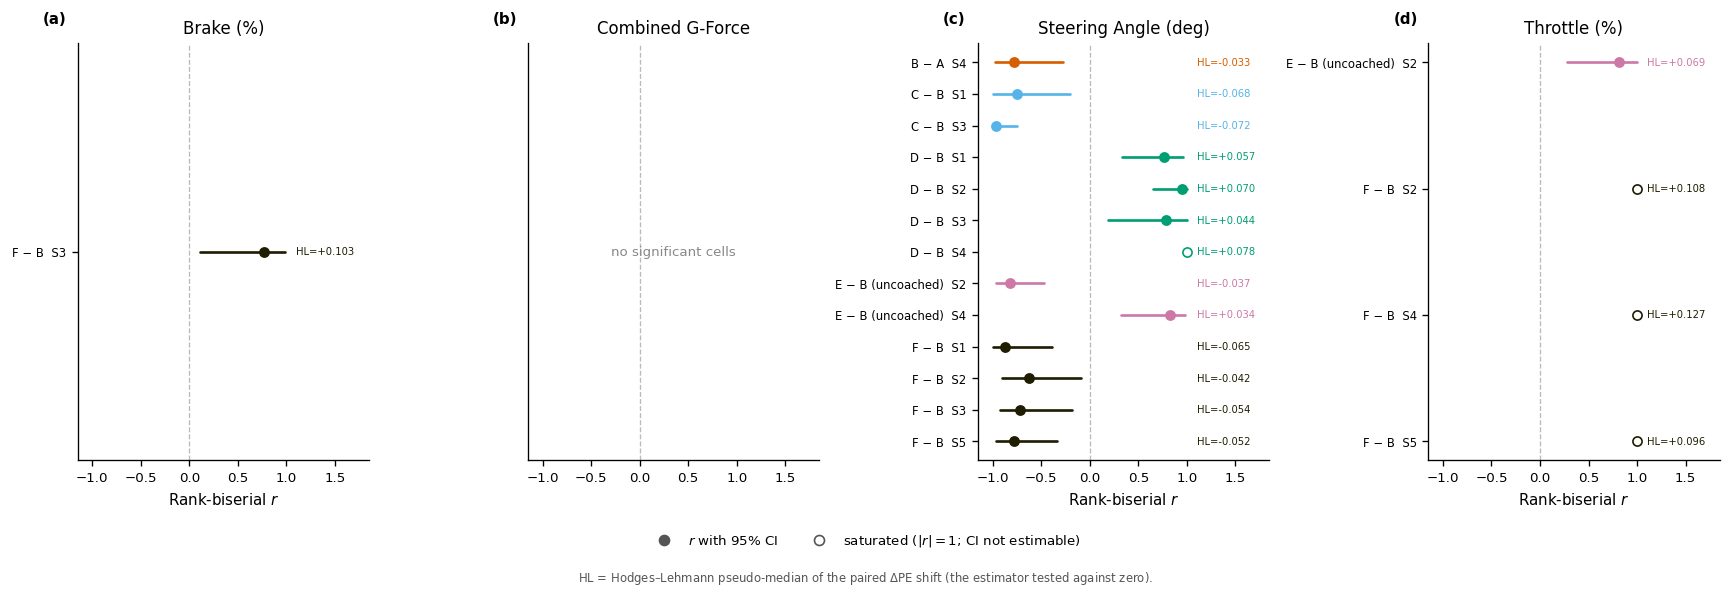

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_3_effect_size_forest_summit_point.pdf


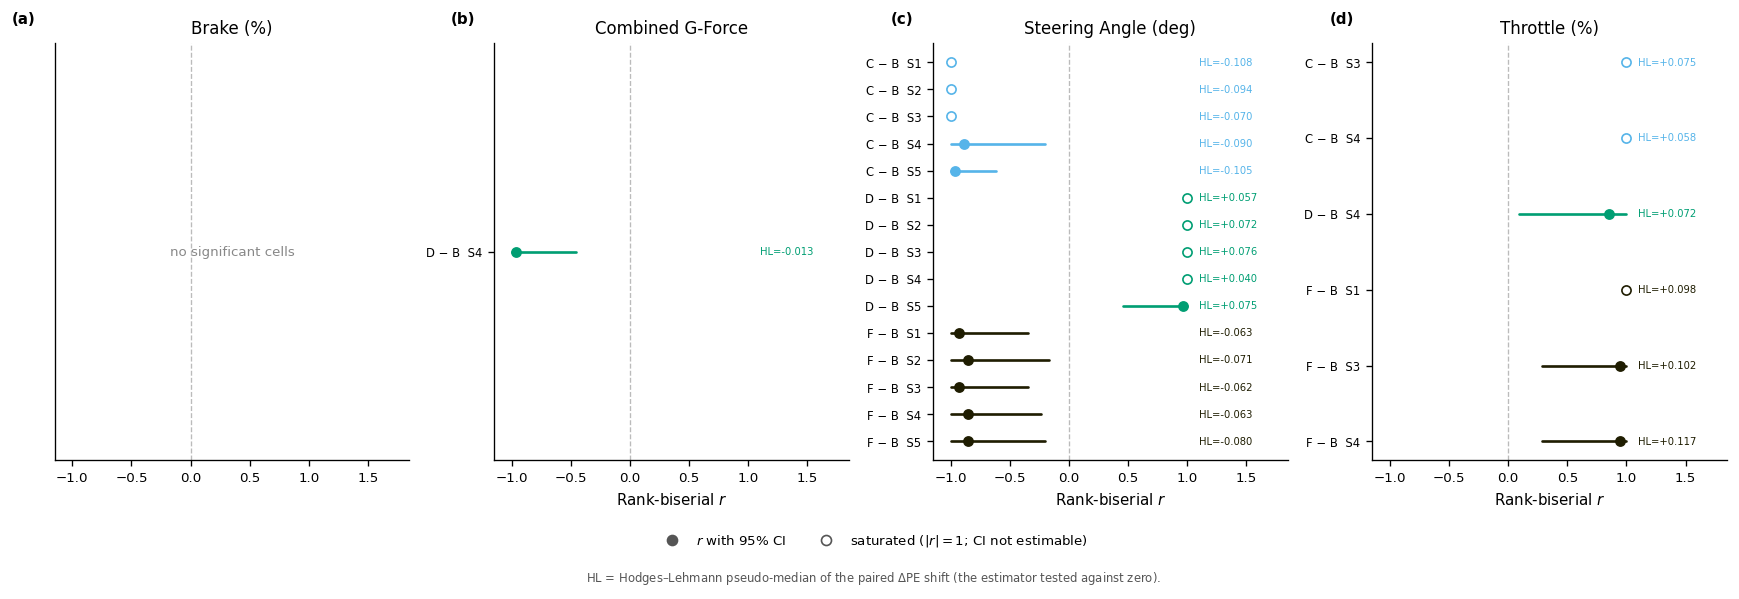

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_3_laptime_trend_charlotte_roval_2025.pdf


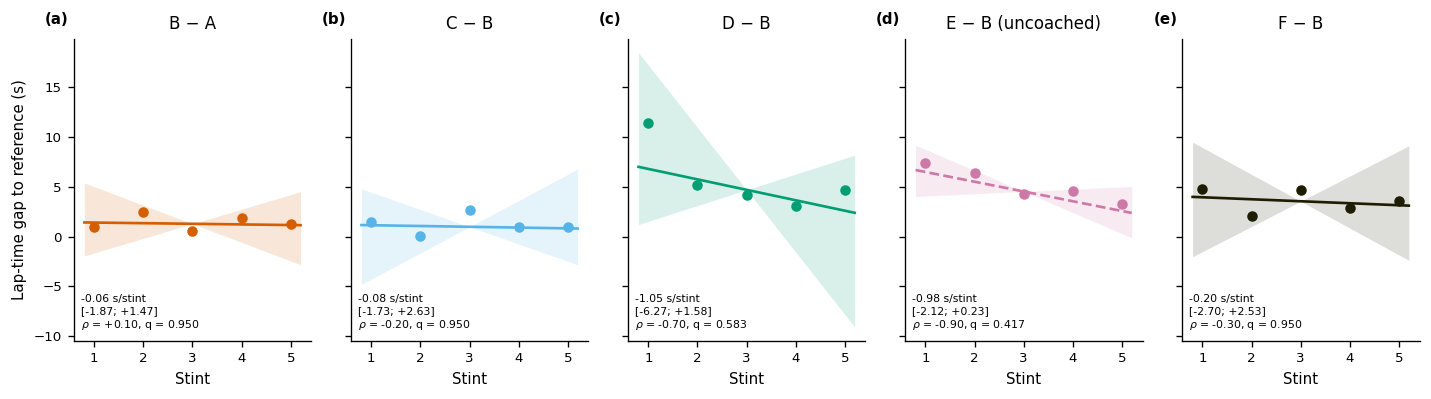

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_3_laptime_trend_summit_point.pdf


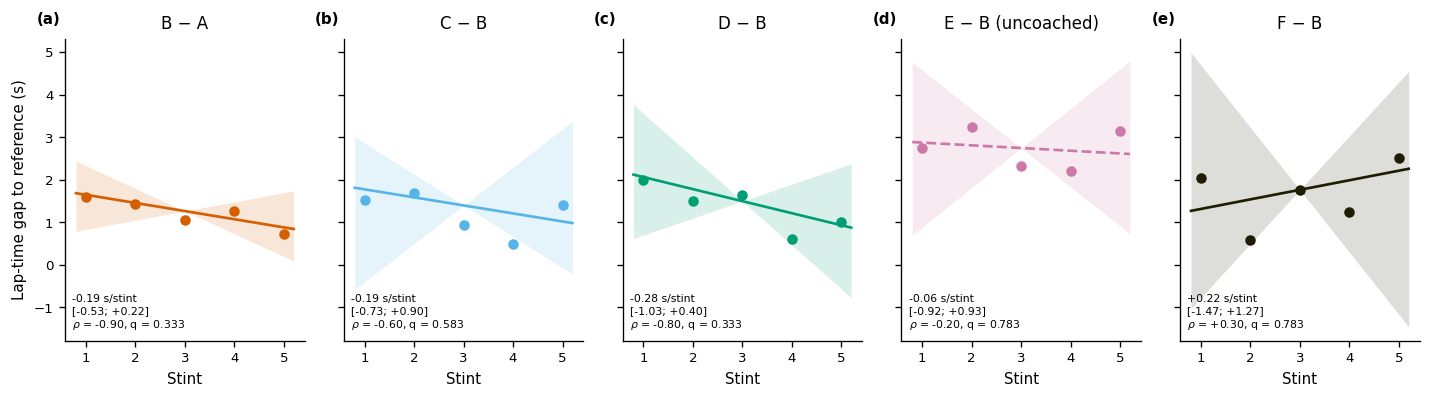

ICC agregado (todos os stints juntos), com IC bootstrap 95%:


,TrackName,Variable,N_drivers,N_observations,ICC_reported
0,Charlotte Roval 2025,Brake (%),4,360,0.068 [0.027; 0.139]
1,Charlotte Roval 2025,Steering Angle (deg),4,360,0.351 [0.290; 0.431]
2,Charlotte Roval 2025,Throttle (%),4,360,0.084 [0.029; 0.171]
3,Charlotte Roval 2025,Combined G-Force,4,360,0.016 [0.000; 0.078]
4,Summit Point - Main Circuit,Brake (%),4,200,0.051 [0.000; 0.173]
5,Summit Point - Main Circuit,Steering Angle (deg),4,200,0.504 [0.457; 0.566]
6,Summit Point - Main Circuit,Throttle (%),4,200,0.089 [0.023; 0.200]
7,Summit Point - Main Circuit,Combined G-Force,4,200,0.113 [0.044; 0.227]


Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_3_icc_summary.pdf


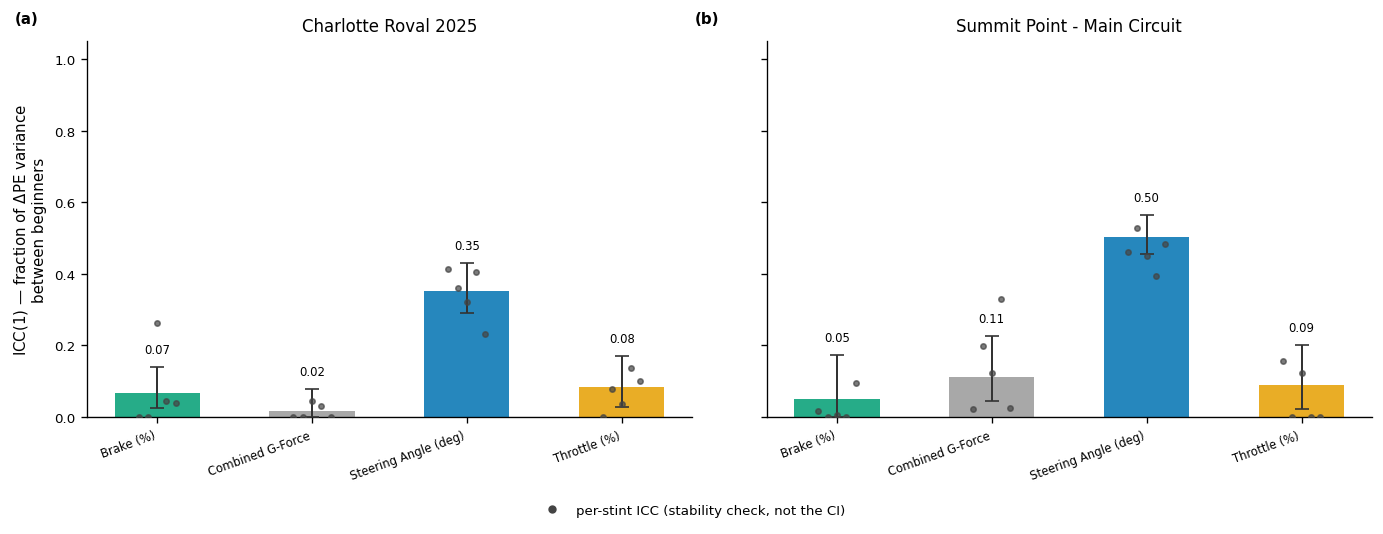

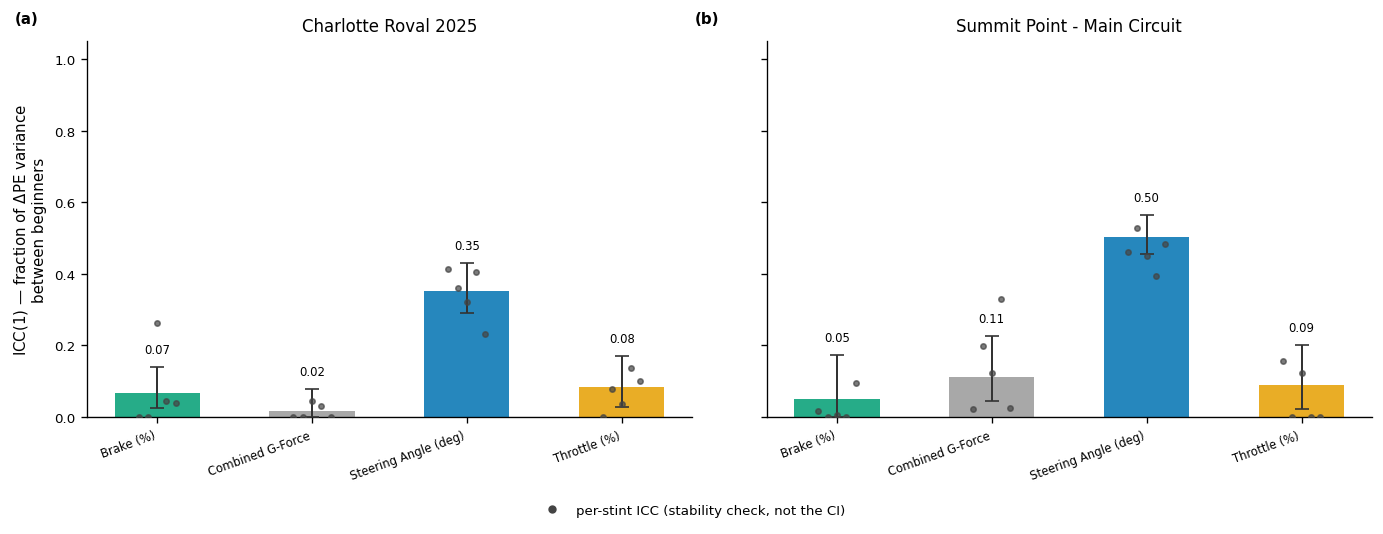

In [105]:
# =============================================================================
# CELULAS FINAIS (v2) - Resposta ao Revisor 1, item (2)
# SOMENTE FIGURAS. Nenhuma tabela LaTeX é gerada por código.
#
# Pre-requisitos: celulas 6.3 a 6.8 executadas (WILCOXON_DPE_CI, LAPTIME_TREND,
# ICC_SUMMARY existentes) e a secao de estilo de publicacao (5.1, com PUB_RC,
# COLORS, COMPARISON_DISPLAY, save_publication_figure) executada ANTES.
#
# Mudancas em relacao a v1:
# - 6.9 (floresta de efeitos): cada ponto agora traz um rotulo de texto com a
#   pseudo-mediana HL, para que o caso saturado (|r| = 1) continue legivel sem
#   precisar de tabela.
# - 6.10 (tendencia de tempo): sem mudanca de logica, mantida aqui por
#   completude.
# - 6.11 (NOVA): figura de barras com faixa min-max do ICC por canal e pista,
#   substitui a tabela de ICC.
# - 9.2 REMOVIDA. Nao ha mais exportacao de tabelas .tex.
# =============================================================================


# %% ==========================================================================
# CELULA 6.9 - Figura: tamanhos de efeito com IC (uma por pista)
# Cada ponto traz a pseudo-mediana HL como rotulo de texto.
# =============================================================================

EFFECT_VAR_ORDER = [label for _, label in VARIABLES_PE]


def plot_effect_size_forest(track_id: str):
    track_name = TRACK_META[track_id]["track_name"]
    data = WILCOXON_DPE_CI[
        (WILCOXON_DPE_CI["Track"] == track_id) & WILCOXON_DPE_CI["sig_FDR"]
    ].copy()

    if data.empty:
        print(f"{track_name}: nenhuma celula significativa; figura nao gerada.")
        return None

    fig, axes = plt.subplots(
        1, len(EFFECT_VAR_ORDER), figsize=(14.5, 4.4), sharex=True
    )
    axes = np.atleast_1d(axes)

    for ax, variable in zip(axes, EFFECT_VAR_ORDER):
        sub = (
            data[data["Variable"] == variable]
            .sort_values(["Comparison", "Stint"])
            .reset_index(drop=True)
        )
        ax.axvline(0.0, color="#BBBBBB", lw=0.8, ls="--", zorder=0)
        ax.set_title(variable)
        ax.set_xlim(-1.15, 1.85)

        if sub.empty:
            ax.set_yticks([])
            ax.text(0.5, 0.5, "no significant cells",
                    ha="center", va="center", transform=ax.transAxes,
                    fontsize=8, color="#888888")
            continue

        y_positions = np.arange(len(sub))[::-1]
        labels = [
            f"{COMPARISON_DISPLAY.get(row.Comparison, row.Comparison)}  S{row.Stint}"
            for row in sub.itertuples()
        ]

        for y, row in zip(y_positions, sub.itertuples()):
            alias = row.TestAlias
            color = COLORS.get(alias, "#0072B2")
            saturated = abs(row.r_rank_biserial) >= 0.999
            has_ci = (
                not saturated
                and np.isfinite(row.r_CI_low)
                and np.isfinite(row.r_CI_high)
            )
            if has_ci:
                ax.plot(
                    [row.r_CI_low, row.r_CI_high], [y, y],
                    color=color, lw=1.6, solid_capstyle="round", zorder=2,
                )
            ax.plot(
                row.r_rank_biserial, y,
                marker="o",
                markerfacecolor="white" if saturated else color,
                markeredgecolor=color,
                markersize=5.5,
                zorder=3,
            )
            # Rotulo com a pseudo-mediana HL (substitui a tabela para o
            # leitor que precisa do numero, especialmente nos casos saturados)
            # Sempre a direita, para nao sobrepor os rotulos do eixo Y.
            hl_text = f"HL={row.HL_DeltaPE:+.3f}"
            ax.text(
                1.10, y, hl_text,
                fontsize=6, color=color, va="center", ha="left",
            )

        ax.set_yticks(y_positions)
        ax.set_yticklabels(labels, fontsize=7)
        ax.set_xlabel("Rank-biserial $r$")

    add_panel_letters(axes)
    #fig.suptitle(
    #    f"Significant sector-wise $\\Delta$PE effects with 95% CIs — {track_name}",
    #    y=1.03,
    #)
    handles = [
        mpl.lines.Line2D([], [], marker="o", ls="", markerfacecolor="#555555",
                         markeredgecolor="#555555", label="$r$ with 95% CI"),
        mpl.lines.Line2D([], [], marker="o", ls="", markerfacecolor="white",
                         markeredgecolor="#555555",
                         label="saturated ($|r|=1$; CI not estimable)"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=2,
               bbox_to_anchor=(0.5, -0.07), frameon=False)
    fig.text(
        0.5, -0.11,
        "HL = Hodges–Lehmann pseudo-median of the paired $\\Delta$PE shift "
        "(the estimator tested against zero).",
        ha="center", fontsize=7, color="#555555",
    )
    fig.tight_layout()
    save_publication_figure(fig, f"Fig_6_3_effect_size_forest_{track_id}")
    plt.show()
    return fig


for _track in BATCH_TRACKS:
    plot_effect_size_forest(_track)


# %% ==========================================================================
# CELULA 6.10 - Figura: tendencia do gap de tempo com Theil-Sen (uma por pista)
# =============================================================================

def plot_laptime_trend(track_id: str):
    track_name = TRACK_META[track_id]["track_name"]
    trend = LAPTIME_TREND[LAPTIME_TREND["Track"] == track_id]
    perf = PERFORMANCE[PERFORMANCE["Track"] == track_id]

    comparisons = [
        c for c in COMPARISON_ORDER if c in trend["Comparison"].unique()
    ]
    if not comparisons:
        print(f"{track_name}: sem tendencias calculadas; figura nao gerada.")
        return None

    fig, axes = plt.subplots(
        1, len(comparisons), figsize=(2.4 * len(comparisons), 3.4), sharey=True
    )
    axes = np.atleast_1d(axes)

    for ax, comparison in zip(axes, comparisons):
        row = trend[trend["Comparison"] == comparison].iloc[0]
        series = (
            perf[perf["Comparison"] == comparison][["Stint", "LapGap_s"]]
            .dropna()
            .sort_values("Stint")
        )
        x = series["Stint"].to_numpy(float)
        y = series["LapGap_s"].to_numpy(float)

        alias = row.TestAlias
        color = COLORS.get(alias, "#0072B2")
        is_control = comparison in CONTROL_COMPARISONS

        ax.scatter(x, y, color=color, zorder=3, s=28)

        x_line = np.array([x.min() - 0.2, x.max() + 0.2])
        x_med, y_med = np.median(x), np.median(y)

        def line(slope):
            return y_med + slope * (x_line - x_med)

        ax.plot(
            x_line, line(row.TheilSen_slope_s_per_stint),
            color=color, lw=1.6,
            ls=CONTROL_LINESTYLE if is_control else "-",
            zorder=2,
        )
        ax.fill_between(
            x_line,
            line(row.TheilSen_CI_low),
            line(row.TheilSen_CI_high),
            color=color, alpha=0.15, lw=0, zorder=1,
        )

        title = COMPARISON_DISPLAY.get(comparison, comparison)
        ax.set_title(title)
        ax.set_xlabel("Stint")
        ax.set_xticks(sorted(set(int(v) for v in x)))

        q_val = row.p_adj_FDR
        annotation = (
            f"{row.TheilSen_slope_s_per_stint:+.2f} s/stint\n"
            f"[{row.TheilSen_CI_low:+.2f}; {row.TheilSen_CI_high:+.2f}]\n"
            f"$\\rho$ = {row.Spearman_rho:+.2f}, q = {q_val:.3f}"
        )
        ax.text(
            0.03, 0.03, annotation, transform=ax.transAxes,
            fontsize=6.5, va="bottom", ha="left",
        )

    axes[0].set_ylabel("Lap-time gap to reference (s)")
    add_panel_letters(axes)
    #fig.suptitle(
    #    f"Lap-time gap across stints with Theil–Sen trends — {track_name}",
    #    y=1.04,
    #)
    fig.tight_layout()
    save_publication_figure(fig, f"Fig_6_3_laptime_trend_{track_id}")
    plt.show()
    return fig


for _track in BATCH_TRACKS:
    plot_laptime_trend(_track)


# %% ==========================================================================
# CELULA 6.8b (NOVA) - ICC agregado entre stints, com IC bootstrap real
# =============================================================================

# O ICC_SUMMARY (celula 6.8) resume o ICC por stint com mediana e faixa
# min-max ENTRE stints. Essa faixa mede estabilidade de um stint para o
# outro -- nao e a incerteza estatistica de uma unica estimativa, que e o
# que "confidence interval" significa e o que o revisor pediu.
#
# Esta celula calcula um unico ICC por pista x canal, juntando os setores de
# TODOS os stints como observacoes repetidas de cada piloto, com IC bootstrap
# real (reamostragem de setores dentro de cada piloto). Reaproveita
# icc_one_way e icc_bootstrap_ci, ja definidas na celula 6.8.

pooled_rows = []

for (track_id, variable_col, variable), group_df in beginner_delta.groupby(
    ["Track", "VariableCol", "Variable"], observed=True
):
    icc, k_drivers, n_obs = icc_one_way(group_df, "TestAlias", "DeltaPE")
    if not np.isfinite(icc):
        continue

    icc_low, icc_high = icc_bootstrap_ci(group_df, "TestAlias", "DeltaPE")

    pooled_rows.append(
        {
            "Track": track_id,
            "TrackName": TRACK_META[track_id]["track_name"],
            "Variable": variable,
            "VariableCol": variable_col,
            "N_drivers": k_drivers,
            "N_observations": n_obs,
            "ICC_pooled": icc,
            "ICC_CI_low": icc_low,
            "ICC_CI_high": icc_high,
        }
    )

ICC_POOLED = pd.DataFrame(pooled_rows)
ICC_POOLED["ICC_reported"] = [
    format_ci(row.ICC_pooled, row.ICC_CI_low, row.ICC_CI_high)
    for row in ICC_POOLED.itertuples()
]

print("ICC agregado (todos os stints juntos), com IC bootstrap 95%:")
display(
    ICC_POOLED[
        ["TrackName", "Variable", "N_drivers", "N_observations", "ICC_reported"]
    ]
)


# %% ==========================================================================
# CELULA 6.11 (v2) - Figura: variabilidade entre pilotos (ICC), por pista
# Barra + IC bootstrap real (ICC_POOLED). Pontinhos cinza = ICC de cada
# stint individual (INTER_DRIVER_VARIABILITY), para checar estabilidade sem
# confundir com o intervalo de confianca.
# =============================================================================

def plot_icc_summary():
    track_names = [
        TRACK_META[t]["track_name"] for t in BATCH_TRACKS
        if TRACK_META[t]["track_name"] in ICC_POOLED["TrackName"].unique()
    ]
    fig, axes = plt.subplots(1, len(track_names), figsize=(5.8 * len(track_names), 4.2),
                              sharey=True)
    axes = np.atleast_1d(axes)

    channel_colors = {
        "Steering Angle (deg)": "#0072B2",
        "Throttle (%)": "#E69F00",
        "Brake (%)": "#009E73",
        "Combined G-Force": "#999999",
    }

    for ax, track_name in zip(axes, track_names):
        sub = (
            ICC_POOLED[ICC_POOLED["TrackName"] == track_name]
            .set_index("Variable")
            .reindex(EFFECT_VAR_ORDER)
        )
        stint_sub = INTER_DRIVER_VARIABILITY[
            INTER_DRIVER_VARIABILITY["TrackName"] == track_name
        ]

        x = np.arange(len(EFFECT_VAR_ORDER))
        colors = [channel_colors.get(v, "#555555") for v in EFFECT_VAR_ORDER]

        yerr_low = (sub["ICC_pooled"] - sub["ICC_CI_low"]).to_numpy(float)
        yerr_high = (sub["ICC_CI_high"] - sub["ICC_pooled"]).to_numpy(float)
        yerr_low = np.clip(yerr_low, 0, None)
        yerr_high = np.clip(yerr_high, 0, None)

        ax.bar(x, sub["ICC_pooled"], color=colors, width=0.55, zorder=2, alpha=0.85)
        ax.errorbar(
            x, sub["ICC_pooled"],
            yerr=[yerr_low, yerr_high],
            fmt="none", ecolor="#333333", elinewidth=1.2, capsize=4, zorder=3,
        )

        # Pontinhos cinza: ICC de cada stint individual (checagem de
        # estabilidade, sem se misturar com o IC).
        for xi, variable in zip(x, EFFECT_VAR_ORDER):
            per_stint = stint_sub.loc[
                stint_sub["Variable"] == variable, "ICC_between_drivers"
            ].to_numpy(float)
            if per_stint.size == 0:
                continue
            jitter = (
                np.linspace(-0.12, 0.12, per_stint.size)
                if per_stint.size > 1 else np.array([0.0])
            )
            ax.scatter(
                xi + jitter, per_stint,
                color="#444444", s=10, zorder=4, alpha=0.7,
            )

        # Rotulo do valor agregado, ACIMA do topo do IC -- nao no meio da
        # haste, onde fica ilegivel.
        for xi, row in zip(x, sub.itertuples()):
            top = row.ICC_CI_high if np.isfinite(row.ICC_CI_high) else row.ICC_pooled
            ax.text(
                xi, top + 0.03, f"{row.ICC_pooled:.2f}",
                ha="center", va="bottom", fontsize=7,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(EFFECT_VAR_ORDER, rotation=20, ha="right", fontsize=7)
        ax.set_title(track_name)
        ax.set_ylim(0, 1.05)
        ax.axhline(0, color="#BBBBBB", lw=0.8, zorder=0)

    axes[0].set_ylabel("ICC(1) — fraction of $\\Delta$PE variance\nbetween beginners")
    add_panel_letters(axes)
    #fig.suptitle(
    #    "Inter-driver variability of sector-level $\\Delta$PE\n"
    #    "(bars: pooled ICC with 95% bootstrap CI; dots: per-stint estimates)",
    #    y=1.10,
    #)
    handles = [
        mpl.lines.Line2D([], [], marker="o", ls="", color="#444444", markersize=4,
                         label="per-stint ICC (stability check, not the CI)"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=1,
               bbox_to_anchor=(0.5, -0.06), frameon=False)
    fig.tight_layout()
    save_publication_figure(fig, "Fig_6_3_icc_summary")
    plt.show()
    return fig


plot_icc_summary()

## 7. Publication style

The main visual hierarchy is fixed across figures:

- Driver A: dark neutral;
- Driver B: orange;
- coached-group median (C, D, F): blue;
- **Driver E (control): reserved reddish-purple, dashed line, diamond marker**;
- individual coached beginners: light neutral lines in group-level figures;
- $\Delta PE$ maps: one diverging scale centered at zero;
- JSD maps: one sequential scale starting at zero (JSD is non-negative).

PE panels always use the normalized range $[0,1]$. The same variable order is
retained in every figure. These choices reduce the amount of visual re-learning
required from one figure to the next, and the dashed control encoding keeps the
treatment/control contrast visible without adding a competing hue to the
coached group.


In [88]:

# 5.1 Gestalt-oriented publication style

PUB_RC = {
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}

COLORS = {
    "Driver A": "#222222",
    "Driver B": "#D55E00",
    "Coached group": "#0072B2",
    "Beginner group": "#0072B2",   # backward-compatible alias
    "Control": "#CC79A7",
    "Individuals": "#A7A7A7",
    "Driver C": "#56B4E9",
    "Driver D": "#009E73",
    "Driver E": "#CC79A7",
    "Driver F": "#1F1D01",
}

BEGINNER_ALIAS_ORDER = [
    DRIVER_TIER[driver]["alias"] for driver in BEGINNER_DRIVERS
]
COMPARISON_ORDER = ["B_vs_A", "C_vs_B", "D_vs_B", "E_vs_B", "F_vs_B"]
COMPARISON_DISPLAY = {
    "B_vs_A": "B − A",
    "C_vs_B": "C − B",
    "D_vs_B": "D − B",
    "E_vs_B": "E − B (uncoached)",
    "F_vs_B": "F − B",
}
CONTROL_LINESTYLE = "--"


def save_publication_figure(fig: mpl.figure.Figure, stem: str):
    pdf_path = FIG_DIR / f"{stem}.pdf"
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved: {pdf_path}")
    return pdf_path

def add_panel_letters(axes, start: int = 0):
    axes = np.atleast_1d(axes).ravel()
    for offset, ax in enumerate(axes):
        ax.text(
            -0.12,
            1.04,
            f"({chr(97 + start + offset)})",
            transform=ax.transAxes,
            fontweight="bold",
            va="bottom",
            ha="left",
        )


def direct_label_last_point(ax, x, y, label, color, y_offset=0.0):
    if len(x) == 0:
        return
    ax.annotate(
        label,
        xy=(x[-1], y[-1]),
        xytext=(5, y_offset),
        textcoords="offset points",
        color=color,
        va="center",
        fontsize=8,
        fontweight="bold",
    )


def common_delta_limit(values: Iterable[float], minimum: float = 0.05) -> float:
    array = np.asarray(pd.Series(values).dropna(), dtype=float)
    if array.size == 0:
        return minimum
    return max(minimum, float(np.nanquantile(np.abs(array), 0.98)))


mpl.rcParams.update(PUB_RC)


Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_2_longitudinal_PE_charlotte_roval_2025.pdf


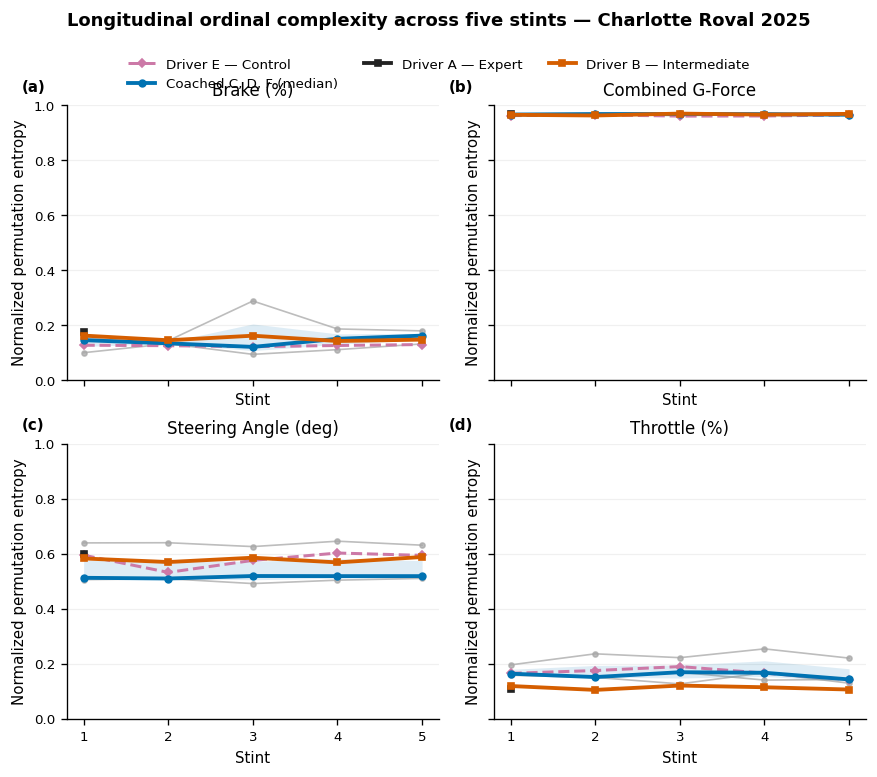

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_2_longitudinal_PE_summit_point.pdf


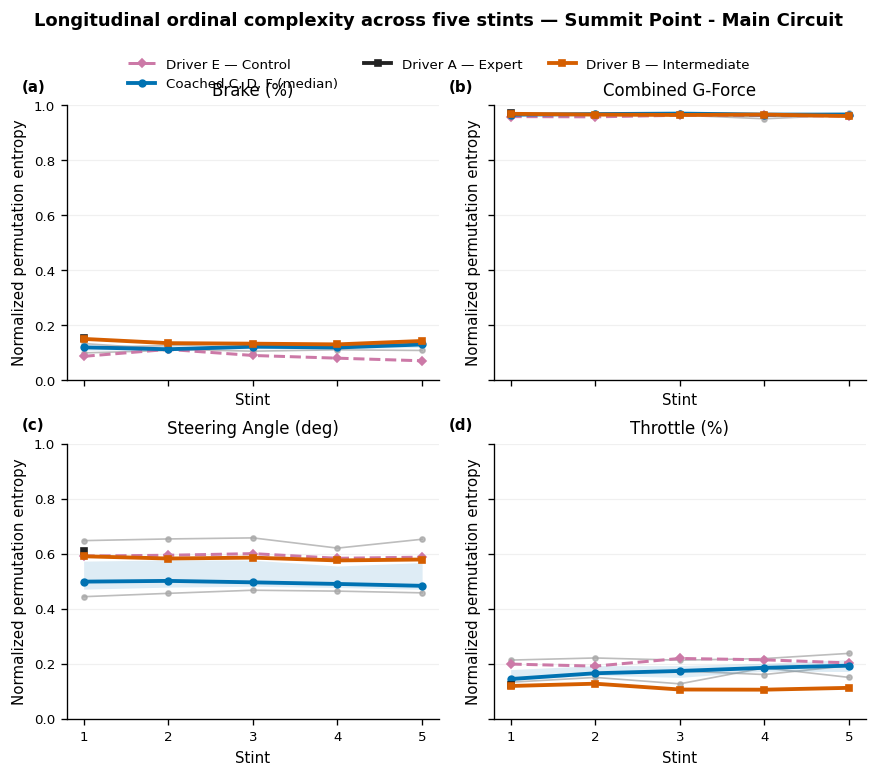

In [89]:

# Figure 1 — Section 6.2 candidate:
# Longitudinal normalized PE level across Stints 1–5

def plot_longitudinal_pe(track_id: str):
    track_name = TRACK_META[track_id]["track_name"]
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(7.2, 5.8),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    axes = axes.ravel()

    alias_a = DRIVER_TIER["Rodrigo"]["alias"]
    alias_b = DRIVER_TIER["Tomaz"]["alias"]

    for ax, variable in zip(axes, VAR_LABELS):
        # Individual coached beginners: thin, low-salience context.
        beginner_df = PE_STINT[
            (PE_STINT["Track"] == track_id)
            & (PE_STINT["Alias"].isin(COACHED_ALIASES))
            & (PE_STINT["Variable"] == variable)
        ]
        for alias, driver_df in beginner_df.groupby("Alias", observed=True):
            driver_df = driver_df.sort_values("Stint")
            ax.plot(
                driver_df["Stint"],
                driver_df["PE_mean"],
                color=COLORS["Individuals"],
                linewidth=1.0,
                marker="o",
                markersize=3,
                alpha=0.75,
                zorder=1,
            )

        # Driver E: no-feedback control, kept out of the group median.
        control_df = PE_STINT[
            (PE_STINT["Track"] == track_id)
            & (PE_STINT["Alias"] == CONTROL_ALIAS)
            & (PE_STINT["Variable"] == variable)
        ].sort_values("Stint")
        if not control_df.empty:
            ax.plot(
                control_df["Stint"],
                control_df["PE_mean"],
                color=COLORS["Control"],
                linestyle=CONTROL_LINESTYLE,
                linewidth=1.8,
                marker="D",
                markersize=3.5,
                label="Driver E — Control",
                zorder=3,
            )

        # Coached-group median + inter-driver IQR (C, D, F).
        group_df = AMATEUR_STINT[
            (AMATEUR_STINT["Track"] == track_id)
            & (AMATEUR_STINT["Variable"] == variable)
        ].sort_values("Stint")
        if not group_df.empty:
            x = group_df["Stint"].to_numpy()
            y = group_df["PE_group_median"].to_numpy()
            q25 = group_df["PE_group_q25"].to_numpy()
            q75 = group_df["PE_group_q75"].to_numpy()
            ax.fill_between(
                x,
                q25,
                q75,
                color=COLORS["Coached group"],
                alpha=0.13,
                linewidth=0,
                zorder=2,
            )
            ax.plot(
                x,
                y,
                color=COLORS["Coached group"],
                linewidth=2.3,
                marker="o",
                markersize=4,
                label="Coached C, D, F (median)",
                zorder=4,
            )

        # Expert and intermediate foreground.
        for alias, color, label in [
            (alias_a, COLORS["Driver A"], "Driver A — Expert"),
            (alias_b, COLORS["Driver B"], "Driver B — Intermediate"),
        ]:
            driver_df = PE_STINT[
                (PE_STINT["Track"] == track_id)
                & (PE_STINT["Alias"] == alias)
                & (PE_STINT["Variable"] == variable)
            ].sort_values("Stint")

            if driver_df.empty:
                continue

            ax.plot(
                driver_df["Stint"],
                driver_df["PE_mean"],
                color=color,
                linewidth=2.3,
                marker="s",
                markersize=4,
                label=label,
                zorder=5,
            )

        ax.set_title(variable)
        ax.set_xlim(0.8, 5.2)
        ax.set_ylim(0.0, 1.0)
        ax.set_xticks(STINT_NUMBERS)
        ax.set_xlabel("Stint")
        ax.set_ylabel("Normalized permutation entropy")
        ax.grid(axis="y", alpha=0.18, linewidth=0.7)

    add_panel_letters(axes)

    handles, labels = axes[0].get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    fig.legend(
        unique.values(),
        unique.keys(),
        loc="upper center",
        bbox_to_anchor=(0.5, 1.04),
        ncol=3,
        frameon=False,
    )
    fig.suptitle(
        f"Longitudinal ordinal complexity across five stints — {track_name}",
        y=1.09,
        fontweight="bold",
    )
    save_publication_figure(
        fig,
        f"Fig_6_2_longitudinal_PE_{track_id}",
    )
    plt.show()


for track_id in BATCH_TRACKS:
    plot_longitudinal_pe(track_id)


Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_4_reference_distance_charlotte_roval_2025.pdf


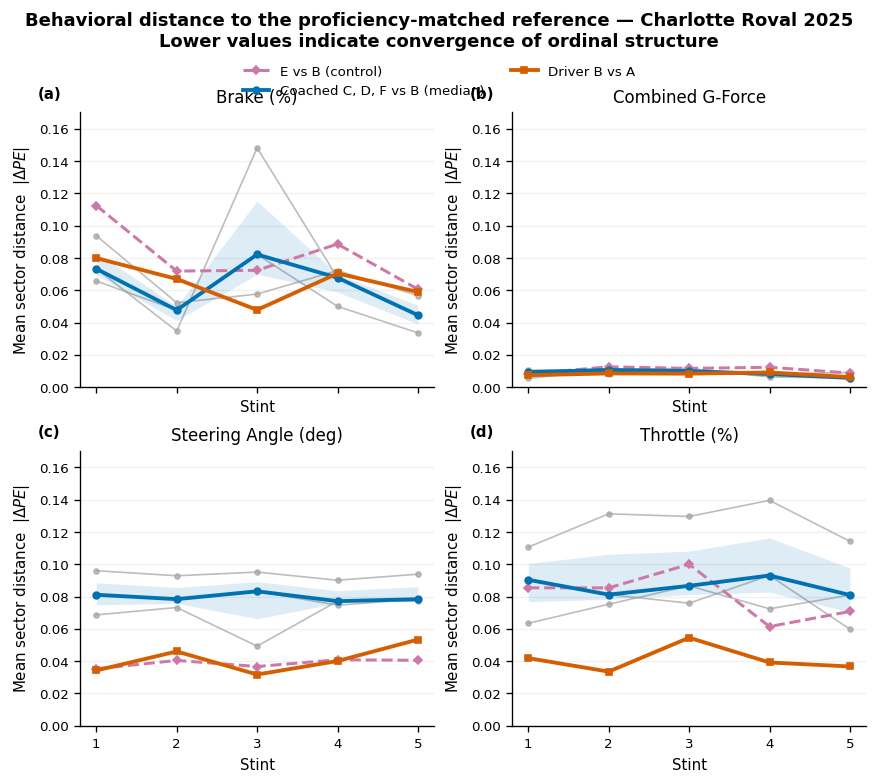

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_4_reference_distance_summit_point.pdf


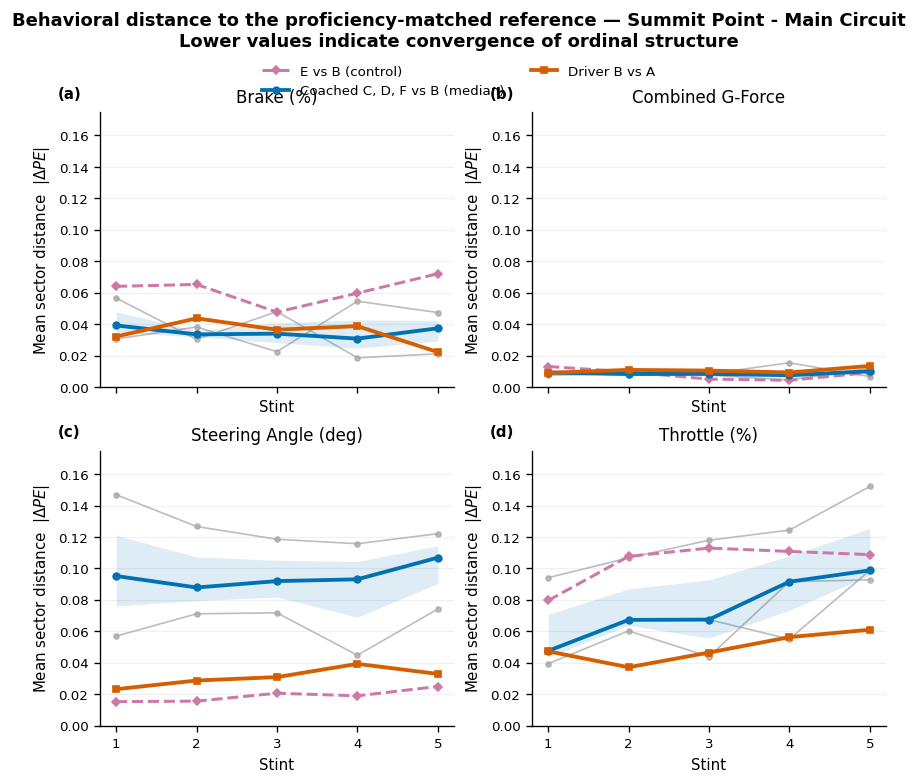

In [90]:

# Figure 2 — Section 6.4 candidate:
# Reference-distance evolution. Lower MeanAbsDeltaPE means closer ordinal structure.

def plot_reference_distance(track_id: str):
    track_name = TRACK_META[track_id]["track_name"]
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(7.2, 5.8),
        sharex=True,
        constrained_layout=True,
    )
    axes = axes.ravel()

    track_values = PAIR_SUMMARY[
        PAIR_SUMMARY["Track"] == track_id
    ]["MeanAbsDeltaPE"]
    ymax = max(0.08, float(track_values.max()) * 1.15) if len(track_values) else 0.2

    for ax, variable in zip(axes, VAR_LABELS):
        # Each coached beginner compared with Driver B.
        beginner_pairs = PAIR_SUMMARY[
            (PAIR_SUMMARY["Track"] == track_id)
            & (PAIR_SUMMARY["Variable"] == variable)
            & (PAIR_SUMMARY["Comparison"].isin(COACHED_COMPARISONS))
        ]

        for comparison, comp_df in beginner_pairs.groupby(
            "Comparison", observed=True
        ):
            comp_df = comp_df.sort_values("Stint")
            ax.plot(
                comp_df["Stint"],
                comp_df["MeanAbsDeltaPE"],
                color=COLORS["Individuals"],
                linewidth=1.0,
                marker="o",
                markersize=3,
                alpha=0.75,
                zorder=1,
            )

        # Driver E (control) compared with Driver B.
        control_pairs = PAIR_SUMMARY[
            (PAIR_SUMMARY["Track"] == track_id)
            & (PAIR_SUMMARY["Variable"] == variable)
            & (PAIR_SUMMARY["Comparison"] == "E_vs_B")
        ].sort_values("Stint")
        if not control_pairs.empty:
            ax.plot(
                control_pairs["Stint"],
                control_pairs["MeanAbsDeltaPE"],
                color=COLORS["Control"],
                linestyle=CONTROL_LINESTYLE,
                linewidth=1.8,
                marker="D",
                markersize=3.5,
                label="E vs B (control)",
                zorder=3,
            )

        # Coached median + IQR (C, D, F).
        group_df = AMATEUR_DISTANCE[
            (AMATEUR_DISTANCE["Track"] == track_id)
            & (AMATEUR_DISTANCE["Variable"] == variable)
        ].sort_values("Stint")
        if not group_df.empty:
            x = group_df["Stint"].to_numpy()
            y = group_df["MeanAbsDeltaPE_group_median"].to_numpy()
            q25 = group_df["MeanAbsDeltaPE_group_q25"].to_numpy()
            q75 = group_df["MeanAbsDeltaPE_group_q75"].to_numpy()
            ax.fill_between(
                x,
                q25,
                q75,
                color=COLORS["Coached group"],
                alpha=0.13,
                linewidth=0,
                zorder=2,
            )
            ax.plot(
                x,
                y,
                color=COLORS["Coached group"],
                linewidth=2.3,
                marker="o",
                markersize=4,
                label="Coached C, D, F vs B (median)",
                zorder=4,
            )

        # Driver B compared with Driver A.
        ba_df = PAIR_SUMMARY[
            (PAIR_SUMMARY["Track"] == track_id)
            & (PAIR_SUMMARY["Variable"] == variable)
            & (PAIR_SUMMARY["Comparison"] == "B_vs_A")
        ].sort_values("Stint")
        if not ba_df.empty:
            ax.plot(
                ba_df["Stint"],
                ba_df["MeanAbsDeltaPE"],
                color=COLORS["Driver B"],
                linewidth=2.3,
                marker="s",
                markersize=4,
                label="Driver B vs A",
                zorder=5,
            )

        ax.set_title(variable)
        ax.set_xlim(0.8, 5.2)
        ax.set_ylim(0.0, ymax)
        ax.set_xticks(STINT_NUMBERS)
        ax.set_xlabel("Stint")
        ax.set_ylabel(r"Mean sector distance  $|\Delta PE|$")
        ax.grid(axis="y", alpha=0.18, linewidth=0.7)

    add_panel_letters(axes)
    handles, labels = axes[0].get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    fig.legend(
        unique.values(),
        unique.keys(),
        loc="upper center",
        bbox_to_anchor=(0.5, 1.04),
        ncol=2,
        frameon=False,
    )
    fig.suptitle(
        f"Behavioral distance to the proficiency-matched reference — {track_name}\n"
        "Lower values indicate convergence of ordinal structure",
        y=1.10,
        fontweight="bold",
    )
    save_publication_figure(
        fig,
        f"Fig_6_4_reference_distance_{track_id}",
    )
    plt.show()


for track_id in BATCH_TRACKS:
    plot_reference_distance(track_id)


Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_4_sector_stint_DeltaPE_B_vs_A_charlotte_roval_2025.pdf


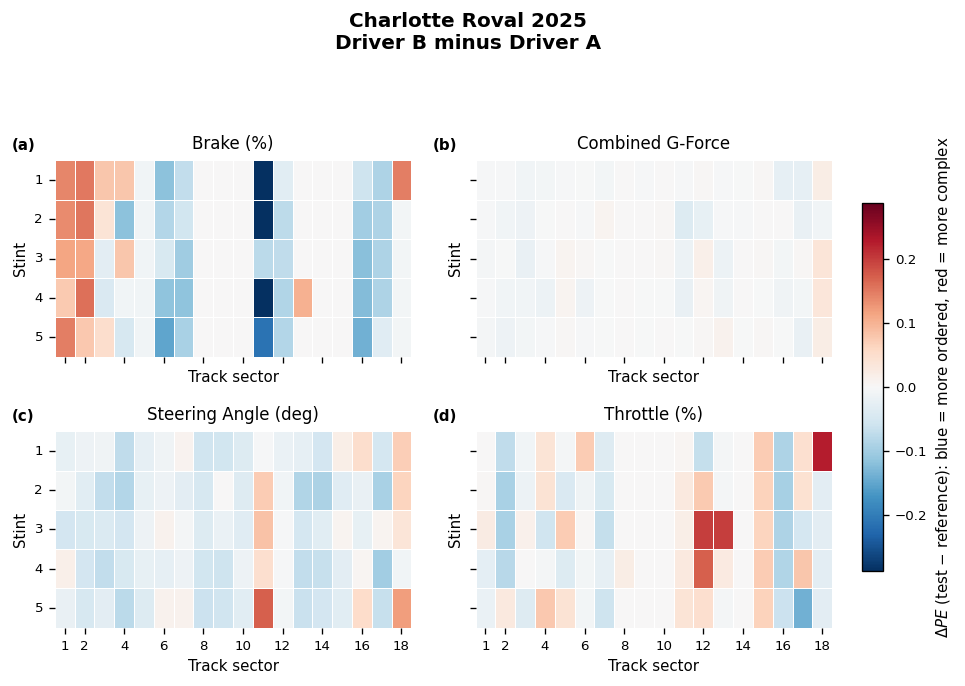

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_4_sector_stint_DeltaPE_coached_group_charlotte_roval_2025.pdf


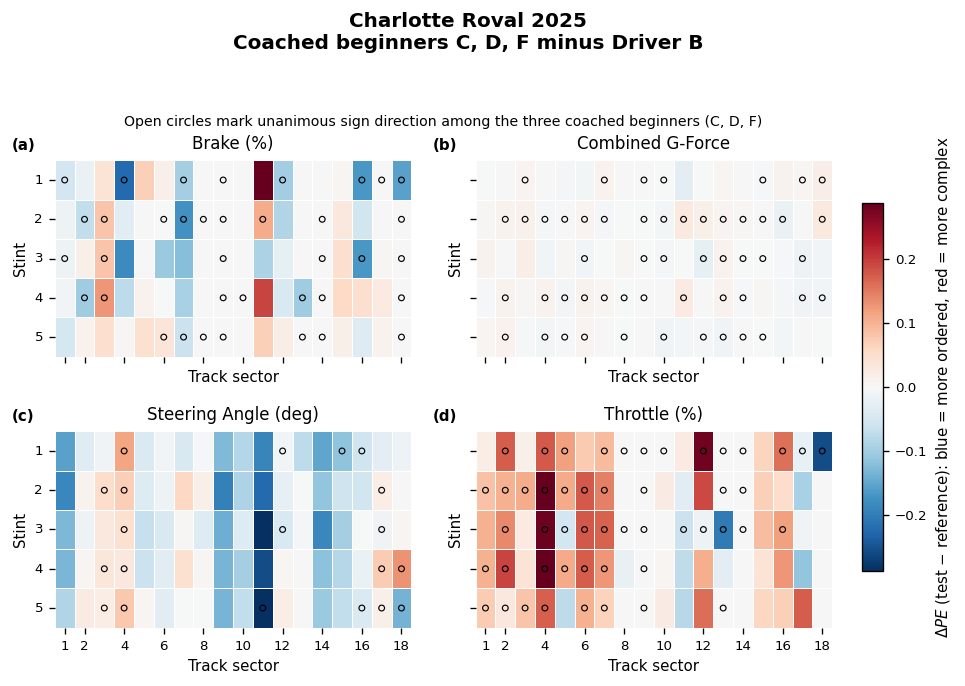

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_4_sector_stint_DeltaPE_B_vs_A_summit_point.pdf


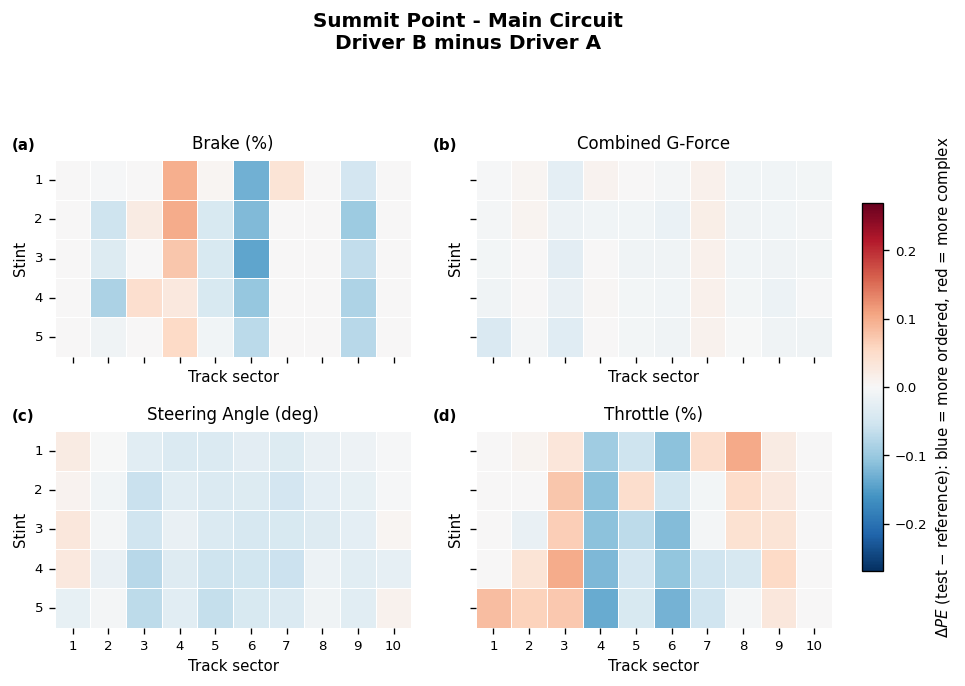

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_4_sector_stint_DeltaPE_coached_group_summit_point.pdf


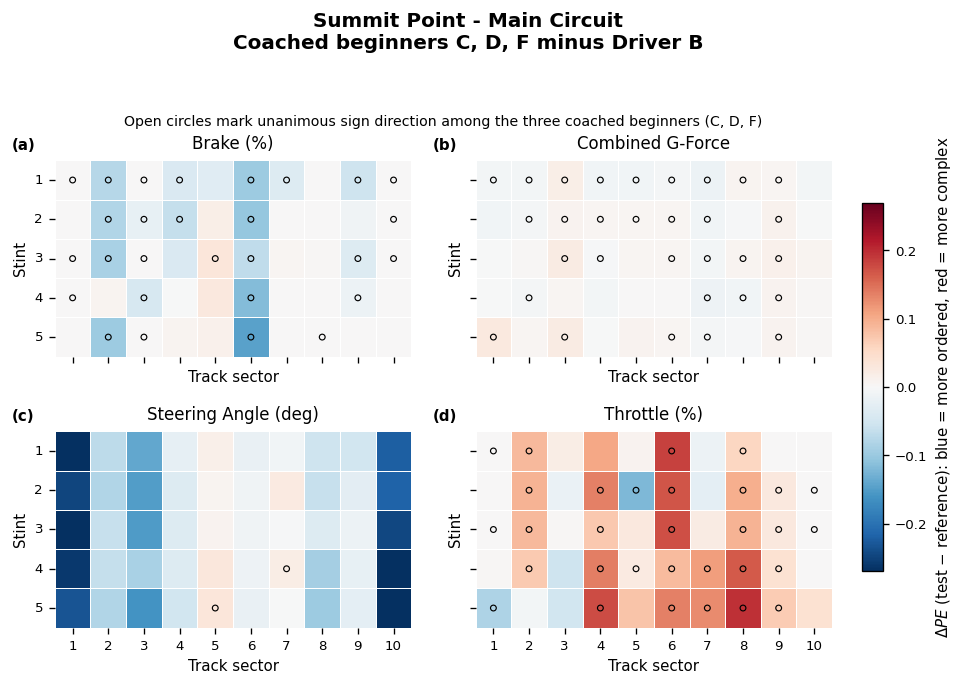

In [91]:

# Figure 3 — Section 6.4 candidate:
# Sector x stint DeltaPE maps. One shared scale supports immediate comparison.

def plot_sector_stint_delta_heatmaps(track_id: str, mode: str):
    track_name = TRACK_META[track_id]["track_name"]
    sector_indices = list(range(1, TRACK_META[track_id]["n_sectors"] + 1))

    track_pair_values = DELTA_PE[
        DELTA_PE["Track"] == track_id
    ]["DeltaPE"]
    track_group_values = AMATEUR_DELTA_SECTOR[
        AMATEUR_DELTA_SECTOR["Track"] == track_id
    ]["DeltaPE_group_median"]
    vlim = common_delta_limit(
        pd.concat([track_pair_values, track_group_values], ignore_index=True)
    )

    if mode == "B_vs_A":
        source = DELTA_PE[
            (DELTA_PE["Track"] == track_id)
            & (DELTA_PE["Comparison"] == "B_vs_A")
        ].copy()
        value_col = "DeltaPE"
        title = "Driver B minus Driver A"
        stem = f"Fig_6_4_sector_stint_DeltaPE_B_vs_A_{track_id}"
        consensus = None
        consensus_note = None
    elif mode == "coached_group":
        source = AMATEUR_DELTA_SECTOR[
            AMATEUR_DELTA_SECTOR["Track"] == track_id
        ].copy()
        value_col = "DeltaPE_group_median"
        title = "Coached beginners C, D, F minus Driver B"
        stem = f"Fig_6_4_sector_stint_DeltaPE_coached_group_{track_id}"
        consensus = source[
            ["Stint", "SectorIndex", "Variable", "SignAgreement", "N_drivers"]
        ].copy()
        consensus_note = (
            "Open circles mark unanimous sign direction among the three "
            "coached beginners (C, D, F)"
        )
    else:
        raise ValueError("mode must be 'B_vs_A' or 'coached_group'.")

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(8.2, 5.9),
        sharex=True,
        sharey=True,
        constrained_layout=False,
    )
    axes = axes.ravel()
    fig.subplots_adjust(
        left=0.08,
        right=0.87,
        bottom=0.10,
        top=0.76,
        wspace=0.18,
        hspace=0.38,
    )

    for ax, variable in zip(axes, VAR_LABELS):
        variable_df = source[source["Variable"] == variable]
        pivot = (
            variable_df.pivot_table(
                index="Stint",
                columns="SectorIndex",
                values=value_col,
                aggfunc="mean",
            )
            .reindex(index=STINT_NUMBERS, columns=sector_indices)
        )

        sns.heatmap(
            pivot,
            ax=ax,
            cmap="RdBu_r",
            vmin=-vlim,
            vmax=vlim,
            center=0,
            cbar=False,
            linewidths=0.35,
            linecolor="white",
            mask=pivot.isna(),
        )

        if consensus is not None:
            consensus_df = consensus[
                consensus["Variable"] == variable
            ].set_index(["Stint", "SectorIndex"])
            for row_index, stint_no in enumerate(STINT_NUMBERS):
                for col_index, sector_index in enumerate(sector_indices):
                    key = (stint_no, sector_index)
                    if key not in consensus_df.index:
                        continue
                    record = consensus_df.loc[key]
                    if isinstance(record, pd.DataFrame):
                        record = record.iloc[0]
                    if (
                        record["N_drivers"] >= 3
                        and record["SignAgreement"] >= 0.75
                    ):
                        ax.scatter(
                            col_index + 0.5,
                            row_index + 0.5,
                            s=12,
                            facecolor="none",
                            edgecolor="black",
                            linewidth=0.7,
                        )

        ax.set_title(variable, pad=7)
        ax.set_xlabel("Track sector")
        ax.set_ylabel("Stint")
        ax.set_yticklabels(STINT_NUMBERS, rotation=0)

        if len(sector_indices) > 12:
            visible_ticks = [
                index for index in sector_indices
                if index == 1 or index % 2 == 0
            ]
            tick_positions = [index - 0.5 for index in visible_ticks]
            ax.set_xticks(tick_positions)
            ax.set_xticklabels(visible_ticks, rotation=0)
        else:
            ax.set_xticklabels(sector_indices, rotation=0)

    add_panel_letters(axes)

    cbar_ax = fig.add_axes([0.90, 0.18, 0.022, 0.52])
    scalar_map = mpl.cm.ScalarMappable(
        norm=mpl.colors.Normalize(vmin=-vlim, vmax=vlim),
        cmap="RdBu_r",
    )
    scalar_map.set_array([])
    cbar = fig.colorbar(scalar_map, cax=cbar_ax)
    cbar.set_label(
        r"$\Delta PE$ (test − reference): blue = more ordered, red = more complex"
    )

    fig.suptitle(
        f"{track_name}\n{title}",
        y=0.97,
        fontsize=12,
        fontweight="bold",
    )
    if consensus_note:
        fig.text(
            0.475,
            0.815,
            consensus_note,
            ha="center",
            va="center",
            fontsize=8.5,
        )

    save_publication_figure(fig, stem)
    plt.show()


for track_id in BATCH_TRACKS:
    plot_sector_stint_delta_heatmaps(track_id, "B_vs_A")
    plot_sector_stint_delta_heatmaps(track_id, "coached_group")


Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_4_beginner_heterogeneity_charlotte_roval_2025.pdf


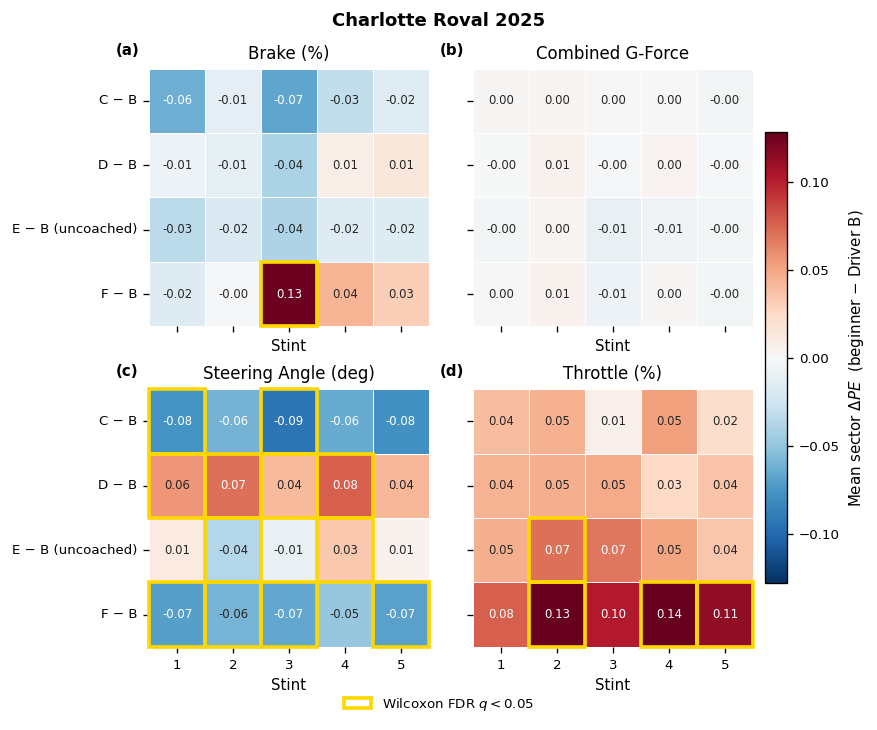

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_4_beginner_heterogeneity_summit_point.pdf


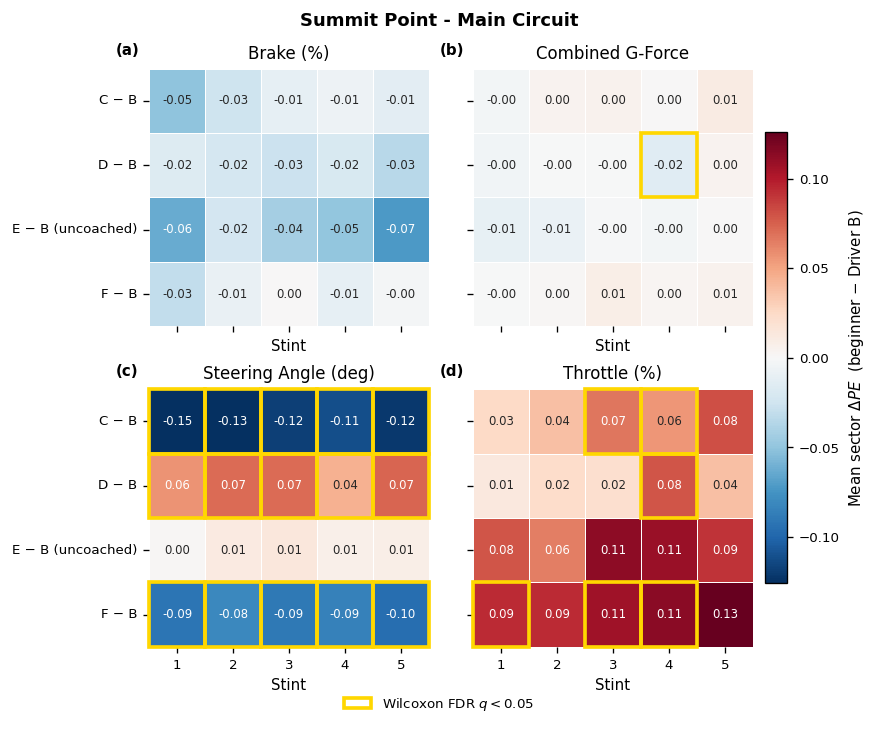

In [92]:
# Figure 4 — Beginner heterogeneity:
# Each beginner is retained as a separate comparison with Driver B.
# Cells with FDR-significant sector-wise DeltaPE (Wilcoxon, q < FDR_ALPHA)
# receive a highlighted border.

SIG_EDGE_COLOR = "gold"
SIG_EDGE_WIDTH = 2.2


def _significance_lookup(track_id: str) -> set:
    """Set of (Comparison, Stint, Variable) flagged as FDR-significant."""
    if "WILCOXON_DPE" not in globals() or WILCOXON_DPE.empty:
        return set()
    sig = WILCOXON_DPE[
        (WILCOXON_DPE["Track"] == track_id)
        & (WILCOXON_DPE["sig_FDR"].fillna(False).astype(bool))
    ]
    return {
        (row["Comparison"], int(row["Stint"]), row["Variable"])
        for _, row in sig.iterrows()
    }


def plot_beginner_heterogeneity(track_id: str):
    track_name = TRACK_META[track_id]["track_name"]
    beginner_summary = PAIR_SUMMARY[
        (PAIR_SUMMARY["Track"] == track_id)
        & (PAIR_SUMMARY["Comparison"].isin(["C_vs_B", "D_vs_B", "E_vs_B", "F_vs_B"]))
    ].copy()

    vlim = common_delta_limit(beginner_summary["MeanDeltaPE"], minimum=0.03)
    significant_cells = _significance_lookup(track_id)

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(7.2, 5.5),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    axes = axes.ravel()

    row_order = ["C_vs_B", "D_vs_B", "E_vs_B", "F_vs_B"]

    for ax, variable in zip(axes, VAR_LABELS):
        pivot = (
            beginner_summary[beginner_summary["Variable"] == variable]
            .pivot_table(
                index="Comparison",
                columns="Stint",
                values="MeanDeltaPE",
                aggfunc="mean",
            )
            .reindex(index=row_order, columns=STINT_NUMBERS)
        )
        comparison_ids = list(pivot.index)
        pivot.index = [COMPARISON_DISPLAY[index] for index in comparison_ids]

        sns.heatmap(
            pivot,
            ax=ax,
            cmap="RdBu_r",
            vmin=-vlim,
            vmax=vlim,
            center=0,
            annot=True,
            fmt=".2f",
            annot_kws={"fontsize": 7},
            linewidths=0.6,
            linecolor="white",
            cbar=False,
            mask=pivot.isna(),
        )

        # Highlight FDR-significant cells with a coloured border.
        for row_pos, comparison in enumerate(comparison_ids):
            for col_pos, stint_no in enumerate(pivot.columns):
                if pd.isna(pivot.iloc[row_pos, col_pos]):
                    continue
                if (comparison, int(stint_no), variable) not in significant_cells:
                    continue
                ax.add_patch(
                    mpl.patches.Rectangle(
                        (col_pos, row_pos),
                        1,
                        1,
                        fill=False,
                        edgecolor=SIG_EDGE_COLOR,
                        linewidth=SIG_EDGE_WIDTH,
                        zorder=5,
                        clip_on=False,
                    )
                )

        ax.set_title(variable)
        ax.set_xlabel("Stint")
        #ax.set_ylabel("Comparison")
        ax.set_xticklabels(STINT_NUMBERS, rotation=0)
        ax.set_yticklabels(pivot.index, rotation=0)

    add_panel_letters(axes)

    scalar_map = mpl.cm.ScalarMappable(
        norm=mpl.colors.Normalize(vmin=-vlim, vmax=vlim),
        cmap="RdBu_r",
    )
    scalar_map.set_array([])
    cbar = fig.colorbar(
        scalar_map,
        ax=axes.tolist(),
        shrink=0.78,
        pad=0.02,
    )
    cbar.set_label(r"Mean sector $\Delta PE$  (beginner − Driver B)")

    significance_handle = mpl.patches.Patch(
        facecolor="none",
        edgecolor=SIG_EDGE_COLOR,
        linewidth=SIG_EDGE_WIDTH,
        label=rf"Wilcoxon FDR $q < {FDR_ALPHA:g}$",
    )
    fig.legend(
        handles=[significance_handle],
        loc="lower center",
        bbox_to_anchor=(0.5, -0.04),
        frameon=False,
        fontsize=8,
    )

    fig.suptitle(
        f"{track_name}\n",
        y=1.04,
        fontweight="bold",
    )
    save_publication_figure(
        fig,
        f"Fig_6_4_beginner_heterogeneity_{track_id}",
    )
    plt.show()


for track_id in BATCH_TRACKS:
    plot_beginner_heterogeneity(track_id)

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_4_expert_reference_heterogeneity_charlotte_roval_2025.pdf


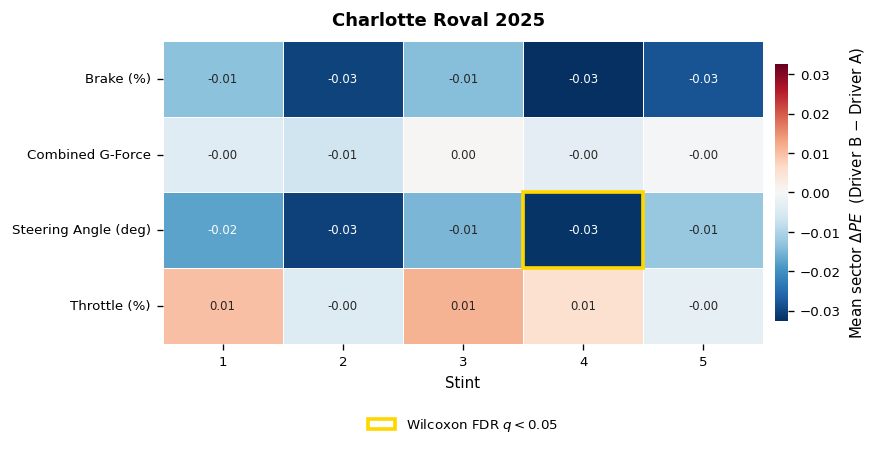

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_4_expert_reference_heterogeneity_summit_point.pdf


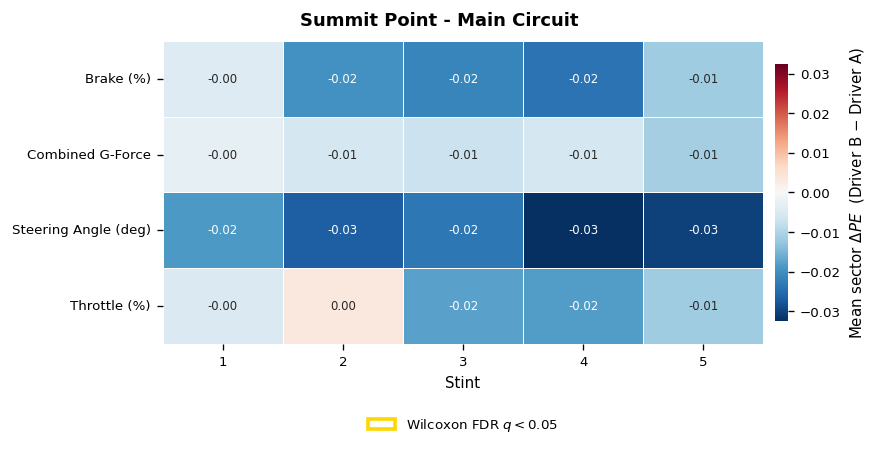

In [93]:
# Figure 4b — Driver B relative to Driver A (fixed expert reference):
# B_vs_A is a single comparison, so the beginner-heterogeneity layout collapses.
# The Y axis therefore carries the four PE channels, preserving the
# comparison x stint reading and the FDR significance borders of Figure 4.

def plot_expert_reference_heterogeneity(track_id: str):
    track_name = TRACK_META[track_id]["track_name"]
    expert_summary = PAIR_SUMMARY[
        (PAIR_SUMMARY["Track"] == track_id)
        & (PAIR_SUMMARY["Comparison"] == "B_vs_A")
    ].copy()

    if expert_summary.empty:
        print(f"No B_vs_A summary for {track_id}; figure skipped.")
        return

    vlim = common_delta_limit(expert_summary["MeanDeltaPE"], minimum=0.03)
    significant_cells = _significance_lookup(track_id)

    fig, ax = plt.subplots(figsize=(7.2, 3.4), constrained_layout=True)

    pivot = (
        expert_summary.pivot_table(
            index="Variable",
            columns="Stint",
            values="MeanDeltaPE",
            aggfunc="mean",
        )
        .reindex(index=VAR_LABELS, columns=STINT_NUMBERS)
    )

    sns.heatmap(
        pivot,
        ax=ax,
        cmap="RdBu_r",
        vmin=-vlim,
        vmax=vlim,
        center=0,
        annot=True,
        fmt=".2f",
        annot_kws={"fontsize": 7},
        linewidths=0.6,
        linecolor="white",
        cbar=True,
        cbar_kws={
            "shrink": 0.85,
            "pad": 0.02,
            "label": r"Mean sector $\Delta PE$  (Driver B − Driver A)",
        },
        mask=pivot.isna(),
    )

    # Highlight FDR-significant cells with a coloured border.
    for row_pos, variable in enumerate(pivot.index):
        for col_pos, stint_no in enumerate(pivot.columns):
            if pd.isna(pivot.iloc[row_pos, col_pos]):
                continue
            if ("B_vs_A", int(stint_no), variable) not in significant_cells:
                continue
            ax.add_patch(
                mpl.patches.Rectangle(
                    (col_pos, row_pos),
                    1,
                    1,
                    fill=False,
                    edgecolor=SIG_EDGE_COLOR,
                    linewidth=SIG_EDGE_WIDTH,
                    zorder=5,
                    clip_on=False,
                )
            )

    ax.set_xlabel("Stint")
    ax.set_ylabel("")
    ax.set_xticklabels(STINT_NUMBERS, rotation=0)
    ax.set_yticklabels(pivot.index, rotation=0)

    significance_handle = mpl.patches.Patch(
        facecolor="none",
        edgecolor=SIG_EDGE_COLOR,
        linewidth=SIG_EDGE_WIDTH,
        label=rf"Wilcoxon FDR $q < {FDR_ALPHA:g}$",
    )
    ax.legend(
        handles=[significance_handle],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.20),
        frameon=False,
        fontsize=8,
    )

    fig.suptitle(
        f"{track_name}\n",
        y=1.06,
        fontweight="bold",
    )
    save_publication_figure(
        fig,
        f"Fig_6_4_expert_reference_heterogeneity_{track_id}",
    )
    plt.show()


for track_id in BATCH_TRACKS:
    plot_expert_reference_heterogeneity(track_id)

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_4_PE_performance_trajectory_charlotte_roval_2025.pdf


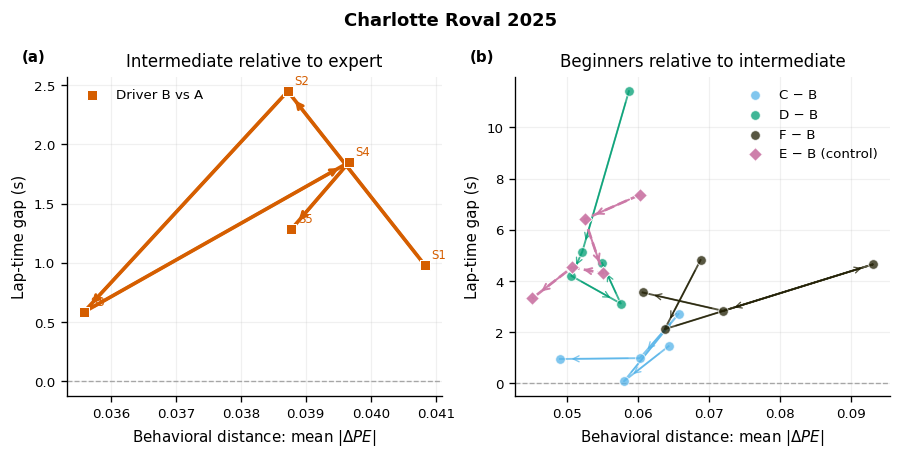

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_4_PE_performance_trajectory_summit_point.pdf


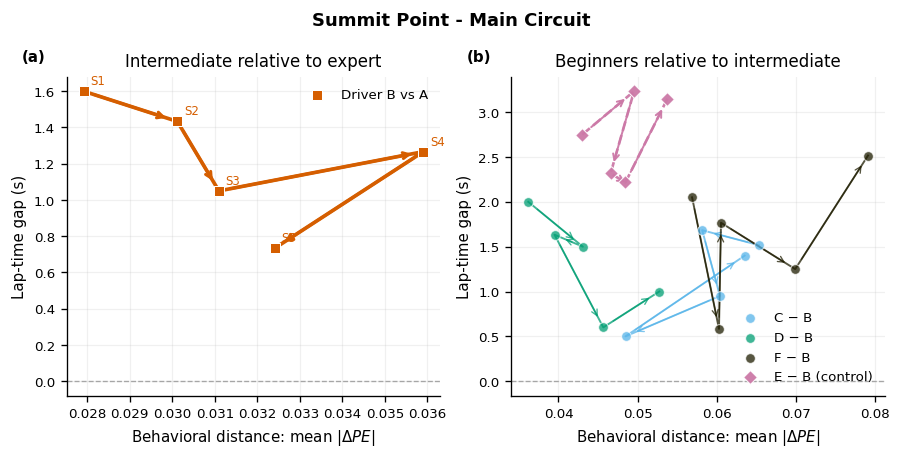

In [94]:

# Figure 5 — Joint behavioral/performance evolution:
# lower-left movement means simultaneous PE convergence and lap-gap reduction.

TRAJECTORY = PAIR_OVERALL.merge(
    PERFORMANCE[
        [
            "Track",
            "Comparison",
            "Stint",
            "LapGap_s",
        ]
    ],
    on=["Track", "Comparison", "Stint"],
    how="inner",
)

TRAJECTORY.to_csv(
    TABLE_DIR / "behavior_performance_trajectory.csv",
    index=False,
)


def draw_ordered_trajectory(
    ax,
    df,
    color,
    label,
    marker="o",
    linewidth=2.0,
    alpha=1.0,
    annotate_stints=True,
    zorder=3,
    linestyle="-",
):
    df = df.sort_values("Stint")
    if df.empty:
        return

    x = df["MeanAbsDeltaPE"].to_numpy()
    y = df["LapGap_s"].to_numpy()

    ax.plot(
        x,
        y,
        color=color,
        linewidth=linewidth,
        alpha=alpha,
        linestyle=linestyle,
        zorder=zorder,
    )
    ax.scatter(
        x,
        y,
        color=color,
        marker=marker,
        s=34,
        edgecolor="white",
        linewidth=0.6,
        alpha=alpha,
        label=label,
        zorder=zorder + 1,
    )

    for index in range(len(df) - 1):
        ax.annotate(
            "",
            xy=(x[index + 1], y[index + 1]),
            xytext=(x[index], y[index]),
            arrowprops={
                "arrowstyle": "->",
                "color": color,
                "lw": max(0.8, linewidth - 0.4),
                "alpha": alpha,
                "shrinkA": 7,
                "shrinkB": 7,
            },
            zorder=zorder,
        )

    if annotate_stints:
        for x_value, y_value, stint_no in zip(x, y, df["Stint"]):
            ax.annotate(
                f"S{int(stint_no)}",
                (x_value, y_value),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=7,
                color=color,
            )


def plot_behavior_performance_trajectory(track_id: str):
    track_name = TRACK_META[track_id]["track_name"]
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(7.4, 3.4),
        constrained_layout=True,
    )

    # Driver B vs Driver A.
    ba_df = TRAJECTORY[
        (TRAJECTORY["Track"] == track_id)
        & (TRAJECTORY["Comparison"] == "B_vs_A")
    ]
    draw_ordered_trajectory(
        axes[0],
        ba_df,
        color=COLORS["Driver B"],
        label="Driver B vs A",
        marker="s",
        linewidth=2.2,
        annotate_stints=True,
    )
    axes[0].set_title("Intermediate relative to expert")

    # Individual coached beginners vs Driver B.
    beginner_df = TRAJECTORY[
        (TRAJECTORY["Track"] == track_id)
        & (TRAJECTORY["Comparison"].isin(COACHED_COMPARISONS))
    ].copy()

    beginner_colors = {
        "C_vs_B": COLORS["Driver C"],
        "D_vs_B": COLORS["Driver D"],
        "F_vs_B": COLORS["Driver F"],
    }

    for comparison in COACHED_COMPARISONS:
        comp_df = beginner_df[beginner_df["Comparison"] == comparison]
        draw_ordered_trajectory(
            axes[1],
            comp_df,
            color=beginner_colors[comparison],
            label=COMPARISON_DISPLAY[comparison],
            linewidth=1.15,
            alpha=0.75,
            annotate_stints=False,
            zorder=2,
        )

    # Driver E (control) trajectory, plotted separately.
    control_df = TRAJECTORY[
        (TRAJECTORY["Track"] == track_id)
        & (TRAJECTORY["Comparison"] == "E_vs_B")
    ]
    draw_ordered_trajectory(
        axes[1],
        control_df,
        color=COLORS["Control"],
        label="E − B (control)",
        marker="D",
        linewidth=1.6,
        alpha=0.95,
        annotate_stints=False,
        zorder=4,
        linestyle=CONTROL_LINESTYLE,
    )

    # Median coached trajectory calculated after driver-level summaries.
    
    group_trajectory = (
        beginner_df.groupby("Stint", as_index=False)
        .agg(
            MeanAbsDeltaPE=("MeanAbsDeltaPE", "median"),
            LapGap_s=("LapGap_s", "median"),
        )
    )
    '''
    draw_ordered_trajectory(
        axes[1],
        group_trajectory,
        color=COLORS["Coached group"],
        label="C, D, F median",
        linewidth=2.6,
        alpha=1.0,
        annotate_stints=True,
        zorder=5,
    )
    '''
    axes[1].set_title("Beginners relative to intermediate")

    for ax in axes:
        ax.axhline(0, color="0.65", linewidth=0.8, linestyle="--")
        ax.set_xlabel(r"Behavioral distance: mean $|\Delta PE|$")
        ax.set_ylabel("Lap-time gap (s)")
        ax.grid(alpha=0.18, linewidth=0.7)
        ax.legend(frameon=False, loc="best")

    add_panel_letters(axes)
    fig.suptitle(
        f"{track_name}\n",
        y=1.08,
        fontweight="bold",
    )
    save_publication_figure(
        fig,
        f"Fig_6_4_PE_performance_trajectory_{track_id}",
    )
    plt.show()


for track_id in BATCH_TRACKS:
    plot_behavior_performance_trajectory(track_id)


Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_4_correlation_evolution_charlotte_roval_2025.pdf


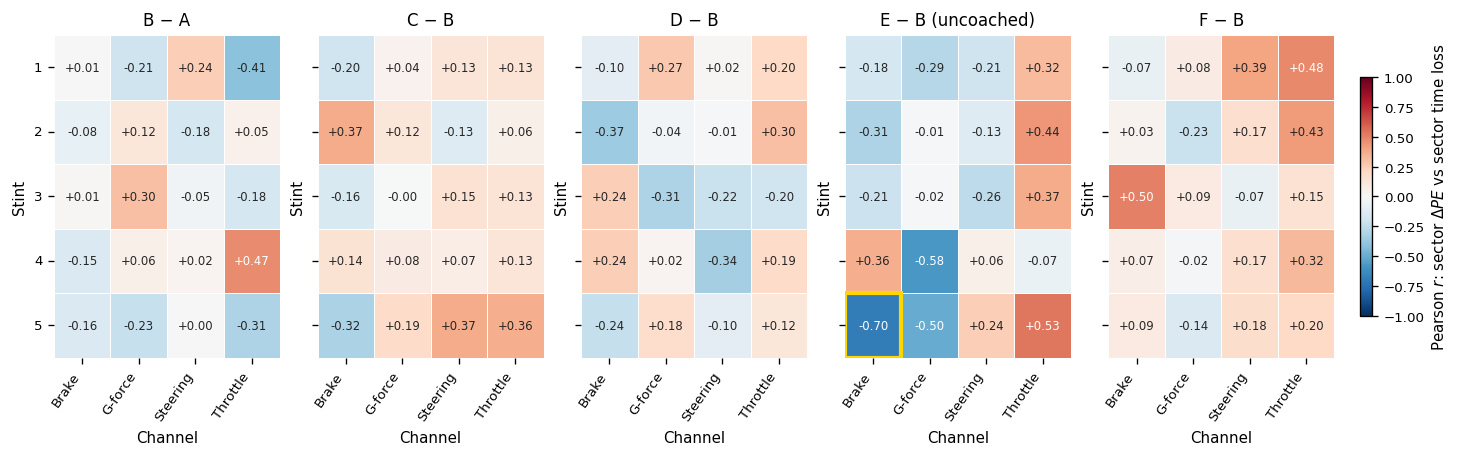

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_4_correlation_evolution_summit_point.pdf


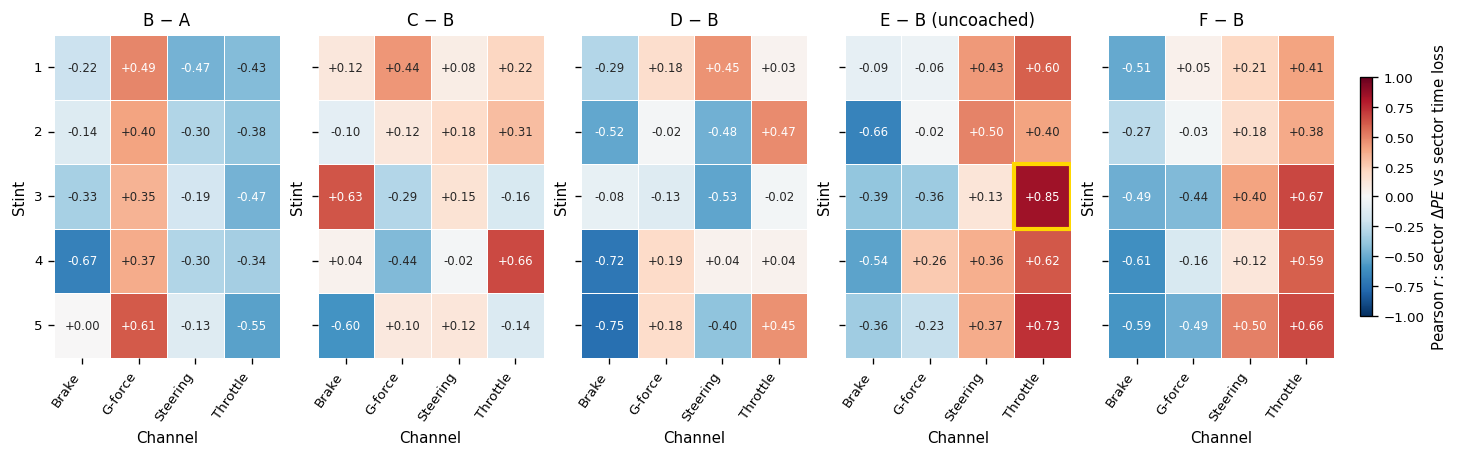

In [95]:
import matplotlib.patches as patches

# Figure 6 — Section 6.4 / supplementary candidate:
# Direction and stability of DeltaPE–time-loss associations across stints.
# This figure reports association, not prediction.

def plot_correlation_evolution(track_id: str):
    if CORR_SUMMARY.empty:
        print("Correlation summary is empty; skipping correlation figure.")
        return

    track_corr = CORR_SUMMARY[
        CORR_SUMMARY["Track"] == track_id
    ].copy()

    if track_corr.empty or not np.isfinite(track_corr["Pearson_r"]).any():
        print(
            f"No finite sector-level correlations for {track_id}; "
            "correlation figure was not generated."
        )
        return

    track_name = TRACK_META[track_id]["track_name"]
    available_comparisons = [
        comparison
        for comparison in COMPARISON_ORDER
        if comparison in track_corr["Comparison"].unique()
        and np.isfinite(
            track_corr.loc[
                track_corr["Comparison"] == comparison,
                "Pearson_r",
            ]
        ).any()
    ]
    if not available_comparisons:
        return

    fig, axes = plt.subplots(
        1,
        len(available_comparisons),
        figsize=(2.25 * len(available_comparisons) + 0.8, 3.7),
        sharey=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes)

    for ax, comparison in zip(axes, available_comparisons):
        comp_df = track_corr[
            track_corr["Comparison"] == comparison
        ].copy()

        pivot = (
            comp_df.pivot_table(
                index="Stint",
                columns="Variable",
                values="Pearson_r",
                aggfunc="mean",
            )
            .reindex(index=STINT_NUMBERS, columns=VAR_LABELS)
        )

        # Matriz de anotações numéricas (sem asterisco)
        annotations = pivot.copy().astype(object)
        for stint_no in STINT_NUMBERS:
            for variable in VAR_LABELS:
                value = pivot.loc[stint_no, variable]
                if pd.isna(value):
                    annotations.loc[stint_no, variable] = ""
                    continue
                annotations.loc[stint_no, variable] = f"{value:+.2f}"

        sns.heatmap(
            pivot,
            ax=ax,
            cmap="RdBu_r",
            vmin=-1,
            vmax=1,
            center=0,
            annot=annotations,
            fmt="",
            annot_kws={"fontsize": 7},
            linewidths=0.5,
            linecolor="white",
            cbar=False,
            mask=pivot.isna(),
        )

        # Desenhando a borda dourada nas células estatisticamente significantes
        for i, stint_no in enumerate(STINT_NUMBERS):
            for j, variable in enumerate(VAR_LABELS):
                row = comp_df[
                    (comp_df["Stint"] == stint_no)
                    & (comp_df["Variable"] == variable)
                ]
                if not row.empty and not pd.isna(pivot.loc[stint_no, variable]):
                    significant = bool(row.iloc[0]["Pearson_sig_FDR"])
                    if significant:
                        rect = patches.Rectangle((j, i), 1, 1, fill=False, edgecolor='gold', lw=2.5)
                        ax.add_patch(rect)

        ax.set_title(COMPARISON_DISPLAY[comparison])
        ax.set_xlabel("Channel")
        ax.set_ylabel("Stint")
        ax.set_yticklabels(STINT_NUMBERS, rotation=0)
        ax.set_xticklabels(
            ["Brake", "G-force", "Steering", "Throttle"],
            rotation=55,
            ha="right",
        )

    scalar_map = mpl.cm.ScalarMappable(
        norm=mpl.colors.Normalize(vmin=-1, vmax=1),
        cmap="RdBu_r",
    )
    scalar_map.set_array([])
    cbar = fig.colorbar(
        scalar_map,
        ax=axes.tolist(),
        shrink=0.74,
        pad=0.02,
    )
    cbar.set_label(r"Pearson $r$: sector $\Delta PE$ vs sector time loss")

    # Título atualizado refletindo a borda
    '''
    fig.suptitle(
        f"Evolution of PE–performance associations — {track_name}\n"
        "Gold borders indicate FDR-adjusted q < 0.05; interpret as directional evidence",
        y=1.08,
        fontweight="bold",
    )
    '''
    save_publication_figure(
        fig,
        f"Fig_6_4_correlation_evolution_{track_id}",
    )
    plt.show()


for track_id in BATCH_TRACKS:
    plot_correlation_evolution(track_id)

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_3_sector_stint_JSD_B_vs_A_charlotte_roval_2025.pdf


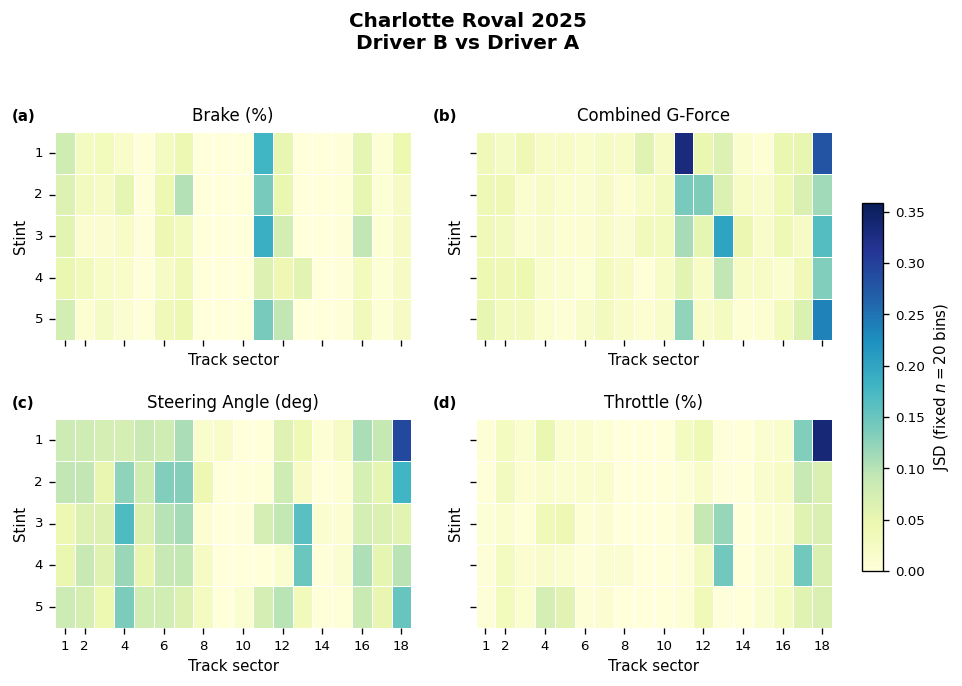

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_3_sector_stint_JSD_coached_group_charlotte_roval_2025.pdf


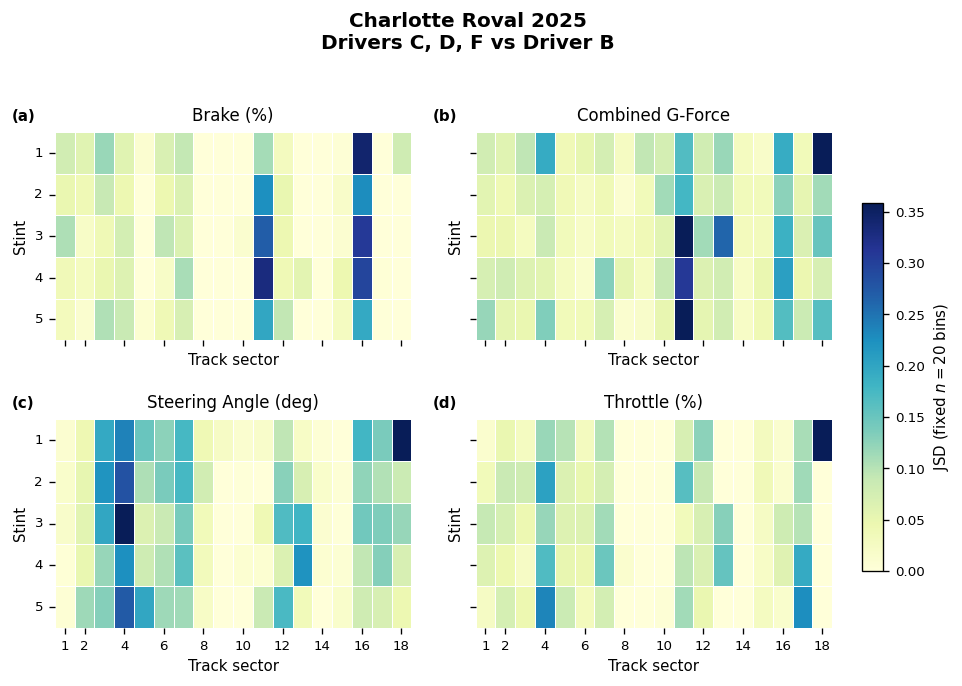

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_3_sector_stint_JSD_control_E_vs_B_charlotte_roval_2025.pdf


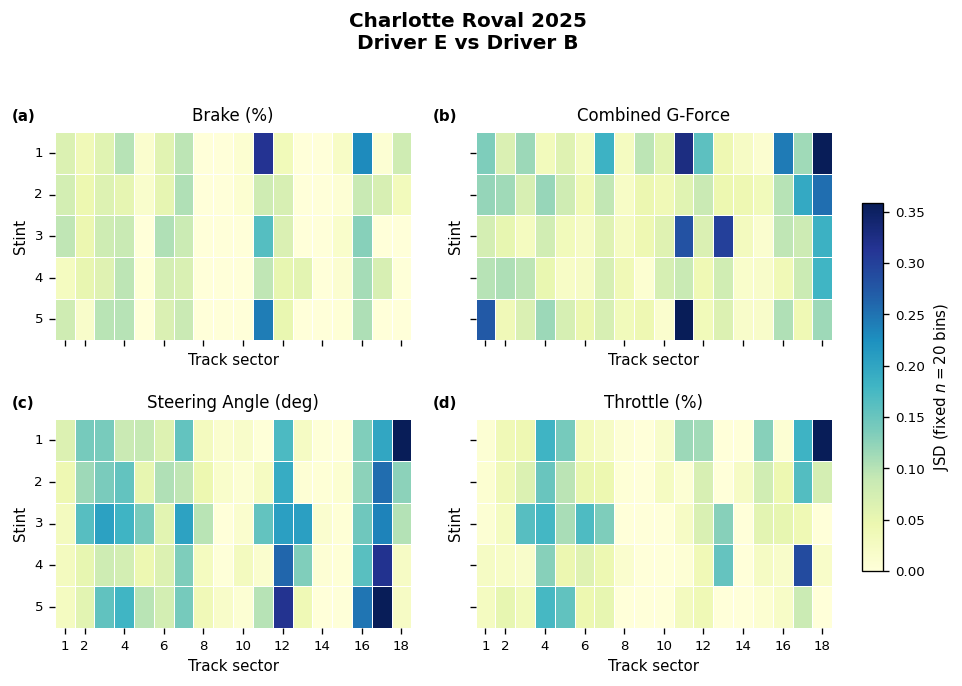

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_3_JSD_coached_vs_control_charlotte_roval_2025.pdf


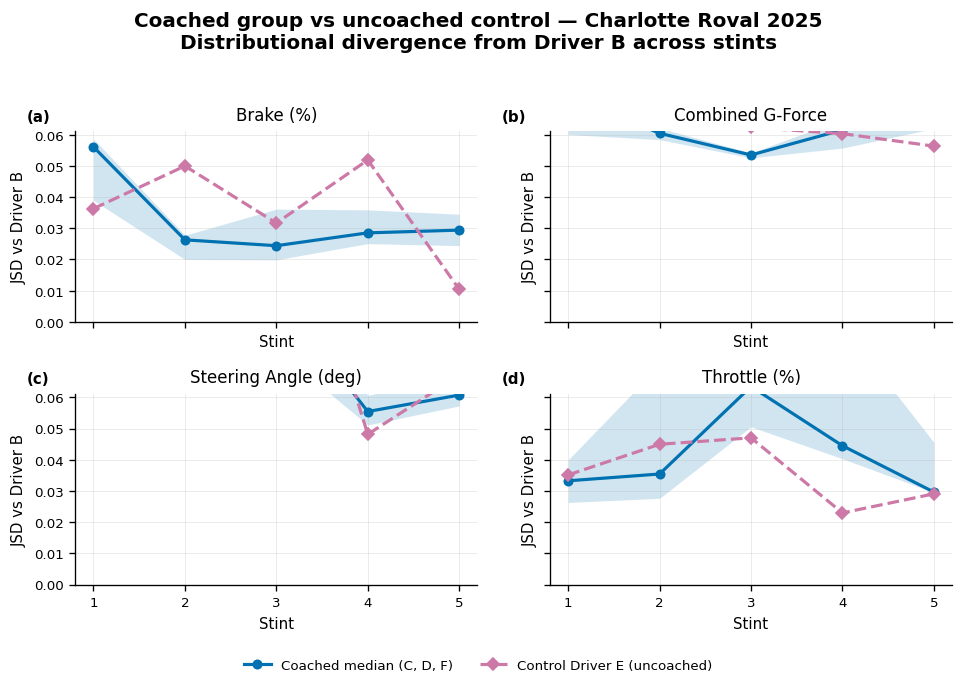

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_3_sector_stint_JSD_B_vs_A_summit_point.pdf


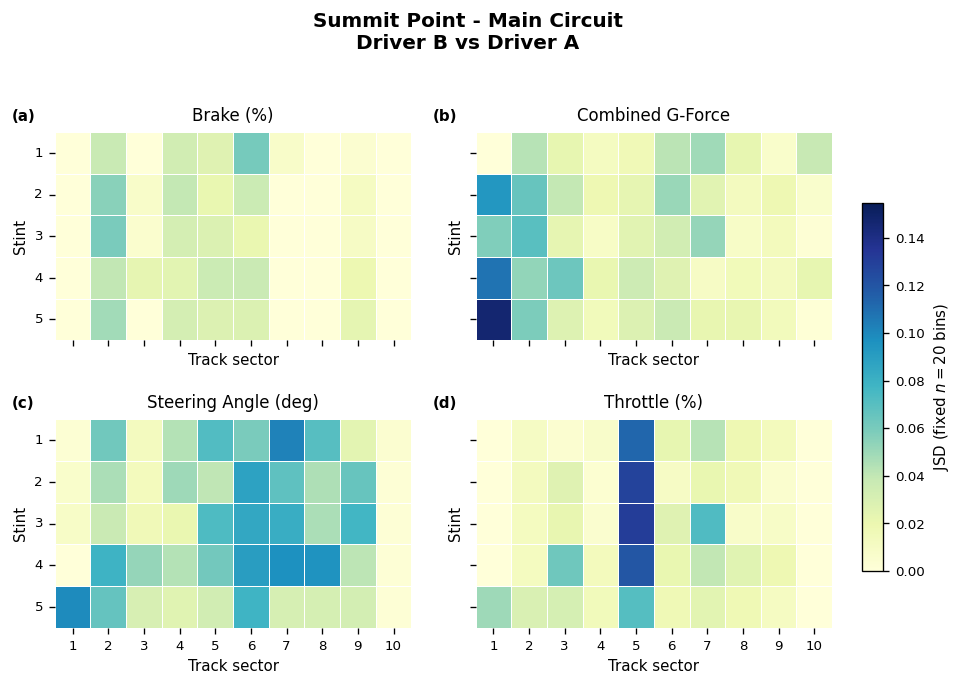

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_3_sector_stint_JSD_coached_group_summit_point.pdf


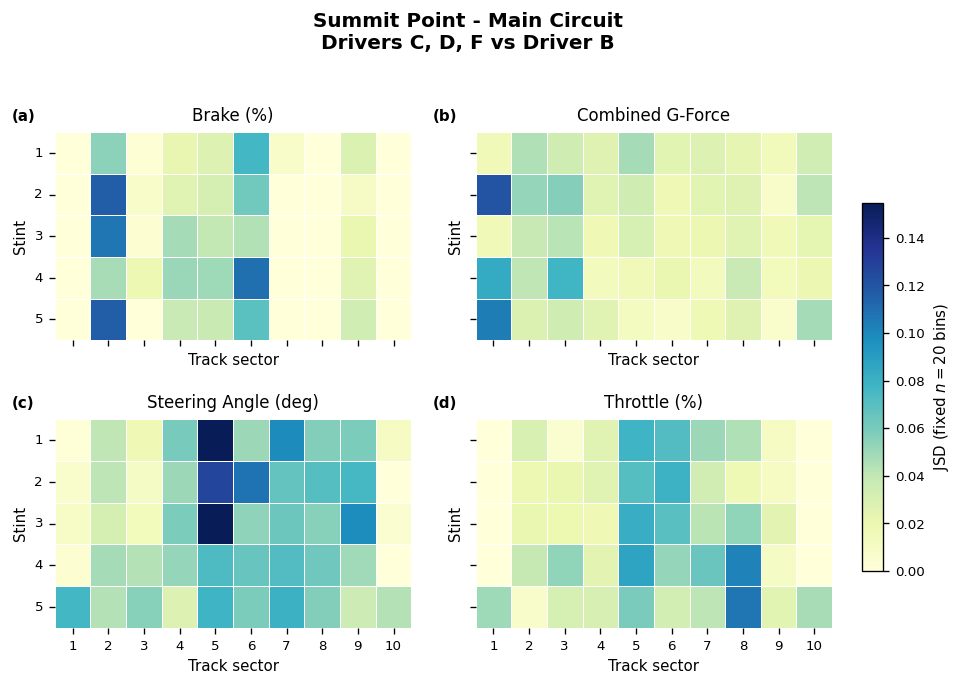

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_3_sector_stint_JSD_control_E_vs_B_summit_point.pdf


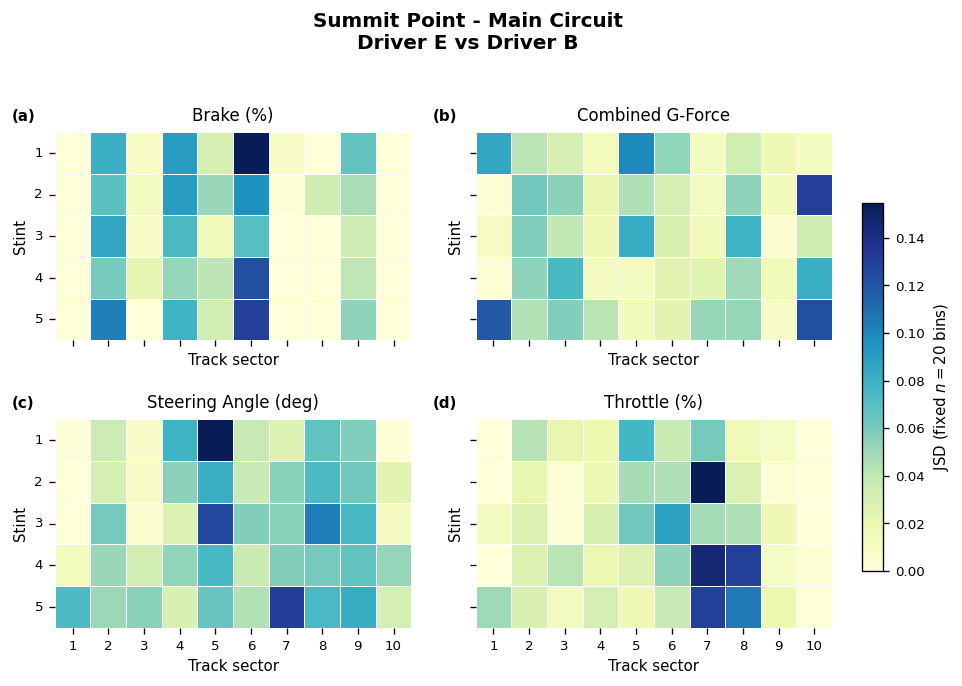

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_3_JSD_coached_vs_control_summit_point.pdf


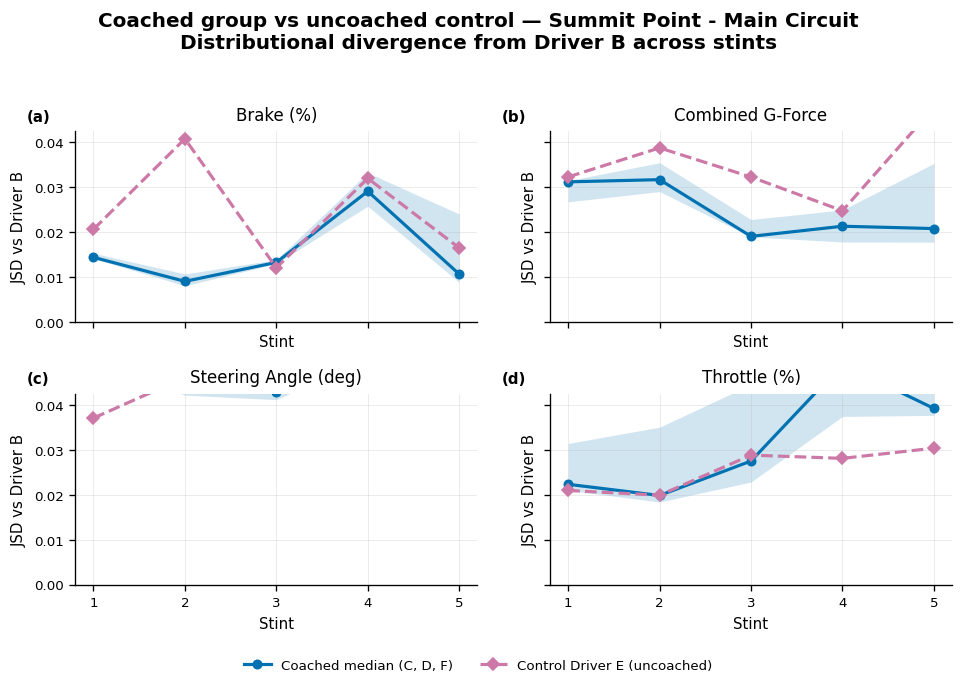

In [96]:
# Figure 7 - Section 6.3 candidate:
# Sector x stint JSD maps. JSD is non-negative, so a sequential colormap is
# used with one shared upper limit per track (good comparison).

def plot_sector_stint_jsd_heatmaps(track_id: str, mode: str):
    track_name = TRACK_META[track_id]["track_name"]
    sector_indices = list(range(1, TRACK_META[track_id]["n_sectors"] + 1))

    track_values = pd.concat(
        [
            VALID_JSD[VALID_JSD["Track"] == track_id]["JSD"],
            JSD_COACHED_SECTOR[
                JSD_COACHED_SECTOR["Track"] == track_id
            ]["JSD_group_median"],
        ],
        ignore_index=True,
    ).dropna()
    vmax = max(0.05, float(np.nanquantile(track_values, 0.98))) if len(track_values) else 0.3

    if mode == "B_vs_A":
        source = VALID_JSD[
            (VALID_JSD["Track"] == track_id)
            & (VALID_JSD["Comparison"] == "B_vs_A")
        ].copy()
        value_col = "JSD"
        title = "Driver B vs Driver A"
        stem = f"Fig_6_3_sector_stint_JSD_B_vs_A_{track_id}"
    elif mode == "coached_group":
        source = JSD_COACHED_SECTOR[
            JSD_COACHED_SECTOR["Track"] == track_id
        ].copy()
        value_col = "JSD_group_median"
        title = "Drivers C, D, F vs Driver B"
        stem = f"Fig_6_3_sector_stint_JSD_coached_group_{track_id}"
    elif mode == "control":
        source = VALID_JSD[
            (VALID_JSD["Track"] == track_id)
            & (VALID_JSD["Comparison"] == "E_vs_B")
        ].copy()
        value_col = "JSD"
        title = (
            f"{CONTROL_ALIAS} vs Driver B"
        )
        stem = f"Fig_6_3_sector_stint_JSD_control_E_vs_B_{track_id}"
    else:
        raise ValueError("mode must be 'B_vs_A', 'coached_group' or 'control'.")

    if source.empty:
        print(f"No JSD data for {track_id} / {mode}; figure skipped.")
        return

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(8.2, 5.9),
        sharex=True,
        sharey=True,
        constrained_layout=False,
    )
    axes = axes.ravel()
    fig.subplots_adjust(
        left=0.08,
        right=0.87,
        bottom=0.10,
        top=0.80,
        wspace=0.18,
        hspace=0.38,
    )

    for ax, variable in zip(axes, VAR_LABELS):
        variable_df = source[source["Variable"] == variable]
        pivot = (
            variable_df.pivot_table(
                index="Stint",
                columns="SectorIndex",
                values=value_col,
                aggfunc="mean",
            )
            .reindex(index=STINT_NUMBERS, columns=sector_indices)
        )

        sns.heatmap(
            pivot,
            ax=ax,
            cmap="YlGnBu",
            vmin=0,
            vmax=vmax,
            cbar=False,
            linewidths=0.35,
            linecolor="white",
            mask=pivot.isna(),
        )

        ax.set_title(variable, pad=7)
        ax.set_xlabel("Track sector")
        ax.set_ylabel("Stint")
        ax.set_yticklabels(STINT_NUMBERS, rotation=0)

        if len(sector_indices) > 12:
            visible_ticks = [
                index for index in sector_indices
                if index == 1 or index % 2 == 0
            ]
            tick_positions = [index - 0.5 for index in visible_ticks]
            ax.set_xticks(tick_positions)
            ax.set_xticklabels(visible_ticks, rotation=0)
        else:
            ax.set_xticklabels(sector_indices, rotation=0)

    add_panel_letters(axes)

    cbar_ax = fig.add_axes([0.90, 0.18, 0.022, 0.52])
    scalar_map = mpl.cm.ScalarMappable(
        norm=mpl.colors.Normalize(vmin=0, vmax=vmax),
        cmap="YlGnBu",
    )
    scalar_map.set_array([])
    cbar = fig.colorbar(scalar_map, cax=cbar_ax)
    cbar.set_label(
        rf"JSD (fixed $n={N_BINS_FIXED}$ bins)"
    )

    fig.suptitle(
        f"{track_name}\n{title}",
        y=0.97,
        fontsize=12,
        fontweight="bold",
    )
    save_publication_figure(fig, stem)
    plt.show()


# Figure 7b - Section 6.3 candidate:
# Coached group vs uncoached control, side by side. Same y-axis per panel, so the
# two curves are directly comparable: if the feedback layer does anything, the
# coached curve should decay across stints while the control curve should not.

def _coached_jsd_with_spread(track_id: str) -> pd.DataFrame:
    """Median + IQR of JSD per stint for the coached group.

    JSD_COACHED only carries the group median, so the spread is recomputed here
    from the sector-level table. The IQR is taken across the coached drivers'
    per-stint medians (n = 3), not across sectors.
    """
    if {"JSD_q25", "JSD_q75"}.issubset(JSD_COACHED.columns):
        return JSD_COACHED[JSD_COACHED["Track"] == track_id].copy()

    coached = VALID_JSD[
        (VALID_JSD["Track"] == track_id)
        & (VALID_JSD["Comparison"].isin(COACHED_COMPARISONS))
    ]
    if coached.empty:
        return pd.DataFrame(
            columns=["Stint", "Variable", "JSD_group_median", "JSD_q25", "JSD_q75", "n_drivers"]
        )

    per_driver = (
        coached.groupby(["Stint", "Variable", "Comparison"], as_index=False)["JSD"]
        .median()
    )
    spread = (
        per_driver.groupby(["Stint", "Variable"])["JSD"]
        .agg(
            JSD_group_median="median",
            JSD_q25=lambda s: s.quantile(0.25),
            JSD_q75=lambda s: s.quantile(0.75),
            n_drivers="size",
        )
        .reset_index()
    )
    return spread


def plot_coached_vs_control_jsd(track_id: str):
    track_name = TRACK_META[track_id]["track_name"]

    coached = _coached_jsd_with_spread(track_id)
    control = VALID_JSD[
        (VALID_JSD["Track"] == track_id)
        & (VALID_JSD["Comparison"] == "E_vs_B")
    ].copy()

    if coached.empty and control.empty:
        print(f"No JSD data for {track_id}; control figure skipped.")
        return

    control_by_stint = (
        control.groupby(["Stint", "Variable"], as_index=False)["JSD"]
        .median()
        .rename(columns={"JSD": "JSD_control"})
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(8.4, 5.9),
        sharex=True,
        sharey=True,
        constrained_layout=False,
    )
    axes = axes.ravel()
    fig.subplots_adjust(
        left=0.10,
        right=0.97,
        bottom=0.16,
        top=0.80,
        wspace=0.18,
        hspace=0.38,
    )

    for ax, variable in zip(axes, VAR_LABELS):
        coached_var = coached[coached["Variable"] == variable].sort_values("Stint")
        control_var = control_by_stint[
            control_by_stint["Variable"] == variable
        ].sort_values("Stint")

        if not coached_var.empty:
            if {"JSD_q25", "JSD_q75"}.issubset(coached_var.columns):
                ax.fill_between(
                    coached_var["Stint"],
                    coached_var["JSD_q25"],
                    coached_var["JSD_q75"],
                    color=COLORS["Coached group"],
                    alpha=0.18,
                    linewidth=0,
                    zorder=1,
                )
            ax.plot(
                coached_var["Stint"],
                coached_var["JSD_group_median"],
                color=COLORS["Coached group"],
                marker="o",
                markersize=5,
                linewidth=1.9,
                label="Coached median (C, D, F)",
                zorder=3,
            )

        if not control_var.empty:
            ax.plot(
                control_var["Stint"],
                control_var["JSD_control"],
                color=COLORS["Control"],
                linestyle=CONTROL_LINESTYLE,
                marker="D",
                markersize=5,
                linewidth=1.9,
                label=f"Control {CONTROL_ALIAS} (uncoached)",
                zorder=4,
            )

        ax.set_title(variable, pad=7)
        ax.set_xlabel("Stint")
        ax.set_ylabel(rf"JSD vs Driver B")
        ax.set_xticks(STINT_NUMBERS)
        ax.set_ylim(bottom=0)
        ax.grid(True, alpha=0.25, linewidth=0.6)

    add_panel_letters(axes)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="lower center",
            ncol=2,
            frameon=False,
            bbox_to_anchor=(0.5, 0.02),
        )

    fig.suptitle(
        f"Coached group vs uncoached control \u2014 {track_name}\n"
        f"Distributional divergence from Driver B across stints",
        y=0.97,
        fontsize=12,
        fontweight="bold",
    )
    save_publication_figure(fig, f"Fig_6_3_JSD_coached_vs_control_{track_id}")
    plt.show()


for track_id in BATCH_TRACKS:
    plot_sector_stint_jsd_heatmaps(track_id, "B_vs_A")
    plot_sector_stint_jsd_heatmaps(track_id, "coached_group")
    plot_sector_stint_jsd_heatmaps(track_id, "control")
    plot_coached_vs_control_jsd(track_id)

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_3_longitudinal_JSD_charlotte_roval_2025.pdf


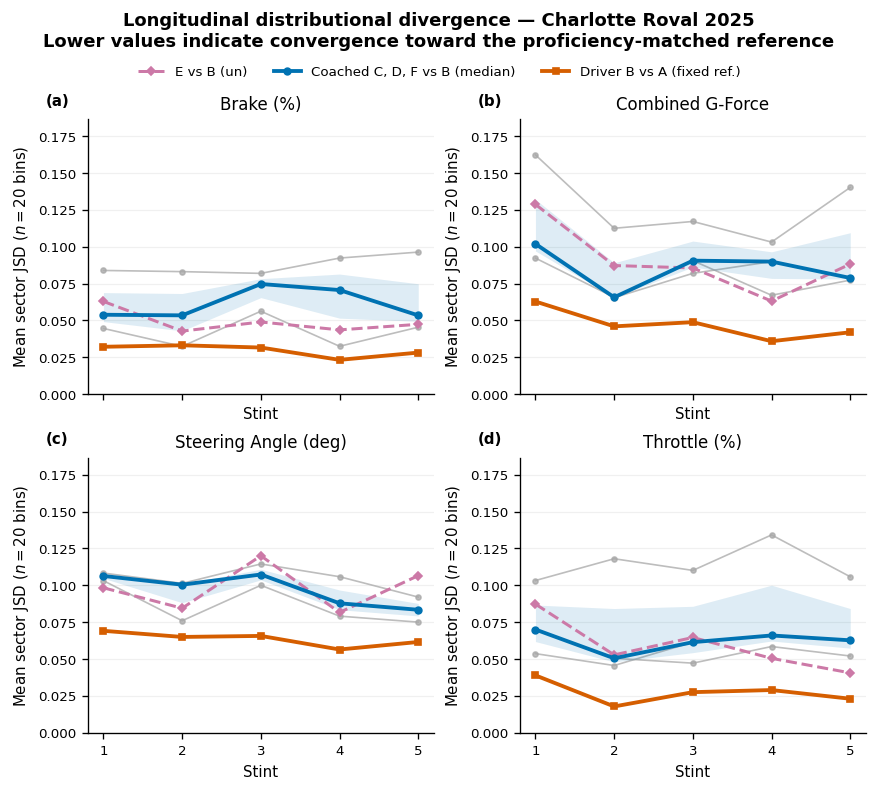

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_3_longitudinal_JSD_summit_point.pdf


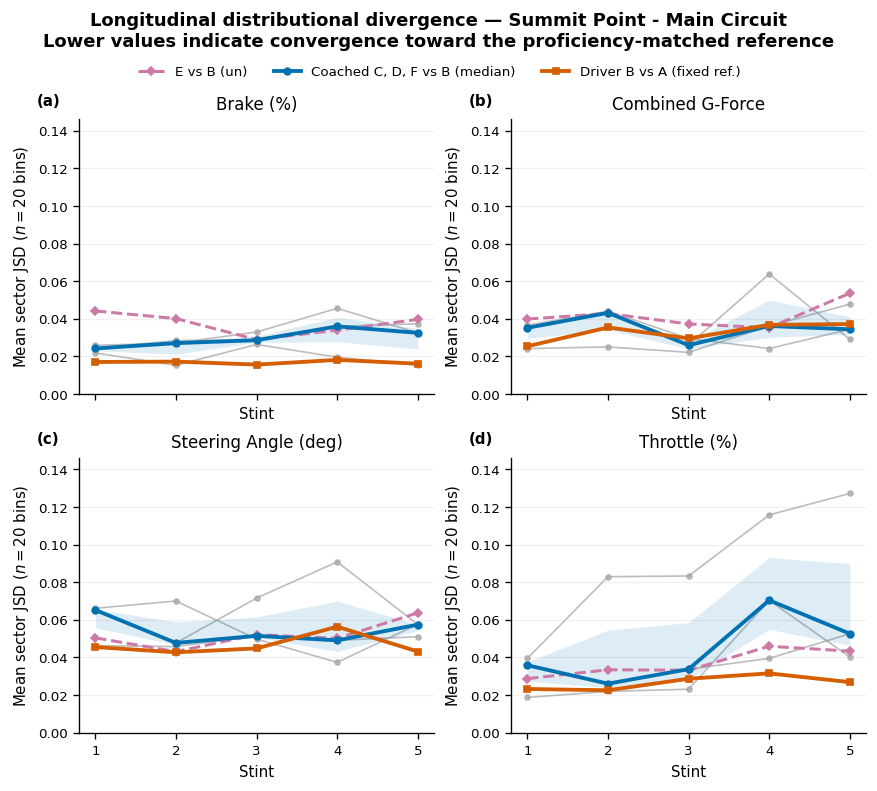

In [97]:
# Figure 8 - Section 6.3 candidate:
# Longitudinal JSD trajectories: Driver B vs the fixed expert reference,
# coached-group median (C, D, F) vs Driver B, and Driver E (control) vs B.

def plot_longitudinal_jsd(track_id: str):
    track_name = TRACK_META[track_id]["track_name"]
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(7.2, 5.8),
        sharex=True,
        constrained_layout=True,
    )
    axes = axes.ravel()

    track_values = JSD_PAIR[JSD_PAIR["Track"] == track_id]["JSD_mean"]
    ymax = max(0.1, float(track_values.max()) * 1.15) if len(track_values) else 0.5

    for ax, variable in zip(axes, VAR_LABELS):
        # Individual coached beginners: thin context lines.
        coached_pairs = JSD_PAIR[
            (JSD_PAIR["Track"] == track_id)
            & (JSD_PAIR["Variable"] == variable)
            & (JSD_PAIR["Comparison"].isin(COACHED_COMPARISONS))
        ]
        for comparison, comp_df in coached_pairs.groupby(
            "Comparison", observed=True
        ):
            comp_df = comp_df.sort_values("Stint")
            ax.plot(
                comp_df["Stint"],
                comp_df["JSD_mean"],
                color=COLORS["Individuals"],
                linewidth=1.0,
                marker="o",
                markersize=3,
                alpha=0.75,
                zorder=1,
            )

        # Driver E (control) vs Driver B.
        control_df = JSD_PAIR[
            (JSD_PAIR["Track"] == track_id)
            & (JSD_PAIR["Variable"] == variable)
            & (JSD_PAIR["Comparison"] == "E_vs_B")
        ].sort_values("Stint")
        if not control_df.empty:
            ax.plot(
                control_df["Stint"],
                control_df["JSD_mean"],
                color=COLORS["Control"],
                linestyle=CONTROL_LINESTYLE,
                linewidth=1.8,
                marker="D",
                markersize=3.5,
                label="E vs B (un)",
                zorder=3,
            )

        # Coached-group median + inter-driver IQR.
        group_df = JSD_COACHED[
            (JSD_COACHED["Track"] == track_id)
            & (JSD_COACHED["Variable"] == variable)
        ].sort_values("Stint")
        if not group_df.empty:
            x = group_df["Stint"].to_numpy()
            ax.fill_between(
                x,
                group_df["JSD_group_q25"].to_numpy(),
                group_df["JSD_group_q75"].to_numpy(),
                color=COLORS["Coached group"],
                alpha=0.13,
                linewidth=0,
                zorder=2,
            )
            ax.plot(
                x,
                group_df["JSD_group_median"].to_numpy(),
                color=COLORS["Coached group"],
                linewidth=2.3,
                marker="o",
                markersize=4,
                label="Coached C, D, F vs B (median)",
                zorder=4,
            )

        # Driver B vs the fixed expert reference.
        ba_df = JSD_PAIR[
            (JSD_PAIR["Track"] == track_id)
            & (JSD_PAIR["Variable"] == variable)
            & (JSD_PAIR["Comparison"] == "B_vs_A")
        ].sort_values("Stint")
        if not ba_df.empty:
            ax.plot(
                ba_df["Stint"],
                ba_df["JSD_mean"],
                color=COLORS["Driver B"],
                linewidth=2.3,
                marker="s",
                markersize=4,
                label="Driver B vs A (fixed ref.)",
                zorder=5,
            )

        ax.set_title(variable)
        ax.set_xlim(0.8, 5.2)
        ax.set_ylim(0.0, ymax)
        ax.set_xticks(STINT_NUMBERS)
        ax.set_xlabel("Stint")
        ax.set_ylabel(rf"Mean sector JSD ($n={N_BINS_FIXED}$ bins)")
        ax.grid(axis="y", alpha=0.18, linewidth=0.7)

    add_panel_letters(axes)
    handles, labels = axes[0].get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    fig.legend(
        unique.values(),
        unique.keys(),
        loc="upper center",
        bbox_to_anchor=(0.5, 1.05),
        ncol=3,
        frameon=False,
    )
    fig.suptitle(
        f"Longitudinal distributional divergence \u2014 {track_name}\n"
        "Lower values indicate convergence toward the proficiency-matched reference",
        y=1.11,
        fontweight="bold",
    )
    save_publication_figure(fig, f"Fig_6_3_longitudinal_JSD_{track_id}")
    plt.show()


for track_id in BATCH_TRACKS:
    plot_longitudinal_jsd(track_id)

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_4_wilcoxon_DeltaPE_charlotte_roval_2025.pdf


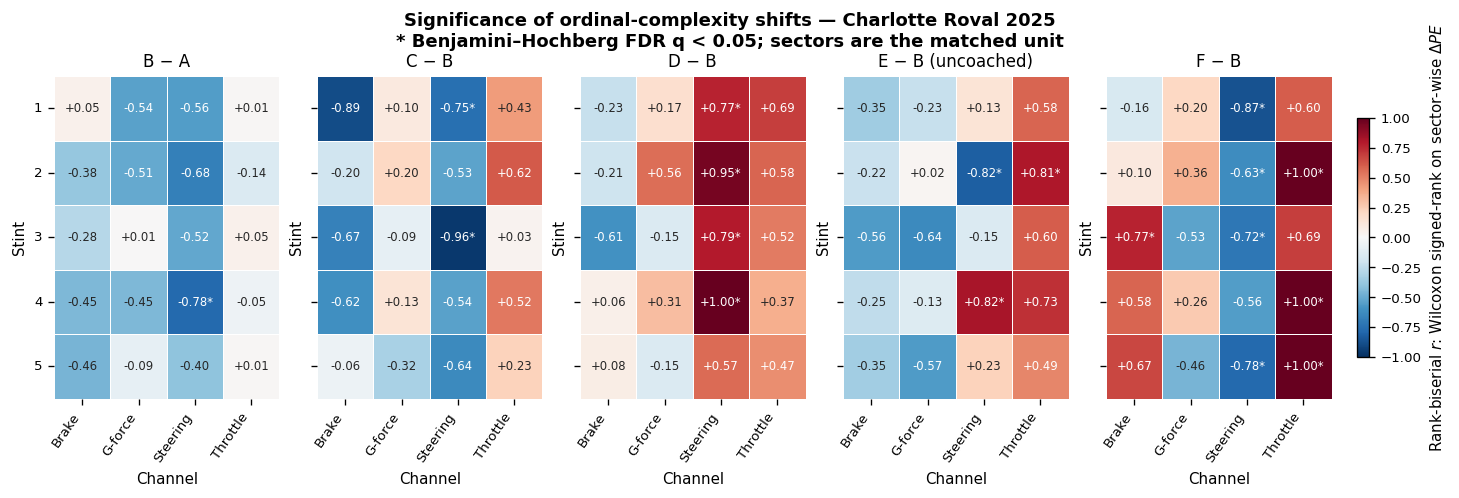

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\figures\Fig_6_4_wilcoxon_DeltaPE_summit_point.pdf


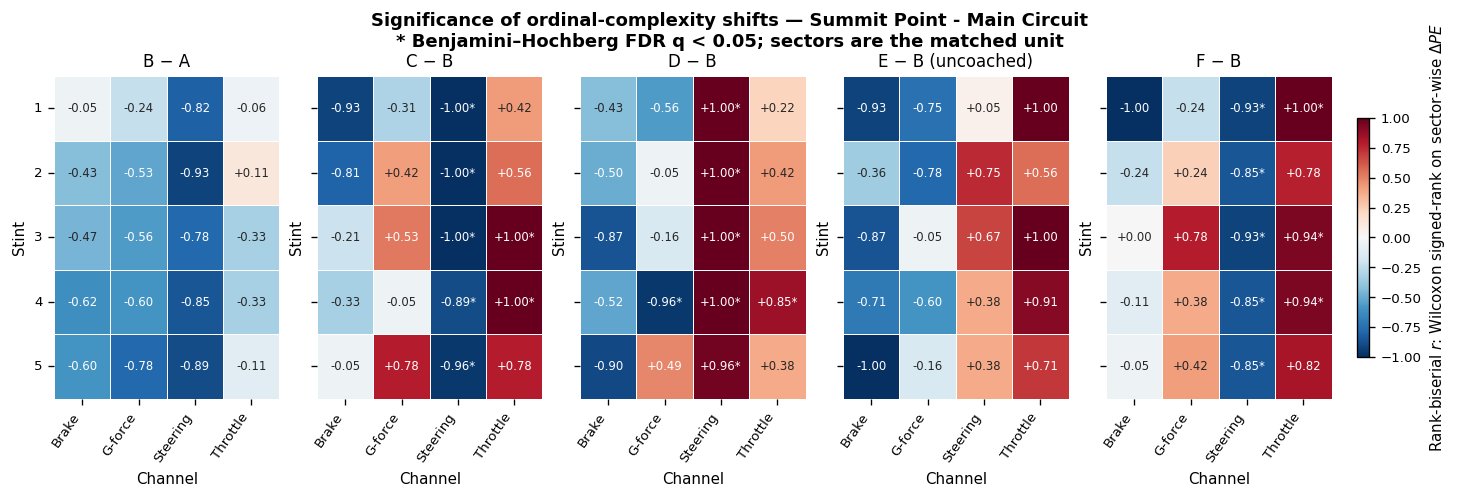

In [98]:
# Figure 9 - Section 6.4 candidate:
# Wilcoxon shift-test map. Cells encode the matched-pairs rank-biserial
# effect size of sector-wise DeltaPE against zero; * marks FDR q < 0.05.

def plot_wilcoxon_map(track_id: str):
    track_wx = WILCOXON_DPE[WILCOXON_DPE["Track"] == track_id].copy()
    if track_wx.empty or not np.isfinite(track_wx["r_rank_biserial"]).any():
        print(f"No Wilcoxon results for {track_id}; figure skipped.")
        return

    track_name = TRACK_META[track_id]["track_name"]
    available_comparisons = [
        comparison
        for comparison in COMPARISON_ORDER
        if comparison in track_wx["Comparison"].unique()
        and np.isfinite(
            track_wx.loc[
                track_wx["Comparison"] == comparison, "r_rank_biserial"
            ]
        ).any()
    ]
    if not available_comparisons:
        return

    fig, axes = plt.subplots(
        1,
        len(available_comparisons),
        figsize=(2.25 * len(available_comparisons) + 0.8, 3.7),
        sharey=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes)

    for ax, comparison in zip(axes, available_comparisons):
        comp_df = track_wx[track_wx["Comparison"] == comparison].copy()

        pivot = (
            comp_df.pivot_table(
                index="Stint",
                columns="Variable",
                values="r_rank_biserial",
                aggfunc="mean",
            )
            .reindex(index=STINT_NUMBERS, columns=VAR_LABELS)
        )

        annotations = pivot.copy().astype(object)
        for stint_no in STINT_NUMBERS:
            for variable in VAR_LABELS:
                value = pivot.loc[stint_no, variable]
                if pd.isna(value):
                    annotations.loc[stint_no, variable] = ""
                    continue
                row = comp_df[
                    (comp_df["Stint"] == stint_no)
                    & (comp_df["Variable"] == variable)
                ]
                significant = (
                    not row.empty and bool(row.iloc[0]["sig_FDR"])
                )
                annotations.loc[stint_no, variable] = (
                    f"{value:+.2f}{'*' if significant else ''}"
                )

        sns.heatmap(
            pivot,
            ax=ax,
            cmap="RdBu_r",
            vmin=-1,
            vmax=1,
            center=0,
            annot=annotations,
            fmt="",
            annot_kws={"fontsize": 7},
            linewidths=0.5,
            linecolor="white",
            cbar=False,
            mask=pivot.isna(),
        )
        ax.set_title(COMPARISON_DISPLAY[comparison])
        ax.set_xlabel("Channel")
        ax.set_ylabel("Stint")
        ax.set_yticklabels(STINT_NUMBERS, rotation=0)
        ax.set_xticklabels(
            ["Brake", "G-force", "Steering", "Throttle"],
            rotation=55,
            ha="right",
        )

    scalar_map = mpl.cm.ScalarMappable(
        norm=mpl.colors.Normalize(vmin=-1, vmax=1),
        cmap="RdBu_r",
    )
    scalar_map.set_array([])
    cbar = fig.colorbar(
        scalar_map,
        ax=axes.tolist(),
        shrink=0.74,
        pad=0.02,
    )
    cbar.set_label(
        r"Rank-biserial $r$: Wilcoxon signed-rank on sector-wise $\Delta PE$"
    )

    fig.suptitle(
        f"Significance of ordinal-complexity shifts \u2014 {track_name}\n"
        "* Benjamini\u2013Hochberg FDR q < 0.05; sectors are the matched unit",
        y=1.08,
        fontweight="bold",
    )
    save_publication_figure(fig, f"Fig_6_4_wilcoxon_DeltaPE_{track_id}")
    plt.show()


for track_id in BATCH_TRACKS:
    plot_wilcoxon_map(track_id)

In [99]:
# 8. Automated longitudinal change table and article-ready descriptive digest
# First/last stints are resolved per comparison (e.g. Driver B recorded four
# stints at Charlotte), the coached median uses C, D, F only, and Driver E is
# reported explicitly as the control contrast.

def classify_joint_change(delta_distance: float, delta_gap: float) -> str:
    if not np.isfinite(delta_distance) or not np.isfinite(delta_gap):
        return "Incomplete"
    if delta_distance < 0 and delta_gap < 0:
        return "PE convergence + performance improvement"
    if delta_distance < 0 and delta_gap >= 0:
        return "PE convergence without performance improvement"
    if delta_distance >= 0 and delta_gap < 0:
        return "Performance improvement without PE convergence"
    return "PE divergence + performance regression"


def first_last(indexed_series):
    stints = sorted(indexed_series.index.dropna())
    if len(stints) < 2:
        return None
    return int(stints[0]), int(stints[-1])


change_rows = []

for track_id in BATCH_TRACKS:
    # Individual pair changes.
    for comparison in COMPARISON_ORDER:
        dist_series = PAIR_OVERALL[
            (PAIR_OVERALL["Track"] == track_id)
            & (PAIR_OVERALL["Comparison"] == comparison)
        ].set_index("Stint")["MeanAbsDeltaPE"]

        perf_series = PERFORMANCE[
            (PERFORMANCE["Track"] == track_id)
            & (PERFORMANCE["Comparison"] == comparison)
        ].set_index("Stint")["LapGap_s"]

        jsd_series = JSD_PAIR[
            (JSD_PAIR["Track"] == track_id)
            & (JSD_PAIR["Comparison"] == comparison)
        ].groupby("Stint")["JSD_mean"].mean()

        span = first_last(dist_series)
        if span is None or first_last(perf_series) is None:
            continue
        first_stint, last_stint = span
        if first_stint not in perf_series.index or last_stint not in perf_series.index:
            continue

        distance_first = float(dist_series.loc[first_stint])
        distance_last = float(dist_series.loc[last_stint])
        gap_first = float(perf_series.loc[first_stint])
        gap_last = float(perf_series.loc[last_stint])

        jsd_first = (
            float(jsd_series.loc[first_stint])
            if first_stint in jsd_series.index else np.nan
        )
        jsd_last = (
            float(jsd_series.loc[last_stint])
            if last_stint in jsd_series.index else np.nan
        )

        var_change = PAIR_SUMMARY[
            (PAIR_SUMMARY["Track"] == track_id)
            & (PAIR_SUMMARY["Comparison"] == comparison)
            & (PAIR_SUMMARY["Stint"].isin([first_stint, last_stint]))
        ].pivot_table(
            index="Variable",
            columns="Stint",
            values="MeanAbsDeltaPE",
            aggfunc="mean",
        )

        if (
            first_stint in var_change.columns
            and last_stint in var_change.columns
        ):
            var_change["Change"] = (
                var_change[last_stint] - var_change[first_stint]
            )
            top_converging_channel = var_change["Change"].idxmin()
            top_diverging_channel = var_change["Change"].idxmax()
        else:
            top_converging_channel = np.nan
            top_diverging_channel = np.nan

        delta_distance = distance_last - distance_first
        delta_gap = gap_last - gap_first

        change_rows.append(
            {
                "Track": track_id,
                "TrackName": TRACK_META[track_id]["track_name"],
                "Comparison": comparison,
                "Role": (
                    "Control" if comparison in CONTROL_COMPARISONS
                    else "Coached" if comparison in COACHED_COMPARISONS
                    else "Intermediate vs Expert"
                ),
                "FirstStint": first_stint,
                "LastStint": last_stint,
                "Distance_first": distance_first,
                "Distance_last": distance_last,
                "DeltaDistance": delta_distance,
                "JSD_first": jsd_first,
                "JSD_last": jsd_last,
                "DeltaJSD": (
                    jsd_last - jsd_first
                    if np.isfinite(jsd_first) and np.isfinite(jsd_last)
                    else np.nan
                ),
                "LapGap_first_s": gap_first,
                "LapGap_last_s": gap_last,
                "DeltaLapGap_s": delta_gap,
                "TopConvergingChannel": top_converging_channel,
                "TopDivergingChannel": top_diverging_channel,
                "JointPattern": classify_joint_change(delta_distance, delta_gap),
            }
        )

    # Coached-group median (C, D, F), from the three driver-level comparisons.
    coached_dist = PAIR_OVERALL[
        (PAIR_OVERALL["Track"] == track_id)
        & (PAIR_OVERALL["Comparison"].isin(COACHED_COMPARISONS))
    ].groupby("Stint")["MeanAbsDeltaPE"].median()
    coached_perf = PERFORMANCE[
        (PERFORMANCE["Track"] == track_id)
        & (PERFORMANCE["Comparison"].isin(COACHED_COMPARISONS))
    ].groupby("Stint")["LapGap_s"].median()
    coached_jsd = JSD_PAIR[
        (JSD_PAIR["Track"] == track_id)
        & (JSD_PAIR["Comparison"].isin(COACHED_COMPARISONS))
    ].groupby("Stint")["JSD_mean"].median()

    span = first_last(coached_dist)
    if span is not None:
        first_stint, last_stint = span
        if (
            first_stint in coached_perf.index
            and last_stint in coached_perf.index
        ):
            distance_first = float(coached_dist.loc[first_stint])
            distance_last = float(coached_dist.loc[last_stint])
            gap_first = float(coached_perf.loc[first_stint])
            gap_last = float(coached_perf.loc[last_stint])
            delta_distance = distance_last - distance_first
            delta_gap = gap_last - gap_first

            change_rows.append(
                {
                    "Track": track_id,
                    "TrackName": TRACK_META[track_id]["track_name"],
                    "Comparison": "CDF_median_vs_B",
                    "Role": "Coached group median",
                    "FirstStint": first_stint,
                    "LastStint": last_stint,
                    "Distance_first": distance_first,
                    "Distance_last": distance_last,
                    "DeltaDistance": delta_distance,
                    "JSD_first": (
                        float(coached_jsd.loc[first_stint])
                        if first_stint in coached_jsd.index else np.nan
                    ),
                    "JSD_last": (
                        float(coached_jsd.loc[last_stint])
                        if last_stint in coached_jsd.index else np.nan
                    ),
                    "DeltaJSD": (
                        float(coached_jsd.loc[last_stint])
                        - float(coached_jsd.loc[first_stint])
                        if first_stint in coached_jsd.index
                        and last_stint in coached_jsd.index
                        else np.nan
                    ),
                    "LapGap_first_s": gap_first,
                    "LapGap_last_s": gap_last,
                    "DeltaLapGap_s": delta_gap,
                    "TopConvergingChannel": np.nan,
                    "TopDivergingChannel": np.nan,
                    "JointPattern": classify_joint_change(
                        delta_distance, delta_gap
                    ),
                }
            )

LONGITUDINAL_CHANGE = pd.DataFrame(change_rows)
LONGITUDINAL_CHANGE.to_csv(
    TABLE_DIR / "longitudinal_change_first_to_last_stint.csv",
    index=False,
)
display(LONGITUDINAL_CHANGE)


def print_results_digest():
    print("\nARTICLE-READY DESCRIPTIVE DIGEST")
    print("=" * 72)

    digest_targets = [
        ("B_vs_A", "Driver B relative to Driver A (fixed expert reference)"),
        ("CDF_median_vs_B",
         "the coached-group median (C, D, F) relative to Driver B"),
        ("E_vs_B", "Driver E (uncoached) relative to Driver B"),
    ]

    for track_id in BATCH_TRACKS:
        track_name = TRACK_META[track_id]["track_name"]
        print(f"\n{track_name}")

        track_df = LONGITUDINAL_CHANGE[
            LONGITUDINAL_CHANGE["Track"] == track_id
        ]
        for comparison, comparison_text in digest_targets:
            row = track_df[track_df["Comparison"] == comparison]
            if row.empty:
                continue
            row = row.iloc[0]

            jsd_text = ""
            if np.isfinite(row["JSD_first"]) and np.isfinite(row["JSD_last"]):
                jsd_text = (
                    f" Mean JSD changed from {row['JSD_first']:.3f} to "
                    f"{row['JSD_last']:.3f} (change {row['DeltaJSD']:+.3f})."
                )

            print(
                f"- {comparison_text}: mean absolute DeltaPE changed from "
                f"{row['Distance_first']:.3f} in Stint {int(row['FirstStint'])} "
                f"to {row['Distance_last']:.3f} in Stint {int(row['LastStint'])} "
                f"(change {row['DeltaDistance']:+.3f}).{jsd_text} "
                f"The lap-time gap changed from {row['LapGap_first_s']:+.3f} s "
                f"to {row['LapGap_last_s']:+.3f} s "
                f"(change {row['DeltaLapGap_s']:+.3f} s). "
                f"Descriptive pattern: {row['JointPattern']}."
            )

        sig_shift = WILCOXON_DPE[
            (WILCOXON_DPE["Track"] == track_id) & WILCOXON_DPE["sig_FDR"]
        ]
        sig_conv = WILCOXON_LONGITUDINAL[
            (WILCOXON_LONGITUDINAL["Track"] == track_id)
            & WILCOXON_LONGITUDINAL["sig_FDR"]
        ]
        print(
            f"- Wilcoxon (FDR q < {FDR_ALPHA}): "
            f"{len(sig_shift)} significant sector-wise DeltaPE shifts; "
            f"{len(sig_conv)} significant first-vs-last convergence tests "
            f"({', '.join(sorted(sig_conv['Metric'].unique())) or 'none'})."
        )


print_results_digest()

,Track,TrackName,Comparison,Role,FirstStint,LastStint,Distance_first,Distance_last,DeltaDistance,JSD_first,JSD_last,DeltaJSD,LapGap_first_s,LapGap_last_s,DeltaLapGap_s,TopConvergingChannel,TopDivergingChannel,JointPattern
0,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Intermediate vs Expert,1,5,0.040829,0.038777,-0.002052,0.050736,0.038673,-0.012063,0.983333,1.283333,0.300000,Brake (%),Steering Angle (deg),PE convergence without performance improvement
1,charlotte_roval_2025,Charlotte Roval 2025,C_vs_B,Coached,1,5,0.064361,0.049057,-0.015304,0.078298,0.064543,-0.013755,1.450000,0.950000,-0.500000,Brake (%),Combined G-Force,PE convergence + performance improvement
2,charlotte_roval_2025,Charlotte Roval 2025,D_vs_B,Coached,1,5,0.058766,0.054992,-0.003774,0.102054,0.097831,-0.004223,11.416667,4.700000,-6.716667,Brake (%),Throttle (%),PE convergence + performance improvement
3,charlotte_roval_2025,Charlotte Roval 2025,E_vs_B,Control,1,5,0.060299,0.045141,-0.015158,0.094298,0.070699,-0.023599,7.366667,3.316667,-4.050000,Brake (%),Steering Angle (deg),PE convergence + performance improvement
4,charlotte_roval_2025,Charlotte Roval 2025,F_vs_B,Coached,1,5,0.068857,0.060701,-0.008156,0.090554,0.078255,-0.012299,4.816667,3.550000,-1.266667,Brake (%),Throttle (%),PE convergence + performance improvement
5,charlotte_roval_2025,Charlotte Roval 2025,CDF_median_vs_B,Coached group median,1,5,0.064361,0.054992,-0.009368,0.097118,0.078068,-0.019050,4.816667,3.550000,-1.266667,NaN,NaN,PE convergence + performance improvement
6,summit_point,Summit Point - Main Circuit,B_vs_A,Intermediate vs Expert,1,5,0.027918,0.032407,0.004489,0.027812,0.030855,0.003043,1.600000,0.733333,-0.866667,Brake (%),Throttle (%),Performance improvement without PE convergence
7,summit_point,Summit Point - Main Circuit,C_vs_B,Coached,1,5,0.065321,0.063514,-0.001807,0.035154,0.038376,0.003222,1.516667,1.400000,-0.116667,Brake (%),Throttle (%),PE convergence + performance improvement
8,summit_point,Summit Point - Main Circuit,D_vs_B,Coached,1,5,0.036185,0.052734,0.016549,0.036289,0.039824,0.003535,2.000000,1.000000,-1.000000,Combined G-Force,Throttle (%),Performance improvement without PE convergence
9,summit_point,Summit Point - Main Circuit,E_vs_B,Control,1,5,0.043005,0.053756,0.010751,0.040821,0.050118,0.009296,2.750000,3.150000,0.400000,Combined G-Force,Throttle (%),PE divergence + performance regression



ARTICLE-READY DESCRIPTIVE DIGEST

Charlotte Roval 2025
- Driver B relative to Driver A (fixed expert reference): mean absolute DeltaPE changed from 0.041 in Stint 1 to 0.039 in Stint 5 (change -0.002). Mean JSD changed from 0.051 to 0.039 (change -0.012). The lap-time gap changed from +0.983 s to +1.283 s (change +0.300 s). Descriptive pattern: PE convergence without performance improvement.
- the coached-group median (C, D, F) relative to Driver B: mean absolute DeltaPE changed from 0.064 in Stint 1 to 0.055 in Stint 5 (change -0.009). Mean JSD changed from 0.097 to 0.078 (change -0.019). The lap-time gap changed from +4.817 s to +3.550 s (change -1.267 s). Descriptive pattern: PE convergence + performance improvement.
- Driver E (uncoached) relative to Driver B: mean absolute DeltaPE changed from 0.060 in Stint 1 to 0.045 in Stint 5 (change -0.015). Mean JSD changed from 0.094 to 0.071 (change -0.024). The lap-time gap changed from +7.367 s to +3.317 s (change -4.050 s). Descriptive

## 9. Recommended manuscript use

### Section 6.2 — Longitudinal Ordinal Complexity

Recommended title: **“Longitudinal Evolution of Ordinal Control Complexity”**.

Use **Figure 1** as the main section figure. It answers four questions in one
aligned visual system:

1. whether Driver B maintains the same PE level as Driver A's expert reference;
2. whether the coached-group median (C, D, F) changes across practice;
3. whether **Driver E (control)** follows or departs from the coached
   trajectory — the treatment/control contrast at the heart of the design;
4. whether the group median hides large differences among the coached drivers.

The wording should use **ordinal complexity**, **temporal organization**, or
**control structure**. Avoid equating PE directly with “uncertainty,”
“randomness,” or “skill.” A monotonic or plateau-heavy control sequence can
have low PE without being fast, while structured trail-braking modulation can
increase PE without being disruptive.

After execution, use `LONGITUDINAL_CHANGE` and the printed descriptive digest
to insert the actual directions and magnitudes.

### Section 6.3 — Distributional Divergence (JSD)

Use **Figure 8** (longitudinal JSD) as the section anchor and **Figure 7**
(sector × stint JSD maps) for spatial detail. Report the fixed binning
($n = 20$, $H_{max} = \log_2 20 \approx 4.32$ bits) in Methods and cite:
symmetry and bounds — Lin (1991); $\sqrt{JSD}$ as a metric —
Endres & Schindelin (2003). State explicitly that Freedman–Diaconis was used
only as a post-hoc sensitivity check. Because the B vs A comparison uses
Driver A's fixed reference stint, the JSD trajectory reads directly as
distributional convergence toward the expert.


### Section 6.4 — Reference-Relative PE, Performance Coupling, and Significance

Recommended subsection structure:

**6.4.1 Reference-relative convergence across stints.**
Use **Figure 2**. The outcome is mean sector $|\Delta PE|$: lower values
indicate that the test driver's ordinal pattern distribution is closer to the
proficiency-matched reference. The coached median and the control trajectory
share the panel, so the treatment contrast is read directly.

**6.4.2 Spatial persistence and relocation of complexity.**
Use **Figure 3**. Rows are stints and columns are circuit sectors, so vertical
patterns reveal persistent hotspots and horizontal changes reveal relocation
across practice. In the coached-group map, open circles identify unanimous sign
direction among the three coached beginners.

**6.4.3 Heterogeneity among beginners.**
Use **Figure 4** or place it in supplementary material. It prevents a group
median from being described as a universal beginner response, and it displays
the control row (E − B) next to the coached rows.

**6.4.4 Coupling with performance.**
Use **Figure 5** to distinguish four longitudinal patterns: PE convergence
with improvement, PE convergence without improvement, improvement without PE
convergence, and joint divergence/regression.

**6.4.5 Statistical significance.**
Use **Figure 9** and the `WILCOXON_DPE` / `WILCOXON_LONGITUDINAL` tables.
Report the Wilcoxon signed-rank statistic, the FDR-adjusted $q$, and the
rank-biserial effect size. Frame the results as within-driver directional
evidence — sectors are repeated observations, not independent participants —
consistent with the intra-subject deep-dive scope of the study.

**6.4.6 Sector-level association.**
Use **Figure 6** as supplementary evidence. Replace the term *predictor* with
*association* unless an actual predictive model with out-of-sample validation
is fitted.


In [100]:

# 9.1 Export concise LaTeX tables and figure include snippets

latex_tables = {
    "table_pe_quality.tex": PE_QUALITY[
        [
            "TrackName",
            "Variable",
            "ValidFraction",
            "PlateauFractionMedian",
            "MedianPatterns",
        ]
    ],
    "table_longitudinal_change.tex": LONGITUDINAL_CHANGE[
        [
            "TrackName",
            "Comparison",
            "Role",
            "Distance_first",
            "Distance_last",
            "DeltaDistance",
            "JSD_first",
            "JSD_last",
            "LapGap_first_s",
            "LapGap_last_s",
            "JointPattern",
        ]
    ],
    "table_jsd_pair_summary.tex": JSD_PAIR[
        [
            "TrackName",
            "Comparison",
            "Stint",
            "Variable",
            "JSD_mean",
            "JSD_median",
            "N_sectors",
        ]
    ],
    "table_wilcoxon_delta_pe.tex": WILCOXON_DPE[
        [
            "TrackName",
            "Comparison",
            "Stint",
            "Variable",
            "MedianDeltaPE",
            "W",
            "p_value",
            "p_adj_FDR",
            "r_rank_biserial",
            "N_sectors",
        ]
    ],
    "table_wilcoxon_longitudinal.tex": WILCOXON_LONGITUDINAL[
        [
            "TrackName",
            "Metric",
            "Comparison",
            "Variable",
            "FirstStint",
            "LastStint",
            "MedianChange_last_minus_first",
            "p_value",
            "p_adj_FDR",
            "r_rank_biserial",
            "N_paired_sectors",
        ]
    ],
}

for filename, table in latex_tables.items():
    latex_text = table.to_latex(
        index=False,
        float_format=lambda value: f"{value:.3f}",
        escape=True,
    )
    (TABLE_DIR / filename).write_text(latex_text, encoding="utf-8")
    print(f"Saved: {TABLE_DIR / filename}")


def print_latex_figure_snippets():
    print("\nSuggested LaTeX include commands")
    print("=" * 72)
    for track_id in BATCH_TRACKS:
        stems = [
            f"Fig_6_2_longitudinal_PE_{track_id}",
            f"Fig_6_3_longitudinal_JSD_{track_id}",
            f"Fig_6_3_sector_stint_JSD_B_vs_A_{track_id}",
            f"Fig_6_3_sector_stint_JSD_coached_group_{track_id}",
            f"Fig_6_4_reference_distance_{track_id}",
            f"Fig_6_4_sector_stint_DeltaPE_B_vs_A_{track_id}",
            f"Fig_6_4_sector_stint_DeltaPE_coached_group_{track_id}",
            f"Fig_6_4_beginner_heterogeneity_{track_id}",
            f"Fig_6_4_PE_performance_trajectory_{track_id}",
            f"Fig_6_4_correlation_evolution_{track_id}",
            f"Fig_6_4_wilcoxon_DeltaPE_{track_id}",
        ]
        for stem in stems:
            print(
                rf"\includegraphics[width=\linewidth]"
                rf"{{figures/{stem}.pdf}}"
            )


print_latex_figure_snippets()


Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\tables\table_pe_quality.tex
Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\tables\table_longitudinal_change.tex
Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\tables\table_jsd_pair_summary.tex
Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\tables\table_wilcoxon_delta_pe.tex
Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6\tables\table_wilcoxon_longitudinal.tex

Suggested LaTeX include commands
\includegraphics[width=\linewidth]{figures/Fig_6_2_longitudinal_PE_charlotte_roval_2025.pdf}
\includegraphics[width=\linewidth]{figures/Fig_6_3_longitudinal_JSD_charlotte_roval_2025.pdf}
\includegraphics[width=\linewidth]{figures/Fig_6_3_sector_stint_JSD_B_vs_A_charlotte_roval_2025.pdf}
\includegraphics[width=\linewidth]{figur


## 10. Optional robustness check for the delay parameter

The manuscript currently fixes \(m=3\) and \(\tau=1\), which preserves compatibility with
the existing methodology. Because the telemetry is sampled at 60 Hz, \(\tau=1\) emphasizes
very short temporal changes. The optional cell below compares \(\tau=1,2,3\) without
changing the primary figures.

A robust result should preserve the sign and rank ordering of the main \(\Delta PE\) patterns
across delays. This is a sensitivity analysis, not a procedure for selecting the delay after
seeing the desired result.


In [101]:

# 10.1 Optional delay sensitivity. Disabled by default to keep the main run concise.

RUN_DELAY_SENSITIVITY = False
SENSITIVITY_DELAYS = [1, 2, 3]


def build_pe_long_for_delay(delay: int) -> pd.DataFrame:
    rows = []

    for track_id in BATCH_TRACKS:
        meta = TRACK_META[track_id]

        for driver in DRIVER_ORDER:
            for stint_no, record in LONG_DATA[track_id].get(driver, {}).items():
                df_s = record["df_s"]

                for lap in sorted(df_s["Lap"].dropna().unique()):
                    lap_df = df_s[df_s["Lap"] == lap]

                    for sector_raw in meta["sector_order"]:
                        sector_df = (
                            lap_df[lap_df["SectorRaw"] == sector_raw]
                            .sort_values("SessionTime")
                        )
                        if sector_df.empty:
                            continue

                        sector_index = meta["sector_to_index"][sector_raw]

                        for variable_col, variable_label in VARIABLES_PE:
                            if variable_col not in sector_df.columns:
                                continue

                            pe_rec = permutation_entropy_record(
                                sector_df[variable_col].values,
                                order=PE_ORDER,
                                delay=delay,
                                min_patterns=PE_MIN_PATTERNS,
                            )
                            if not pe_rec["PEValid"]:
                                continue

                            rows.append(
                                {
                                    "Track": track_id,
                                    "Driver": driver,
                                    "Stint": stint_no,
                                    "Lap": int(lap),
                                    "SectorIndex": sector_index,
                                    "Variable": variable_label,
                                    "Delay": delay,
                                    "PE_norm": pe_rec["PE_norm"],
                                }
                            )

    return pd.DataFrame(rows)


if RUN_DELAY_SENSITIVITY:
    sensitivity_frames = [
        build_pe_long_for_delay(delay)
        for delay in SENSITIVITY_DELAYS
    ]
    PE_DELAY_LONG = pd.concat(sensitivity_frames, ignore_index=True)

    key_cols = [
        "Track",
        "Driver",
        "Stint",
        "Lap",
        "SectorIndex",
        "Variable",
    ]
    baseline = PE_DELAY_LONG[
        PE_DELAY_LONG["Delay"] == 1
    ][key_cols + ["PE_norm"]].rename(
        columns={"PE_norm": "PE_tau1"}
    )

    sensitivity_rows = []
    for delay in [value for value in SENSITIVITY_DELAYS if value != 1]:
        comparison = PE_DELAY_LONG[
            PE_DELAY_LONG["Delay"] == delay
        ][key_cols + ["PE_norm"]].rename(
            columns={"PE_norm": "PE_other"}
        )
        merged = baseline.merge(comparison, on=key_cols, how="inner")

        for (track_id, variable), group_df in merged.groupby(
            ["Track", "Variable"],
            observed=True,
        ):
            rho, p_value = spearmanr(
                group_df["PE_tau1"],
                group_df["PE_other"],
            )
            sensitivity_rows.append(
                {
                    "Track": track_id,
                    "Variable": variable,
                    "ComparedDelay": delay,
                    "SpearmanRho_vs_tau1": rho,
                    "PValue": p_value,
                    "MeanAbsoluteDifference": float(
                        np.mean(
                            np.abs(
                                group_df["PE_other"]
                                - group_df["PE_tau1"]
                            )
                        )
                    ),
                    "NMatchedWindows": len(group_df),
                }
            )

    PE_DELAY_SENSITIVITY = pd.DataFrame(sensitivity_rows)
    PE_DELAY_SENSITIVITY.to_csv(
        TABLE_DIR / "pe_delay_sensitivity.csv",
        index=False,
    )
    display(PE_DELAY_SENSITIVITY)
else:
    print(
        "Delay sensitivity was not run. Set RUN_DELAY_SENSITIVITY = True "
        "to compare tau = 1, 2, and 3."
    )


Delay sensitivity was not run. Set RUN_DELAY_SENSITIVITY = True to compare tau = 1, 2, and 3.


## 11. Reporting limitations

1. Stints and sectors are repeated observations from the same drivers. They are
   not a large independent participant sample; Wilcoxon results are
   within-driver directional evidence, consistent with the study's
   intra-subject deep-dive framing.
2. The coached group contains **three** drivers (C, D, F) and the control group
   contains **one** (E). Group medians, agreement fractions, and the
   coached-vs-control contrast are descriptive; no between-group inferential
   claim should be made from $n_{\text{control}} = 1$.
3. Driver A contributed a single expert session per track, so the B vs A
   comparison is anchored to one fixed reference stint. Reference-side
   variability (day, tire state, session context) is therefore not sampled.
4. Driver B recorded four stints at Charlotte and five at Summit Point; the
   change table resolves first/last stints per comparison instead of assuming
   Stints 1 and 5 everywhere. Missing stints must remain visible in the data
   audit and should not be imputed.
5. Sector-level correlations should not be described as causal or predictive.
6. PE can be affected by plateaus and sampling delay. Report the PE quality
   table and, when space permits, the delay sensitivity analysis.
7. JSD uses a fixed global binning ($n = 20$); Freedman–Diaconis is a
   post-hoc sensitivity check only. JSD values depend on the shared 1st–99th
   percentile ranges computed per track.
8. The same $\Delta PE$ sign can represent functional or disruptive complexity
   depending on the channel and sector. The physics-informed heuristic layer
   remains necessary.


In [102]:

# 11.1 Output manifest

generated_files = sorted(
    [
        path.relative_to(OUTPUT_ROOT)
        for path in OUTPUT_ROOT.rglob("*")
        if path.is_file()
    ],
    key=lambda path: str(path),
)

print(f"\nOutput root: {OUTPUT_ROOT}")
print(f"Generated files: {len(generated_files)}")
for path in generated_files:
    print(f" - {path}")



Output root: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\jsd_pe_stints_1_5_v6
Generated files: 75
 - figures\Fig_6_2_longitudinal_PE_charlotte_roval_2025.pdf
 - figures\Fig_6_2_longitudinal_PE_summit_point.pdf
 - figures\Fig_6_3_JSD_coached_vs_control_charlotte_roval_2025.pdf
 - figures\Fig_6_3_JSD_coached_vs_control_summit_point.pdf
 - figures\Fig_6_3_effect_size_forest_charlotte_roval_2025.pdf
 - figures\Fig_6_3_effect_size_forest_summit_point.pdf
 - figures\Fig_6_3_icc_summary.pdf
 - figures\Fig_6_3_laptime_trend_charlotte_roval_2025.pdf
 - figures\Fig_6_3_laptime_trend_summit_point.pdf
 - figures\Fig_6_3_longitudinal_JSD_charlotte_roval_2025.pdf
 - figures\Fig_6_3_longitudinal_JSD_summit_point.pdf
 - figures\Fig_6_3_sector_stint_JSD_B_vs_A_charlotte_roval_2025.pdf
 - figures\Fig_6_3_sector_stint_JSD_B_vs_A_summit_point.pdf
 - figures\Fig_6_3_sector_stint_JSD_coached_group_charlotte_roval_2025.pdf
 - figures\Fig_6_3_sector_stint_JSD_coached_group_summit_point.p